# Automobile Data Analysis and Preprocessing  

---

This notebook is designed to analyze the **1985 Automobile Imports Database**, which consists of various attributes of different car models. We'll load the data, preprocess it, and perform **exploratory data analysis (EDA)** to prepare it for machine learning algorithms. The notebooks takes care of:

1️⃣ **Loading the Data**: We will load the dataset and add appropriate column headers for better readability.  
2️⃣ **Handling Missing Values**: Missing values will be imputed using the **median**, but we can experiment with other techniques such as the **mean** or predictive imputation.  
3️⃣ **Exploratory Data Analysis (EDA)**: Different plots that will give you a solid understanding of the dataset we are dealing with.

💡 Feel free to **experiment with different EDA techniques** and **add more visualizations** :)

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PowerTransformer,RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.neighbors import KNeighborsRegressor

import scipy.stats as stats

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_validate

from sklearn.decomposition import PCA

from skopt import BayesSearchCV

import warnings

import scipy.stats as stats
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor , plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_style('whitegrid')  
plt.rcParams['figure.figsize'] = (12, 8)

### Loading the Data

Based on the metadata in `imports-85.names`, we know this dataset has 26 attributes. Let's define the column names and load the data.

In [2]:
# Define column names from the metadata file
columns = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
           'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
           'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
           'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
           'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Load the data
data = pd.read_csv('../data/imports-85.data', header=None, names=columns)

# Display first few rows
data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [3]:
# Replace '?' with NaN
data = data.replace('?', np.nan)

# Check initial data types
print("Data types before conversion:")
print(data.dtypes)

Data types before conversion:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object


In [4]:
# Count missing values before any processing
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


### Preliminary Data Type Conversions

Before splitting, we need to convert string columns to numeric where appropriate.

In [5]:
# Numeric columns that need to be converted
numeric_cols = ['normalized-losses', 'wheel-base', 'length', 'width', 'height',
                'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Convert to numeric
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Check data types after conversion
print("Data types after conversion:")
print(data.dtypes)

Data types after conversion:
symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


### Train-Test Split

It's crucial to split the data into training and test sets before performing any further preprocessing or analysis to prevent data leakage.

In [6]:
# Define the target variable (assuming we're predicting price)
X = data.drop('price', axis=1)
y = data['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a full training dataset (including the target variable) for EDA
train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (164, 25)
Testing set shape: (41, 25)


_________________

## Data Preprocessing

Now we'll preprocess the data, making sure to fit preprocessing operations only on the training set.

### Handling Missing Values

In [7]:
# Calculate percentage of missing values in training set
missing_percentage = train_data.isnull().sum() / len(train_data) * 100

# Create a dataframe to display columns with missing values
missing_data = pd.DataFrame({'Column': train_data.columns,
                            'Missing Value Count': train_data.isnull().sum(),
                            'Missing Percentage': missing_percentage})

# Sort by percentage of missing values
missing_data = missing_data.sort_values('Missing Percentage', ascending=False)
missing_data = missing_data[missing_data['Missing Value Count'] > 0]
missing_data

,Column,Missing Value Count,Missing Percentage
normalized-losses,normalized-losses,66,33.502538
stroke,stroke,36,18.274112
bore,bore,36,18.274112
price,price,35,17.766497
peak-rpm,peak-rpm,35,17.766497
num-of-doors,num-of-doors,35,17.766497
horsepower,horsepower,35,17.766497
engine-type,engine-type,33,16.751269
highway-mpg,highway-mpg,33,16.751269
city-mpg,city-mpg,33,16.751269


In [8]:
# Create a copy of numeric_cols without 'price' for imputation
# since price is our target variable and has been removed from X_train and X_test
numeric_features_for_imputation = [col for col in numeric_cols if col != 'price']

# Impute missing values based on training data only
# For numeric columns, use median
numeric_imputer = SimpleImputer(strategy='median')

X_train_numeric = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features_for_imputation]),
    columns=numeric_features_for_imputation,
    index=X_train.index
)

# Apply the SAME imputer to test set (using parameters learned from training)
X_test_numeric = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features_for_imputation]), 
    columns=numeric_features_for_imputation, 
    index=X_test.index
)

# For categorical columns with missing values, use most frequent value
cat_cols_with_missing = ['num-of-doors']
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit on training data
X_train_cat_missing = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_cols_with_missing]), 
    columns=cat_cols_with_missing, 
    index=X_train.index
)

# Transform test data
X_test_cat_missing = pd.DataFrame(
    cat_imputer.transform(X_test[cat_cols_with_missing]), 
    columns=cat_cols_with_missing, 
    index=X_test.index
)

# Update the imputed columns in our datasets
X_train[numeric_features_for_imputation] = X_train_numeric
X_test[numeric_features_for_imputation] = X_test_numeric
X_train[cat_cols_with_missing] = X_train_cat_missing
X_test[cat_cols_with_missing] = X_test_cat_missing

# Update training data for EDA
train_data[numeric_features_for_imputation] = X_train_numeric
train_data[cat_cols_with_missing] = X_train_cat_missing

# Verify no missing values remain
print("Missing values after imputation in training set:", X_train.isnull().sum().sum())
print("Missing values after imputation in test set:", X_test.isnull().sum().sum())
print("Missing values in y_train", y_train.isnull().sum().sum())
print("Missing values in y_test", y_test.isnull().sum().sum())

#Dropping the nan rows in the y and the corresponding x
X_train = X_train[y_train.notna()]
y_train = y_train.dropna()

X_test = X_test[y_test.notna()]
y_test = y_test.dropna()

#Final verification

print("Missing values after imputation in training set:", X_train.isnull().sum().sum())
print("Missing values after imputation in test set:", X_test.isnull().sum().sum())
print("Missing values in y_train", y_train.isnull().sum().sum())
print("Missing values in y_test", y_test.isnull().sum().sum())

Missing values after imputation in training set: 0
Missing values after imputation in test set: 0
Missing values in y_train 2
Missing values in y_test 2
Missing values after imputation in training set: 0
Missing values after imputation in test set: 0
Missing values in y_train 0
Missing values in y_test 0


_________

## Exploratory Data Analysis (EDA)

Now we'll perform EDA on the **training data only** to understand the relationships between variables without leaking information from the test set.

### Distribution of Continuous Variables

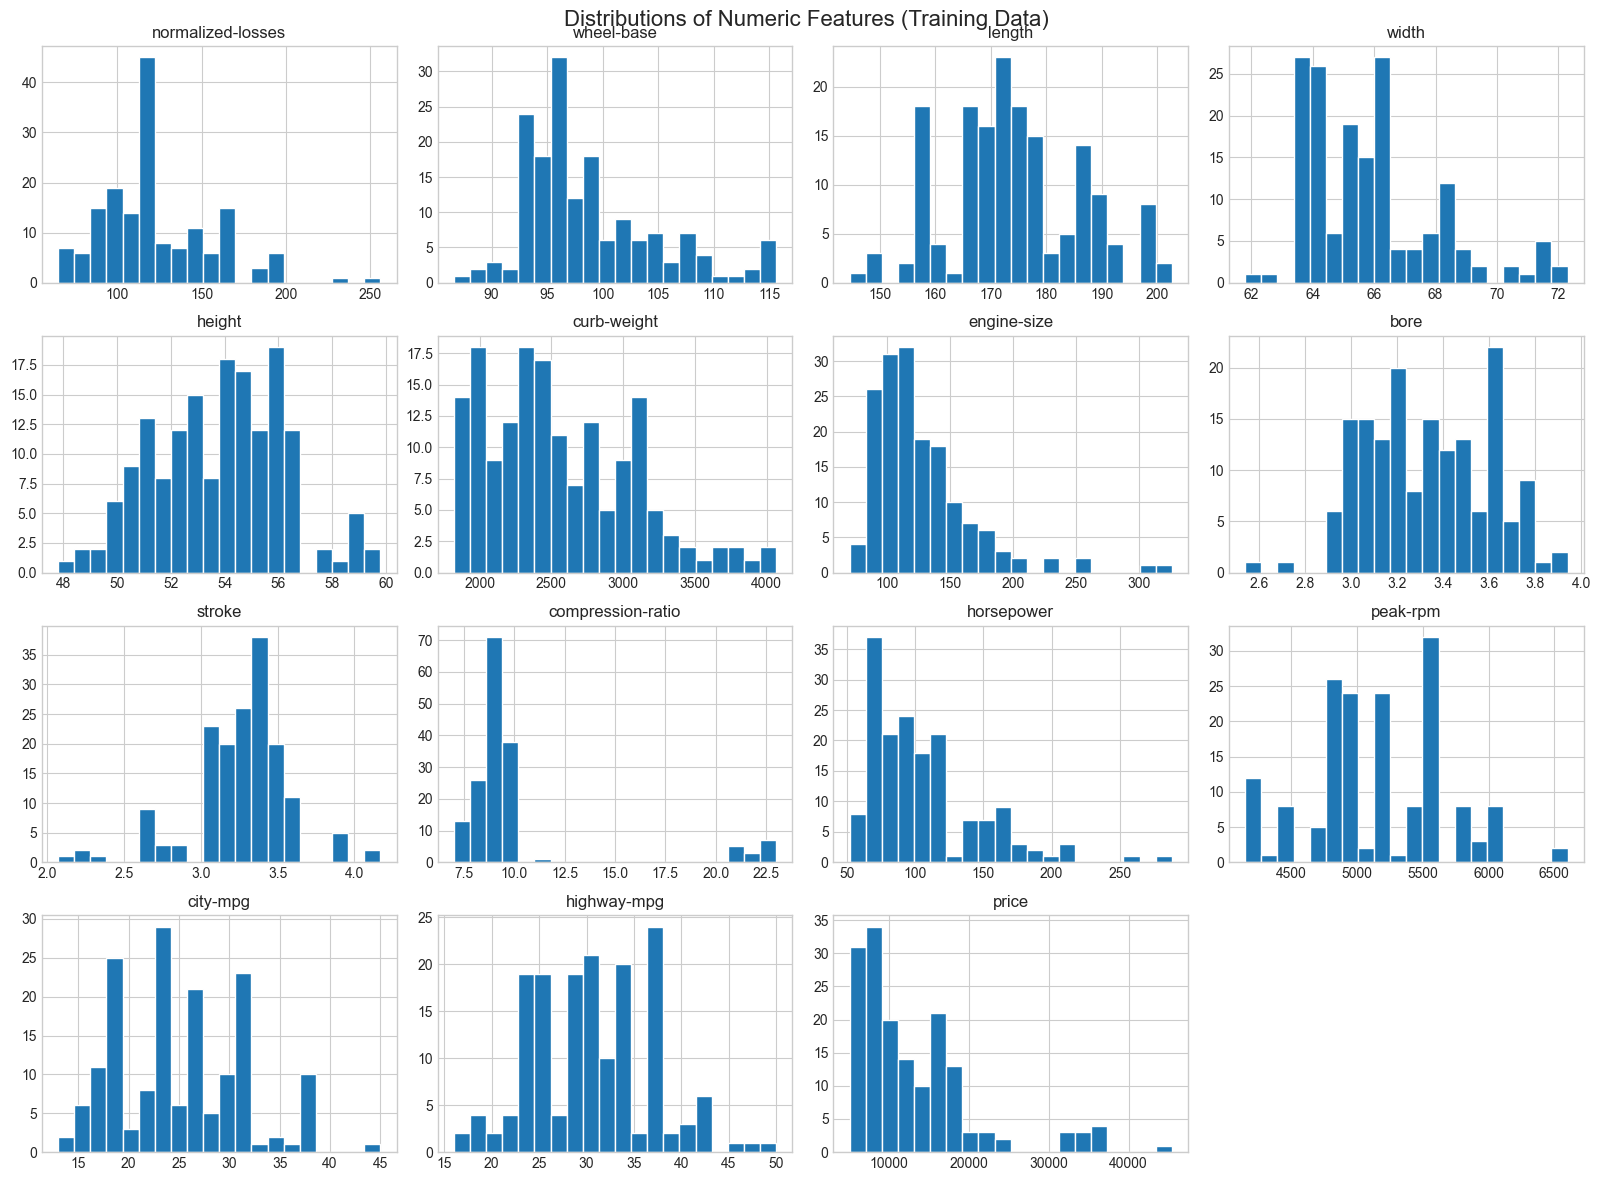

In [9]:
# Use numeric features for imputation plus 'price' for the histograms
numeric_cols_for_eda = numeric_features_for_imputation + ['price']

# Histogram of all numeric variables (training data only)
train_data[numeric_cols_for_eda].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.suptitle("Distributions of Numeric Features (Training Data)", fontsize=16)
plt.subplots_adjust(top=0.95)
plt.show()

### Car Makes Analysis

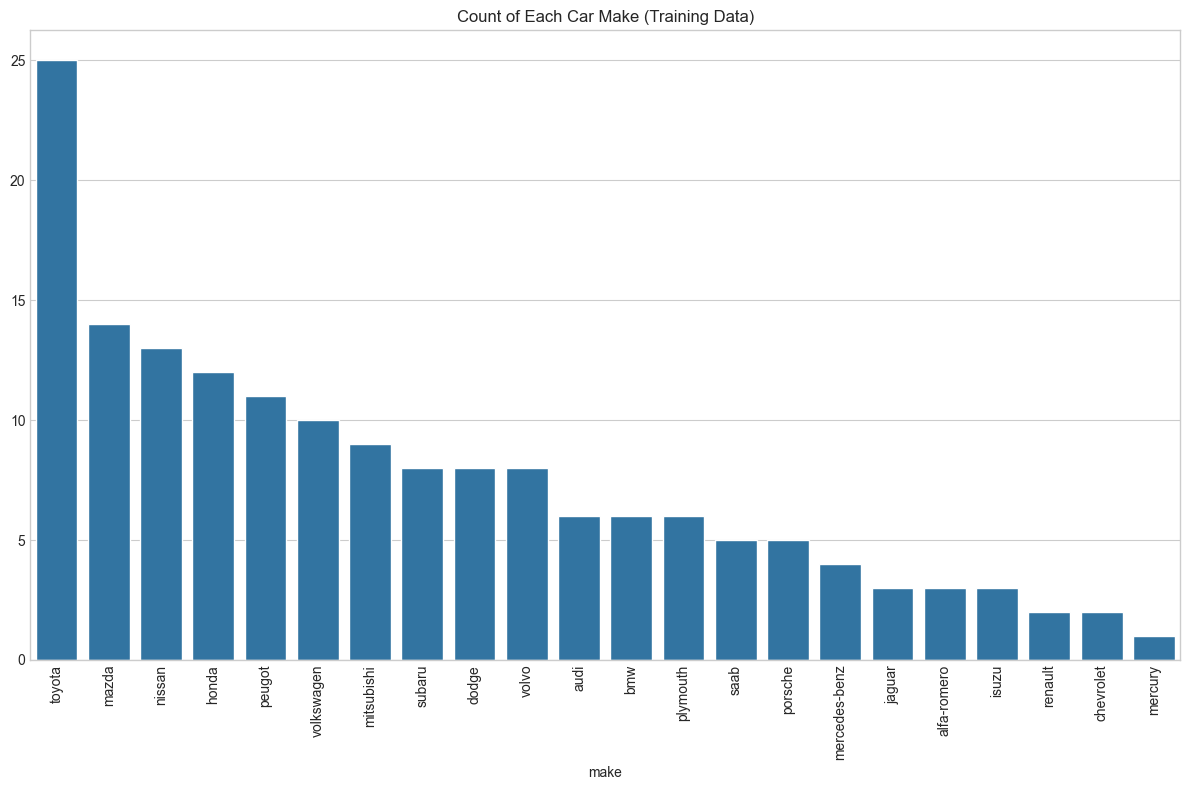

In [10]:
# Count of each car make (training data only)
plt.figure(figsize=(12, 8))
count_make = train_data['make'].value_counts()
sns.barplot(x=count_make.index, y=count_make.values)
plt.title('Count of Each Car Make (Training Data)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

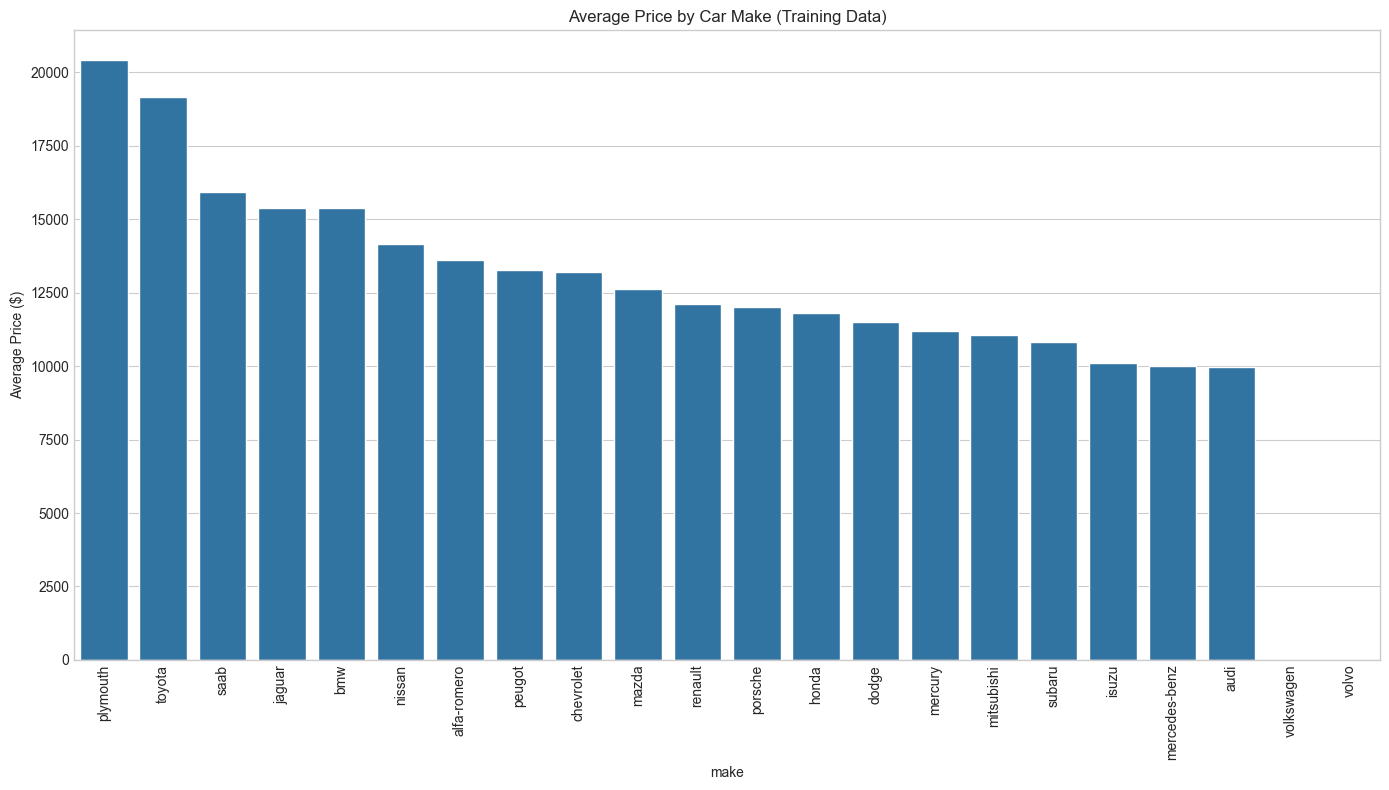

In [11]:
# Average price by make (training data only)
plt.figure(figsize=(14, 8))
avg_price = train_data.groupby('make')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title('Average Price by Car Make (Training Data)')
plt.xticks(rotation=90)
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

### Price Analysis

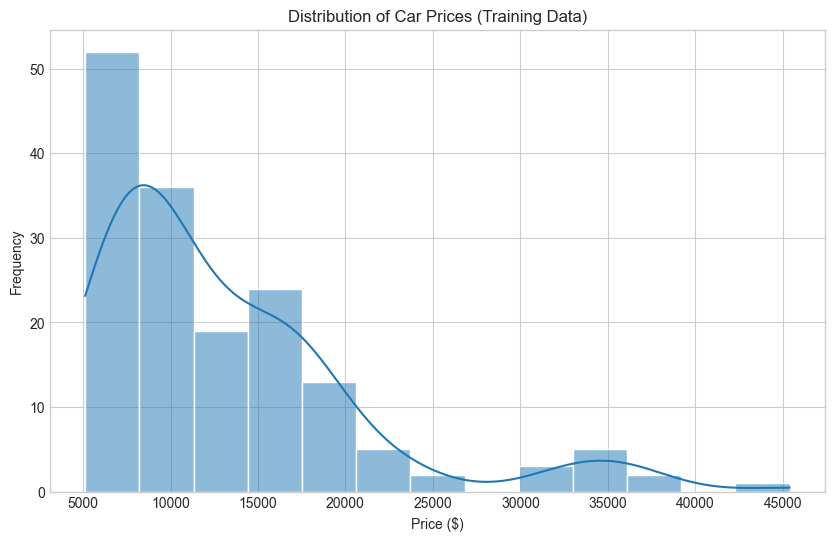

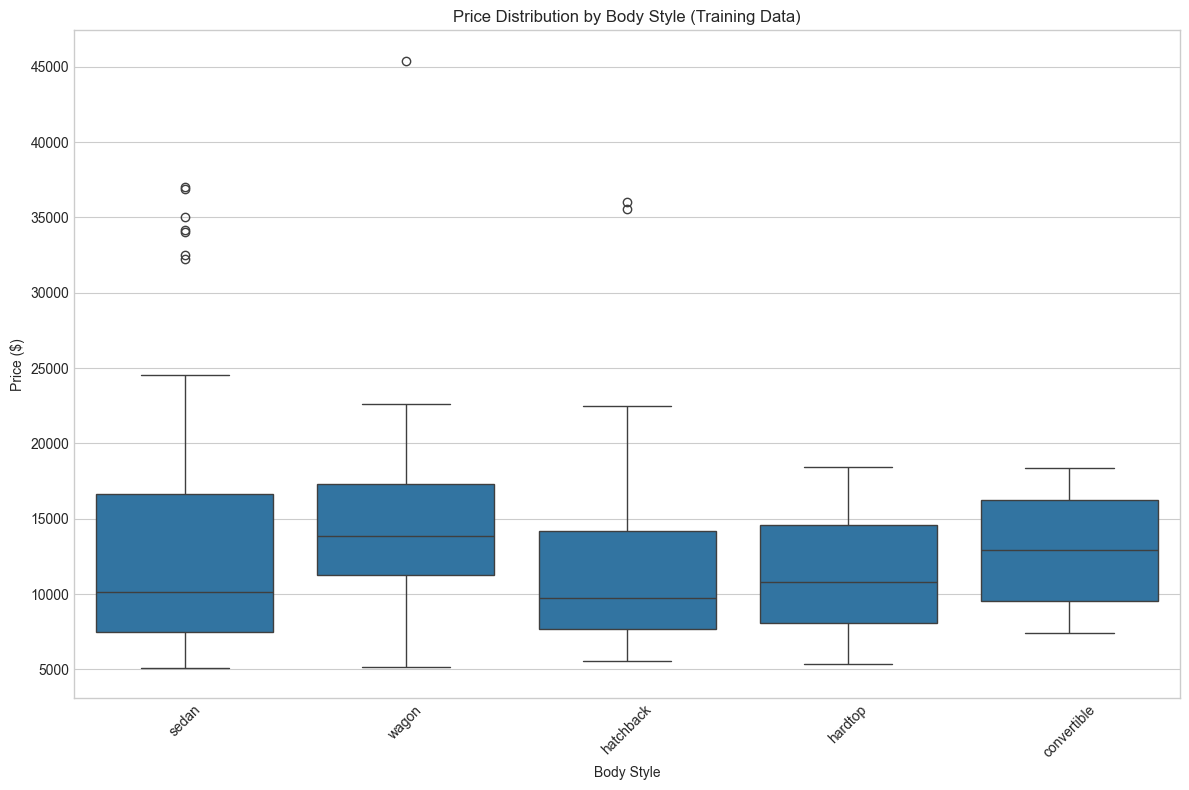

In [12]:
# Distribution of Price (training data only)
plt.figure(figsize=(10, 6))
sns.histplot(train_data['price'], kde=True)
plt.title('Distribution of Car Prices (Training Data)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Box plot of price by body style (training data only)
plt.figure(figsize=(12, 8))
sns.boxplot(x='body-style', y='price', data=train_data)
plt.title('Price Distribution by Body Style (Training Data)')
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Analysis

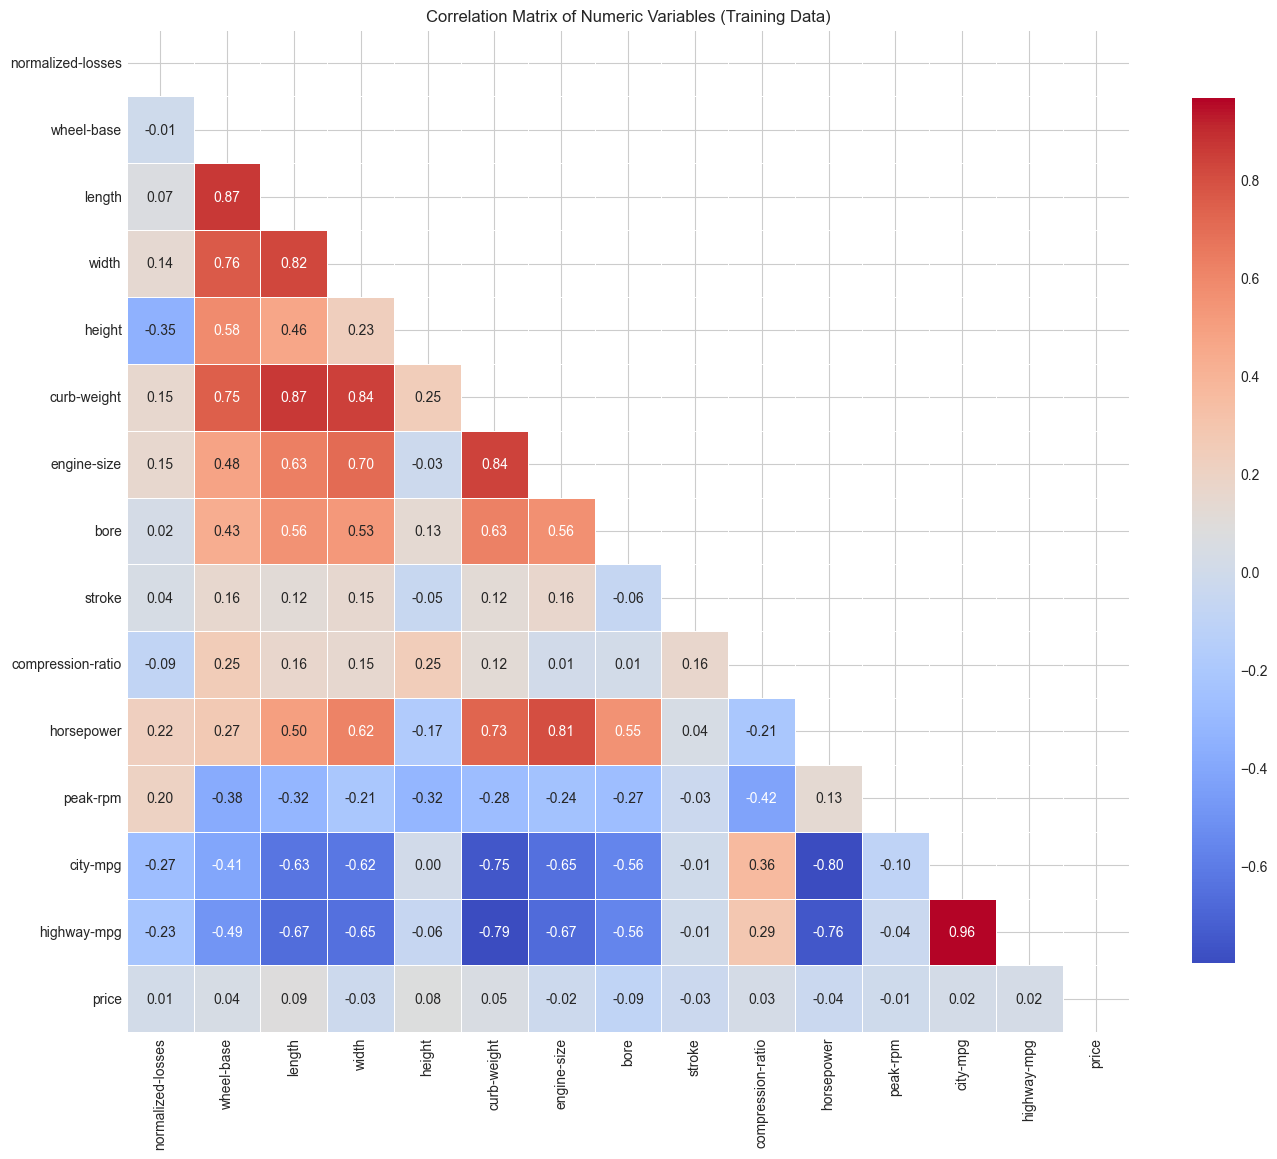

In [13]:
# Calculate correlation matrix for numeric variables (training data only)
corr_matrix = train_data[numeric_cols_for_eda].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Numeric Variables (Training Data)')
plt.tight_layout()
plt.show()

### Key Feature Relationships

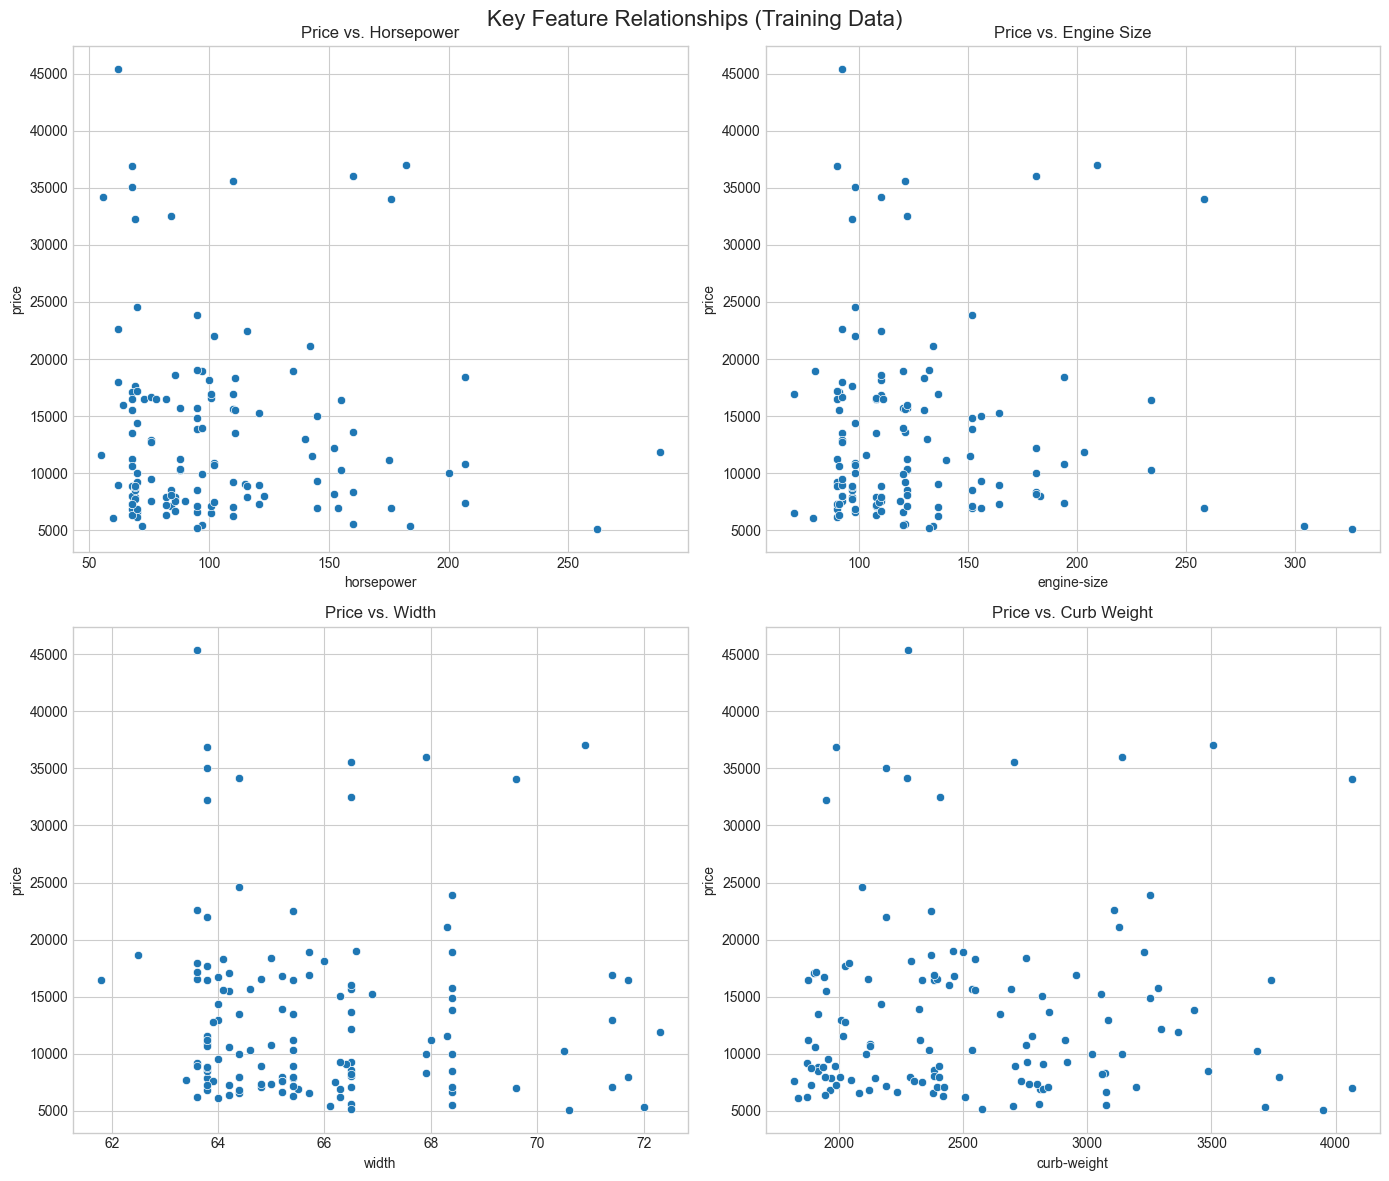

In [14]:
# Scatter plots for key feature relationships (training data only)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Price vs. horsepower
sns.scatterplot(x='horsepower', y='price', data=train_data, ax=axes[0, 0])
axes[0, 0].set_title('Price vs. Horsepower')

# Price vs. engine-size
sns.scatterplot(x='engine-size', y='price', data=train_data, ax=axes[0, 1])
axes[0, 1].set_title('Price vs. Engine Size')

# Price vs. width
sns.scatterplot(x='width', y='price', data=train_data, ax=axes[1, 0])
axes[1, 0].set_title('Price vs. Width')

# Price vs. curb-weight
sns.scatterplot(x='curb-weight', y='price', data=train_data, ax=axes[1, 1])
axes[1, 1].set_title('Price vs. Curb Weight')

plt.suptitle("Key Feature Relationships (Training Data)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### Specific Analysis of Width and Horsepower

Based on the 'misc' file, there seems to be a special interest in the relationship between width and horsepower.

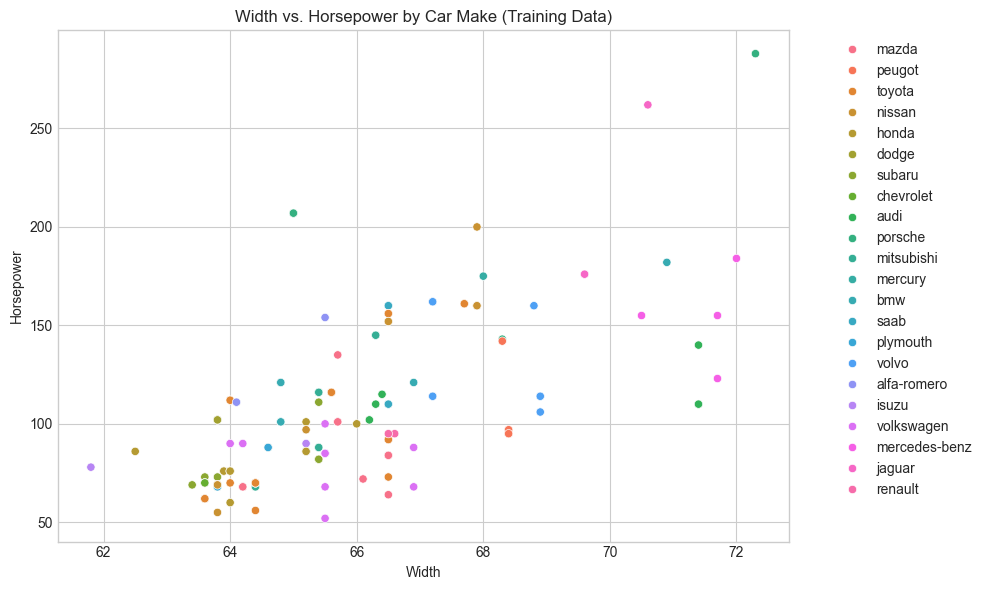

In [15]:
# Scatter plot with width and horsepower (training data only)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='width', y='horsepower', data=train_data, hue='make')
plt.title('Width vs. Horsepower by Car Make (Training Data)')
plt.xlabel('Width')
plt.ylabel('Horsepower')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

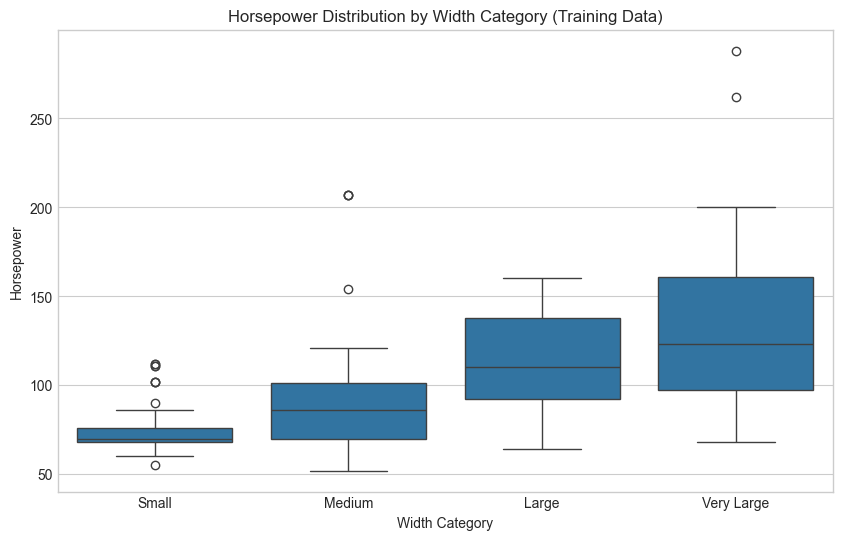

In [16]:
# Compare horsepower across different width ranges (training data only)
train_data['width_category'] = pd.qcut(train_data['width'], 4, labels=['Small', 'Medium', 'Large', 'Very Large'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='width_category', y='horsepower', data=train_data)
plt.title('Horsepower Distribution by Width Category (Training Data)')
plt.xlabel('Width Category')
plt.ylabel('Horsepower')
plt.show()

## Feature Engineering

We'll create new features based on our understanding of the data, keeping the training/test separation intact.

In [17]:
# Create feature engineering functions to apply to both training and test sets
def engineer_features(df):
    """Apply feature engineering to the dataset"""
    # Create a power-to-weight ratio feature
    df['power_to_weight'] = df['horsepower'] / df['curb-weight']
    
    # Create a feature for engine size per cylinder
    # First, convert num-of-cylinders to numeric
    cylinder_map = {
        'two': 2,
        'three': 3,
        'four': 4,
        'five': 5,
        'six': 6,
        'eight': 8,
        'twelve': 12
    }
    df['num_cylinders'] = df['num-of-cylinders'].map(cylinder_map)
    df['engine_size_per_cylinder'] = df['engine-size'] / df['num_cylinders']
    
    # Create fuel efficiency feature (combined MPG)
    df['combined_mpg'] = (df['city-mpg'] + df['highway-mpg']) / 2
    
    return df

# Apply feature engineering to both sets
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

# Update training data for continued analysis
train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

# Display new features
train_data[['power_to_weight', 'engine_size_per_cylinder', 'combined_mpg']].describe()

,power_to_weight,engine_size_per_cylinder,combined_mpg
count,162.000000,162.000000,162.000000
mean,0.040079,28.794856,27.777778
std,0.009358,4.934102,6.188800
min,0.019936,19.750000,15.000000
25%,0.034346,24.500000,22.125000
50%,0.037961,27.500000,27.000000
75%,0.043848,30.500000,32.000000
max,0.075109,43.000000,47.500000


## Preparing for Machine Learning

Now we'll prepare our data for machine learning by encoding categorical variables and scaling numeric features, maintaining our train/test separation.

In [18]:
# Identify feature types
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Remove width_category created during EDA if it exists
if 'width_category' in X_train.columns:
    X_train = X_train.drop('width_category', axis=1)
if 'width_category' in X_test.columns:
    X_test = X_test.drop('width_category', axis=1)

# Update feature lists if needed
if 'width_category' in numeric_features:
    numeric_features.remove('width_category')
if 'width_category' in categorical_features:
    categorical_features.remove('width_category')

In [19]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', pd.get_dummies)
])

# Apply one-hot encoding to categorical features
X_train_cat = pd.get_dummies(X_train[categorical_features], drop_first=True)
X_test_cat = pd.get_dummies(X_test[categorical_features], drop_first=True)

# Ensure test set has the same columns as train set
missing_cols = set(X_train_cat.columns) - set(X_test_cat.columns)
for col in missing_cols:
    X_test_cat[col] = 0
X_test_cat = X_test_cat[X_train_cat.columns]

# Scale numeric features
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[numeric_features]), 
                         columns=numeric_features, 
                         index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[numeric_features]), 
                        columns=numeric_features, 
                        index=X_test.index)


# Scale target variable
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))



# Convert scaled y values back to pandas Series/DataFrame for consistency
y_train_scaled = pd.DataFrame(y_train_scaled, index=y_train.index, columns=['price'])
y_test_scaled = pd.DataFrame(y_test_scaled, index=y_test.index, columns=['price'])

# Combine processed features
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num, X_test_cat], axis=1)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")

Processed training data shape: (162, 67)
Processed test data shape: (39, 67)


In [20]:
# View sample of processed data
X_train_processed.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_six,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
66,-0.721994,-0.145503,1.027648,0.063977,0.098189,0.264626,0.284858,0.195626,0.420606,1.201459,...,False,False,False,False,False,True,False,False,False,False
111,-0.721994,1.155615,1.529494,1.036401,1.213595,1.195688,1.024898,-0.154003,0.533730,-3.351254,...,False,False,False,False,False,False,False,True,False,False
153,-0.721994,-1.386103,-0.511346,-0.376523,-1.114208,2.167232,-0.543987,-0.853261,-1.012294,-0.713820,...,False,False,False,True,False,False,False,False,False,False
96,0.079123,-0.024468,-0.712084,-0.742222,-1.017216,0.305107,-1.153780,-0.728394,-0.635215,0.102528,...,False,False,False,True,False,False,False,False,False,False
38,-0.721994,-0.508605,-0.377520,-0.559373,-0.338274,-0.180665,-0.526226,-0.403738,-0.635215,1.013071,...,False,False,False,False,False,False,False,False,False,False


Non scalled data

In [21]:
X_train_processed_not_stand = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
X_test_processed_not_stand = pd.concat([X_test[numeric_features], X_test_cat], axis=1)

X_test_processed_not_stand.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_six,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
15,0,118.0,103.5,189.0,66.9,55.7,3230.0,209.0,3.62,3.39,...,True,0,False,False,False,False,0,True,False,0
100,0,106.0,97.2,173.4,65.2,54.7,2302.0,120.0,3.33,3.47,...,False,0,False,True,False,False,0,False,False,0
132,3,150.0,99.1,186.6,66.5,56.1,2658.0,121.0,3.54,3.07,...,False,0,False,False,False,False,0,True,False,0
68,-1,93.0,110.0,190.9,70.3,58.7,3750.0,183.0,3.58,3.64,...,False,0,False,False,False,True,0,False,False,0
95,1,128.0,94.5,165.6,63.8,53.3,2028.0,97.0,3.15,3.29,...,False,0,False,True,False,False,0,False,False,0


___________________

# Training the models

#### Preparing the data

In [22]:
#The no
X_train_original_scale = X_train_processed_not_stand.reset_index(drop=True)
y_train_original_scale = y_train.reset_index(drop=True)

X_test_original_scale = X_test_processed_not_stand.reset_index(drop=True)
y_test_original_scale = y_test.reset_index(drop=True)

print(y_test_original_scale)

X_train = X_train_processed.reset_index(drop=True)
y_train = y_train_scaled.reset_index(drop=True)

X_test = X_test_processed.reset_index(drop=True)
y_test = y_test_scaled.reset_index(drop=True)

0     30760.0
1      9549.0
2     11850.0
3     28248.0
4      7799.0
5      7788.0
6      9258.0
7     10198.0
8      7775.0
9     13295.0
10     8238.0
11    18280.0
12     9988.0
13    40960.0
14     6488.0
15     5151.0
16    12629.0
17     8189.0
18     9960.0
19     8495.0
20    13499.0
21     8249.0
22     6479.0
23     6692.0
24    41315.0
25     9639.0
26    13415.0
27     7999.0
28    12940.0
29    25552.0
30     6229.0
31     7898.0
32    21485.0
33     7689.0
34    28176.0
35    11259.0
36    10945.0
37    14489.0
38     7463.0
Name: price, dtype: float64


#### Utility functions

In [23]:
def regression_report(predicted, true):
    mean_squared_error_value = mean_squared_error(true, predicted)
    mean_absolute_error_value = mean_absolute_error(true, predicted)
    r2_score_value = r2_score(true, predicted)
    root_mean_squared_error_value = root_mean_squared_error(true, predicted)

    print("="*50)
    print("       Regression performance report" )
    print("="*50)
    print(
    "   Mean squared error: ",  np.round(mean_squared_error_value, 3), "\n"
    "   Mean absolute error:",  np.round(mean_absolute_error_value, 3), "\n"
    "   Root mean squared error:",             np.round(root_mean_squared_error_value, 3), "\n"
    "   R2 score:",             np.round(r2_score_value, 3)
    )
    print("="*50)


In [24]:
def plot_actual_predicted(true, predicted):
    true = np.ravel(true)
    predicted = np.ravel(predicted)

    plt.figure(figsize=(8,6))

    sns.scatterplot(x=true, y=predicted, alpha=0.7, edgecolors='k', label="Predictions")

    min_value, max_value = min(true.min(), predicted.min()), max(true.max(), predicted.max())
    plt.plot([min_value, max_value], [min_value, max_value], color="purple", linestyle='--', label="y = x")

    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("Actual vs Predicted values")
    plt.legend()
    plt.grid(True)


In [25]:
def histogram_residuals(true, predicted):
    residuals = true - predicted
    
    
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, bins=10, kde=True, color='blue') 
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Histogram of Residuals")
    plt.grid(True)
    plt.show()

In [26]:
def plot_qq(residuals):
    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title("QQ Plot of Residuals")
    plt.grid(True)
    plt.show()


In [27]:
from tabulate import tabulate

def plot_feature_importance(model, feature_names):
    importance = model.feature_importances_  
    feature_importance = pd.DataFrame({
        "Feature": feature_names, 
        "Importance (%)": importance * 100 
    })
    feature_importance = feature_importance.sort_values(by="Importance (%)", ascending=False)
    print(tabulate(feature_importance, headers="keys", tablefmt="fancy_grid", showindex=False))
    # get features with importance > 0%
    important_features = feature_importance[feature_importance["Importance (%)"] >0]
    plt.figure(figsize=(10, 12))  
    sns.barplot(x="Importance (%)", y="Feature", data=feature_importance, palette="viridis")
    
    #  percentage labels
    for index, value in enumerate(feature_importance["Importance (%)"]):
        plt.text(value + 0.5, index, f"{value:.2f}%", va="center")

    plt.title("Feature Importance (%)")
    plt.xlabel("Importance (%)")
    plt.ylabel("Feature Name")
    plt.show()

    return important_features["Feature"].tolist() 


In [28]:
def plot_residuals(y_true, y_predicted, model_name):
    
    if isinstance(y_true, pd.DataFrame):
        y_true = y_true.squeeze()  # convert to Series if it's a DataFrame

    # compute residuals
    residuals = y_true - y_predicted

    # plot residuals
    plt.figure(figsize=(10, 10))
    plt.scatter(y_predicted, residuals, color="purple", alpha=0.5)
    plt.axhline(y=0, color="red", linestyle="--")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals (Errors)")
    plt.title(f"{model_name} - Residual Plot")
    plt.grid()
    plt.show()


______

## Knn regressor

#### Basic training

In [29]:
knn_regressor = KNeighborsRegressor()
knn_regressor.fit(X_train, y_train)

KNeighborsRegressor()

#### Prediction and accuracy

In [30]:
knn_predict1 = knn_regressor.predict(X_test)

regression_report(knn_predict1, y_test)

       Regression performance report
   Mean squared error:  0.429 
   Mean absolute error: 0.384 
   Root mean squared error: 0.655 
   R2 score: 0.695


#### Visualization of the regression

* First let's get the prediction in the non scaled format, so that we get plots with meaning and easily interpretable

In [29]:
knn_predict1_not_scaled = scaler_y.inverse_transform(knn_predict1.reshape(-1, 1)).flatten()

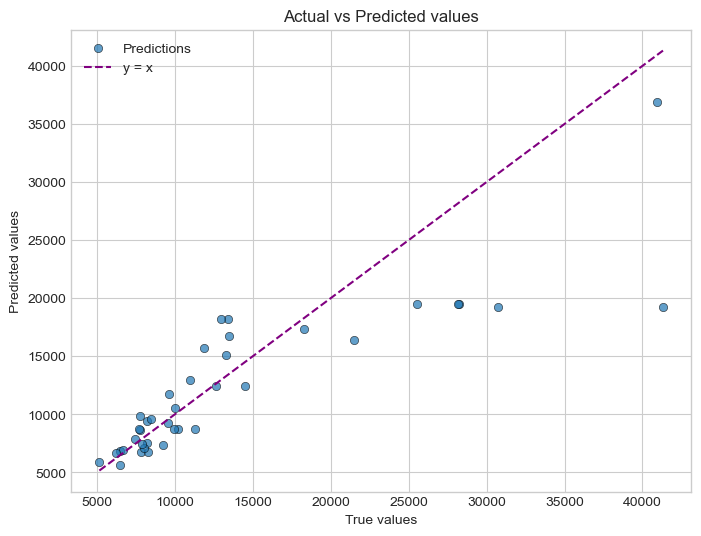

In [30]:
plot_actual_predicted(y_test_original_scale, knn_predict1_not_scaled)

We notice that the points somehow follow a straight line but there is some deviation.

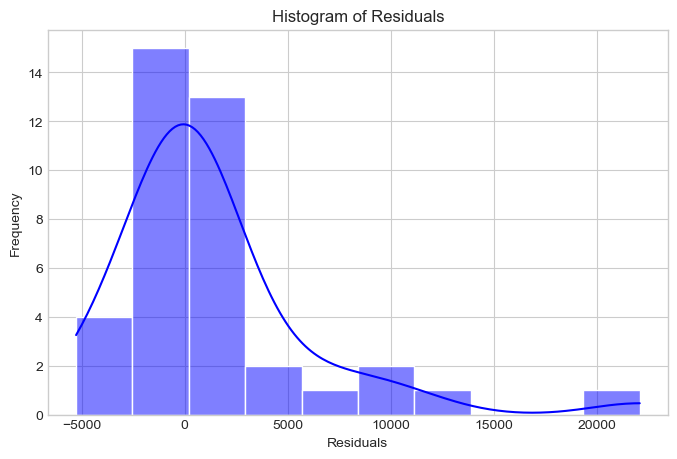

In [31]:
histogram_residuals(y_test_original_scale, knn_predict1_not_scaled)

 The residuals appear to be positively skewed

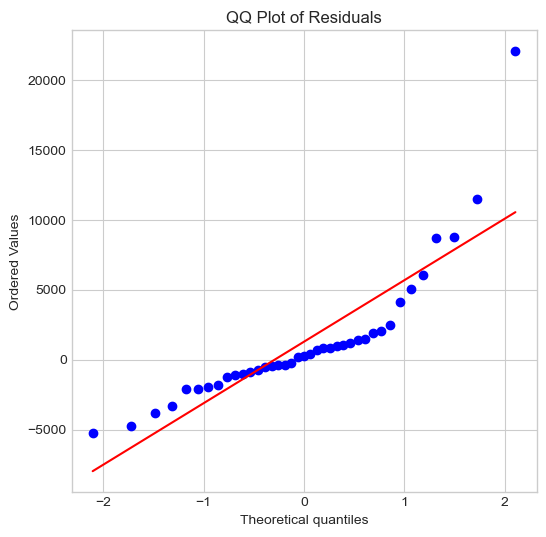

In [32]:
residuals = y_test_original_scale.to_numpy().flatten() - knn_predict1_not_scaled.flatten()

plot_qq(residuals)

The qq plot suggests that the points somehow follow the straight line, but there is a clear diviation which means the residuals are not normally distributed so the model didn't capture all the information.

#### Let's do some hyperparameter tuning using bayesian search to find the best setup

In [33]:
from skopt.space import Integer

search_space = {
    'n_neighbors': Integer(1, 50),  
    'weights': ['distance'],   #because of the presence of outliers let's choose weighted knn
    'metric': ['euclidean', 'manhattan'], 
}


In [ ]:
bayes_search = BayesSearchCV(
    knn_regressor,
    search_space,
    n_iter=20,  
    cv=5, 
    scoring='neg_mean_absolute_error',  
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

bayes_search.fit(X_train, y_train)

print("Best Parameters setup:", bayes_search.best_params_)

c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 42, 'distance']
  warnings.warn(
c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 7, 'distance']
  warnings.warn(
c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 7, 'distance']
  warnings.warn(


Best Parameters setup: OrderedDict({'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'})


From this we see that the best parameters are:  
Distance = manhattan    
k = 4   
weights = distance    

Let's build our knn regressor based on this

In [34]:
knn_regressor2 = KNeighborsRegressor(n_neighbors=4, metric="manhattan",weights="distance")
knn_regressor2.fit(X_train, y_train)

KNeighborsRegressor(metric='manhattan', n_neighbors=4, weights='distance')

#### Prediction and report

In [35]:
knn_predict2 = knn_regressor2.predict(X_test)

regression_report(knn_predict2, y_test)

       Regression performance report
   Mean squared error:  0.21 
   Mean absolute error: 0.26 
   Root mean squared error: 0.458 
   R2 score: 0.851


#### Visualization of the regression 

* Getting the non scaled prediction for better visualization & interpretability

In [36]:
knn_predict2_not_scaled = scaler_y.inverse_transform(knn_predict2.reshape(-1, 1)).flatten()

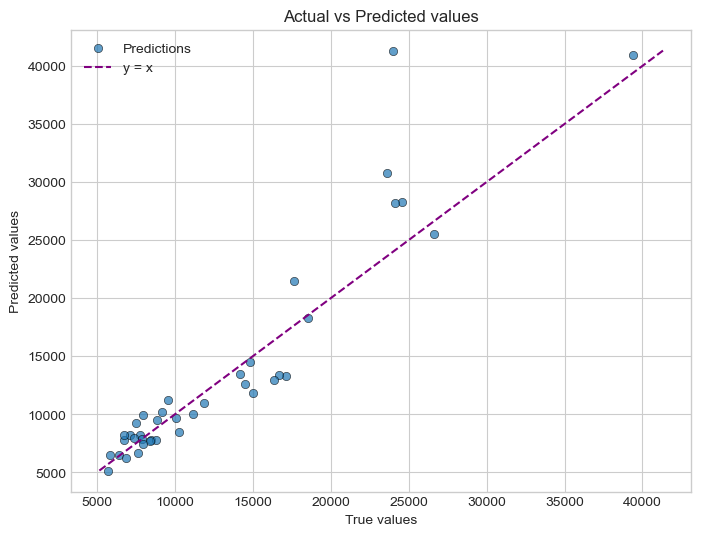

In [37]:
plot_actual_predicted(knn_predict2_not_scaled, y_test_original_scale)

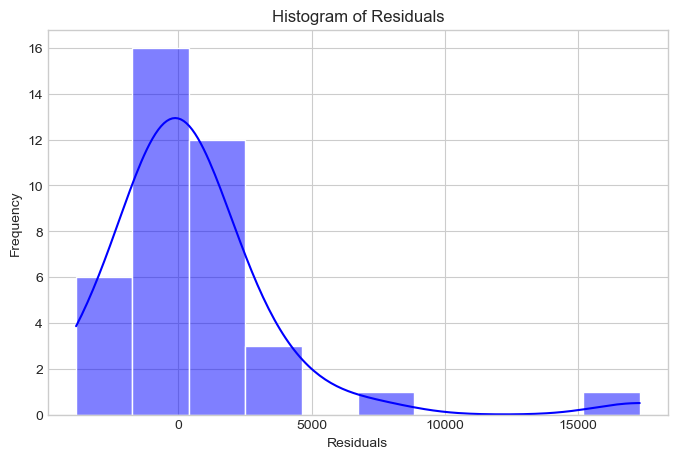

In [38]:
histogram_residuals(y_test_original_scale, knn_predict2_not_scaled)

 The residuals are still positively skewed

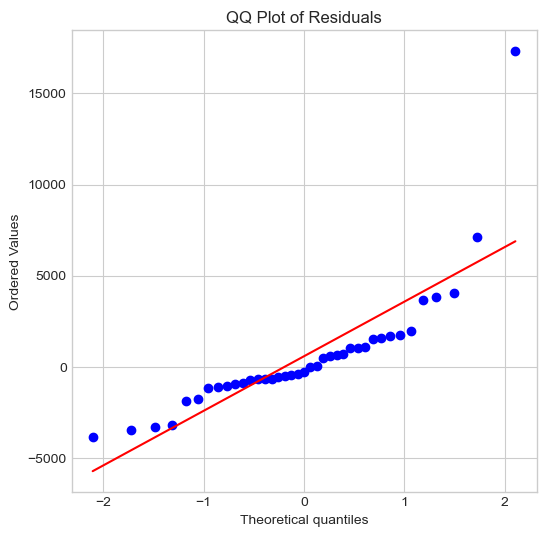

In [39]:
residuals = y_test_original_scale.to_numpy().flatten() - knn_predict2_not_scaled

plot_qq(residuals)

The residuals somehow follow the straight line, but the diviation is still there. Along with the extreme outlier at the top that is not captured by the regressor.

Cross validation

In [40]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer

cv = KFold(n_splits=10, shuffle=True, random_state=42)

# scoring metrics
scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'MSE':make_scorer(mean_squared_error),
    'RMSE':make_scorer(root_mean_squared_error),
    'R2': 'r2'
}

results = cross_validate(knn_regressor2, X_train, y_train, cv=cv, scoring=scoring)

#results
print(f"Test R²: {np.mean(results['test_R2']):.3f} (±{np.std(results['test_R2']):.3f})")
print(f"Test MAE: {np.mean(results['test_MAE']):.3f} (±{np.std(results['test_MAE']):.3f})")
print(f"Test MSE: {np.mean(results['test_MSE']):.3f} (±{np.std(results['test_MSE']):.3f})")
print(f"Test RMSE: {np.mean(results['test_RMSE']):.3f} (±{np.std(results['test_RMSE']):.3f})")



Test R²: 0.832 (±0.118)
Test MAE: 0.229 (±0.059)
Test MSE: 0.122 (±0.086)
Test RMSE: 0.330 (±0.114)


Comparaision between the actual and the predicted prices:

In [41]:
comparaison = pd.DataFrame({
    "Actual price:":y_test_original_scale,
    "Predicted Price: ":knn_predict2_not_scaled
})

print(comparaison)

    Actual price:  Predicted Price: 
0         30760.0       23628.051258
1          9549.0        8835.094110
2         11850.0       15039.820140
3         28248.0       24559.905369
4          7799.0        6705.517048
5          7788.0        8438.462436
6          9258.0        7494.652753
7         10198.0        9165.240064
8          7775.0        8791.401030
9         13295.0       17126.390256
10         8238.0        7764.266593
11        18280.0       18536.989825
12         9988.0       11138.873797
13        40960.0       39367.230674
14         6488.0        6425.119583
15         5151.0        5723.428164
16        12629.0       14475.647314
17         8189.0        7137.050575
18         9960.0        7972.425070
19         8495.0       10245.000000
20        13499.0       14173.995288
21         8249.0        6712.335043
22         6479.0        5856.167403
23         6692.0        7609.000000
24        41315.0       24002.154304
25         9639.0       10051.977141
2

## Conclusion

The KNN regression model has strong predictive performance with an  R² score of 0.851 and a stable one in the cross validation. 

Cross validation results for the other evaluation metrics confirm that the model is generalizing well since they fall within the expected range.    

The visualization of the result (the scatter plot, histogram of the residuals) indicate that the predictions are reliable but there is a presence of outliers.  

The trial of minimizing the impact of these outliers using knn seems to not be totally efficient which indicates that knn algorithm which is a distance based algorithm is not the most suitable one for this task and this data.

__________________________________________________________

## Linear Regression

#### Basic training

In [371]:
linear_regressor = LinearRegression()

linear_regressor.fit(X_train, y_train)

LinearRegression()

Coefficients of the model

In [372]:
print('Coefficients: \n', linear_regressor.coef_)

Coefficients: 
 [[-4.51083471e-02  1.67516121e-02  1.48928417e-01 -1.66711921e-01
   9.08595416e-02 -8.00750255e-02  1.92028300e-01  1.85836893e+00
  -1.33041932e-01  5.84439565e-02  9.00246280e-02  6.25242899e-01
   7.06726638e-02 -2.67065211e+12 -2.80729718e+12 -4.99741731e-01
   6.01713695e+11 -8.47010598e-01  5.43181903e+12  3.67686543e-02
   5.38649732e-01 -4.67102674e-01 -7.19614363e-01 -2.95155543e-01
  -7.97915269e-01 -1.16654685e+00 -3.11476900e-01  3.07273918e-02
  -3.85445916e-01 -7.34001858e-01 -3.69279793e-01  5.12725316e+12
  -7.32603601e-01  6.03203375e-01 -5.98615234e-01  2.02976714e-01
  -1.60132514e+12 -5.66390699e-01 -4.90276390e-01 -2.77008904e-01
   2.63305268e+12  3.23276601e-01 -5.43385233e-02 -4.98582434e-01
  -3.86337315e-01 -3.79945860e-01 -4.72263956e-01  8.04366460e-02
   2.76474029e-01 -1.60132514e+12 -5.12725316e+12  5.82968407e-02
   1.60132514e+12 -3.97065180e-01  2.36851986e+12  1.67666601e+12
   2.23555468e+12  1.11777734e+12 -2.23555468e+12  9.8481215

#### Prediction

In [374]:
prediction1 = linear_regressor.predict(X_test)


regression_report(prediction1, y_test)

       Regression performance report
   Mean squared error:  2.0022855493049682e+23 
   Mean absolute error: 71652393617.205 
   Root mean squared error: 447469054718.309 
   R2 score: -1.4220244132095717e+23


#### Cross validation

In [375]:
scores = cross_validate(linear_regressor, X_train, y_train, cv=5, scoring='r2')
print(f"Training Mean R²: {scores['test_score'].mean():.3f}")

print(f"Test Mean R²:  {r2_score(y_test, prediction1):.3f}")

Training Mean R²: -59471099934135025664000.000
Test Mean R²:  -142202441320957174874112.000


#### Visualization

* Getting the non standard predictions

In [376]:
prediction1_non_scaled = scaler_y.inverse_transform(prediction1.reshape(-1, 1)).flatten()

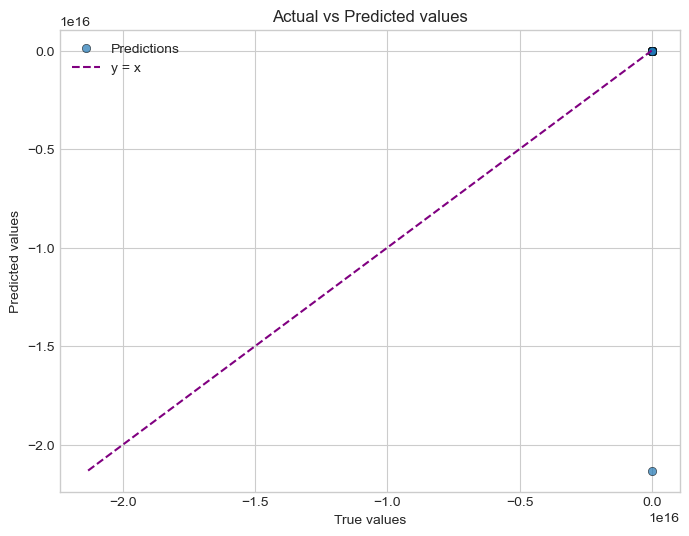

In [377]:
plot_actual_predicted(y_test_original_scale, prediction1_non_scaled)

This is not good, and the cause of this is the multi colinearity between the features (as indicated in the heatmap of the EDA)

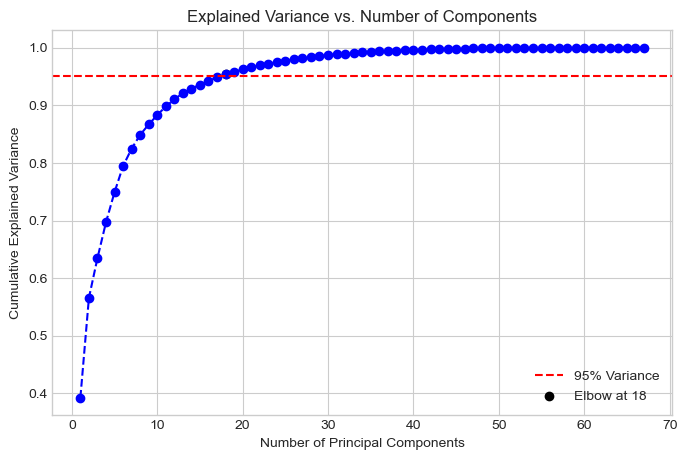

Optimal number of components: 18


In [378]:
pca = PCA()
X_pca = pca.fit_transform(X_train)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

#visualisation

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components")


plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance")


optimal_components = np.argmax(explained_variance >= 0.95) + 1
plt.scatter(optimal_components, explained_variance[optimal_components - 1], color='black', label=f"Elbow at {optimal_components}")
plt.legend()
plt.show()

print(f"Optimal number of components: {optimal_components}")


Applying the PCA

In [379]:
pca = PCA(n_components=18)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)

In [380]:
linear_regressor.fit(X_train_pca, y_train)
predicted2 = linear_regressor.predict(X_test_pca)

regression_report(predicted2, y_test)

       Regression performance report
   Mean squared error:  4.528 
   Mean absolute error: 1.644 
   Root mean squared error: 2.128 
   R2 score: -2.216


##### Cross validation

In [381]:
scores = cross_validate(linear_regressor, X_train_pca, y_train, cv=5, scoring='r2')
print(f"Training Mean R²: {scores['test_score'].mean():.3f}")

print(f"Test Mean R²:  {r2_score(y_test, predicted2):.3f}")

Training Mean R²: 0.809
Test Mean R²:  -2.216


There is an improvement, but there is a sign of underfitting.

* Getting the non scaled predictions

In [382]:
prediction2_non_scaled = scaler_y.inverse_transform(predicted2.reshape(-1, 1)).flatten()

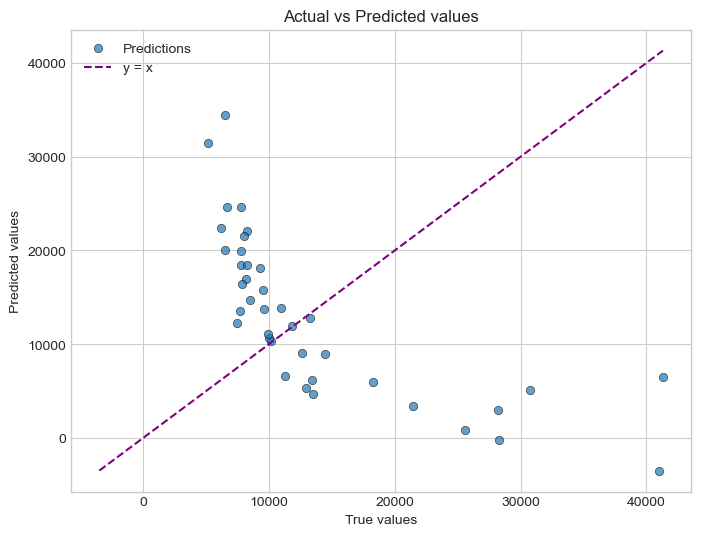

In [383]:
plot_actual_predicted(y_test_original_scale, prediction2_non_scaled)

#### Transforming the features

Training CV R²: 0.602
Test R²: 0.431
       Regression performance report
   Mean squared error:  46655806.884 
   Mean absolute error: 2986.522 
   Root mean squared error: 6830.506 
   R2 score: 0.431


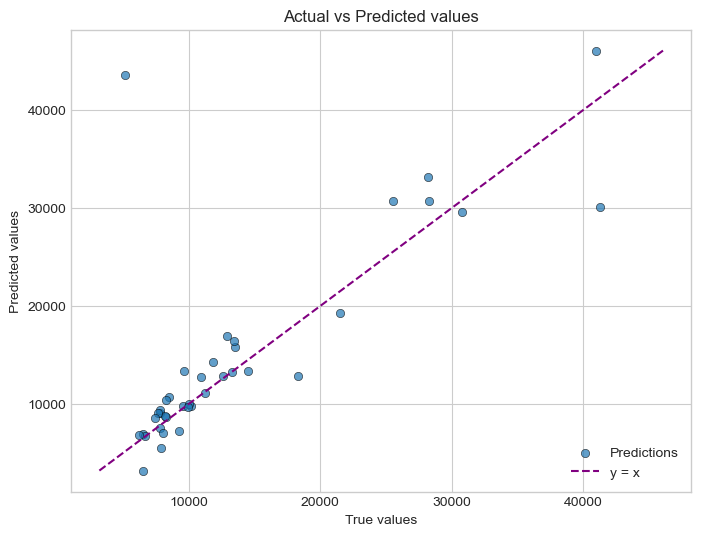

In [384]:
model = make_pipeline(
    PowerTransformer(),
    StandardScaler(),
    LinearRegression()
)

# cross-validate the training
train_scores = cross_validate(model, X_train_original_scale, y_train_original_scale, cv=5, scoring='r2')
print(f"Training CV R²: {train_scores['test_score'].mean():.3f}")


model.fit(X_train_original_scale, y_train_original_scale)  
test_r2 = model.score(X_test_original_scale, y_test_original_scale)
print(f"Test R²: {test_r2:.3f}")


predicted = model.predict(X_test_original_scale)
regression_report(predicted, y_test_original_scale)
predicted

plot_actual_predicted(y_test_original_scale, predicted)

### Using Regulization

Training CV R²: 0.881
Test R²: 0.820
       Regression performance report
   Mean squared error:  14778511.372 
   Mean absolute error: 2243.683 
   Root mean squared error: 3844.283 
   R2 score: 0.82


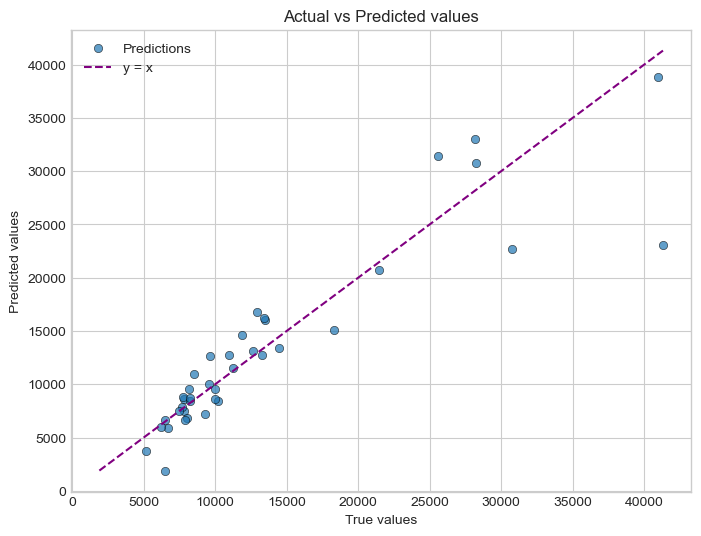

In [385]:
model = make_pipeline(
    PowerTransformer(),
    RobustScaler(),
    Ridge(alpha=1.0)  
)

# cross-validate the training
train_scores = cross_validate(model, X_train_original_scale, y_train_original_scale, cv=5, scoring='r2')
print(f"Training CV R²: {train_scores['test_score'].mean():.3f}")


model.fit(X_train_original_scale, y_train_original_scale)  
test_r2 = model.score(X_test_original_scale, y_test_original_scale)
print(f"Test R²: {test_r2:.3f}")


predicted = model.predict(X_test_original_scale)
regression_report(predicted, y_test_original_scale)


plot_actual_predicted(y_test_original_scale, predicted)

### Visualization

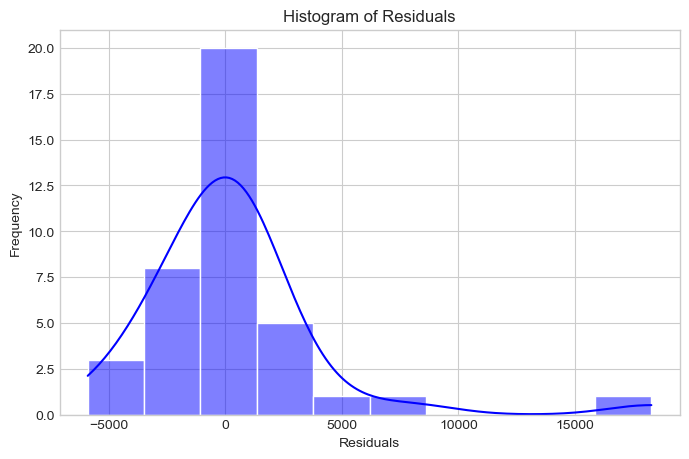

In [386]:
histogram_residuals(y_test_original_scale, predicted)

This histogram indicates that the residuals follow a normal distribution (but has a little right skew to it) which is a good sign since it shows that the model captures all systematic patterns leaving only the white noise.

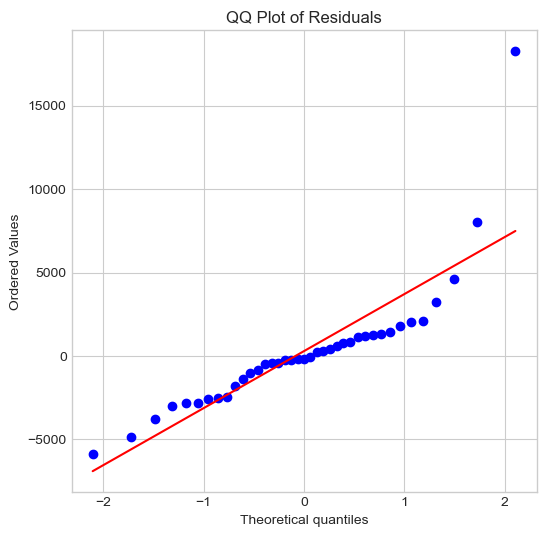

In [387]:
res = y_test_original_scale.to_numpy().flatten() - predicted.flatten()
plot_qq(res)

The qq plot shows that the residuals follow the straight line, which validates our assumption that the residuals are normally distributed.

### Comparaison between the predicted prices and the actual prices

In [388]:
y_test_arr = y_test_original_scale.to_numpy().flatten()
predicted_arr = predicted.flatten()

comparaison = pd.DataFrame({
    "Actual price: ":y_test_arr,
    "Predicted Price: ":predicted_arr
})

print(comparaison)

    Actual price:   Predicted Price: 
0          30760.0       22721.463770
1           9549.0        9989.998449
2          11850.0       14650.059877
3          28248.0       30747.163986
4           7799.0        7505.832095
5           7788.0        8658.265924
6           9258.0        7243.964698
7          10198.0        8397.306052
8           7775.0        8780.000037
9          13295.0       12721.669789
10          8238.0        8462.876127
11         18280.0       15062.483500
12          9988.0        9588.764400
13         40960.0       38879.969496
14          6488.0        6652.060792
15          5151.0        3721.377677
16         12629.0       13073.588509
17          8189.0        9574.220703
18          9960.0        8647.346004
19          8495.0       10975.528816
20         13499.0       16074.004715
21          8249.0        8740.459681
22          6479.0        1895.715144
23          6692.0        5880.565134
24         41315.0       23039.807960
25          

# Conclusion

* The linear regression model at first showed terrible prediction with negative R2 score, and this is because the features were collinear and had no linear relationship with the target.  

* After this, PCA was tried to lower the dimensionality thus delete the collinearity. However after the training and the cross validation the result showed overfitting with bad score. Which suggests that this approach is not suitable. 

* Finally, the approach that showed some improvement was transforming the features using the pipe line and the PowerTransformer transformation, that makes the data more linear.    
But in the end the approach that worked well with 82% R2 score is the Ridge regularization. Which means that for this type of data that shows non linearity the standard Linear Regression model doesn't work well, variation of this model along with the transformation of the features is the solution for better prediction.

_________________________

# Naive Bayes :
Naive Bayes is a probabilistic machine learning algorithm based on Bayes' Theorem. It is particularly useful for classification tasks and assumes that the features are independent of each other (hence "naive"). Despite this assumption, it often performs well in practice, especially for text classification and spam filtering.

# Initialize the Bayes Naive model

- . Why Gaussian Distribution?
Continuous Data: Gaussian Naive Bayes is specifically designed for continuous data. It assumes that the data for each feature is distributed according to a Gaussian (normal) distribution.
Simplicity: The Gaussian distribution is mathematically simple to work with, as it only requires calculating the mean and variance for each feature.
Common in Real-World Data: Many real-world datasets approximately follow a normal distribution, making the Gaussian assumption reasonable in practice.

- Functions :

In [67]:
def plot_residuals_vs_predicted(y_true, y_pred):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')  
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs. Predicted Plot")
    plt.grid(True)
    plt.show()

- Naive Bayes Regressor Model :

- The GaussiannNB from scikit-learn is designed for classification tasks.
- We define our model GaussianNaiveBayesRegressor where variance is used to model the Gaussian (normal) distribution of the features for each class.

In [68]:
class GaussianNaiveBayesRegressor:
    def __init__(self, epsilon=1e-6):
        self.epsilon = epsilon
        self.class_means = None
        self.class_vars = None
        self.class_priors = None
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]
        
        self.class_means = np.zeros((n_classes, n_features))
        self.class_vars = np.zeros((n_classes, n_features))
        self.class_priors = np.zeros(n_classes)

        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            self.class_means[i, :] = X_c.mean(axis=0)
            self.class_vars[i, :] = np.var(X_c, axis=0) + self.epsilon 
            self.class_priors[i] = (X_c.shape[0] + self.epsilon) / (X.shape[0] + len(self.classes) * self.epsilon)

    def predict(self, X):

        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probs = np.zeros((n_samples, n_classes))

        for i, c in enumerate(self.classes):
            log_prior = np.log(self.class_priors[i])
            log_likelihood = -0.5 * np.sum(
                np.log(2. * np.pi * np.maximum(self.class_vars[i, :], self.epsilon)) +
                ((X - self.class_means[i, :]) ** 2) / np.maximum(self.class_vars[i, :], self.epsilon),
                axis=1
            )
            log_probs[:, i] = log_prior + log_likelihood

        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs) / np.exp(log_probs).sum(axis=1, keepdims=True)

        y_pred = np.zeros(n_samples)
        for i, c in enumerate(self.classes):
            y_pred += probs[:, i] * c

        return y_pred
    
    def get_params(self, deep=True):
        
        return {"epsilon": self.epsilon}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

- Train and evaluate the model

In [69]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [70]:
model = GaussianNaiveBayesRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

regression_report(y_pred, y_test)


       Regression performance report
   Mean squared error:  0.838 
   Mean absolute error: 0.537 
   Root mean squared error: 0.916 
   R2 score: 0.405


* Let's turn the predictions to the original scale for better interpretation

In [71]:
y_pred_not_scaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

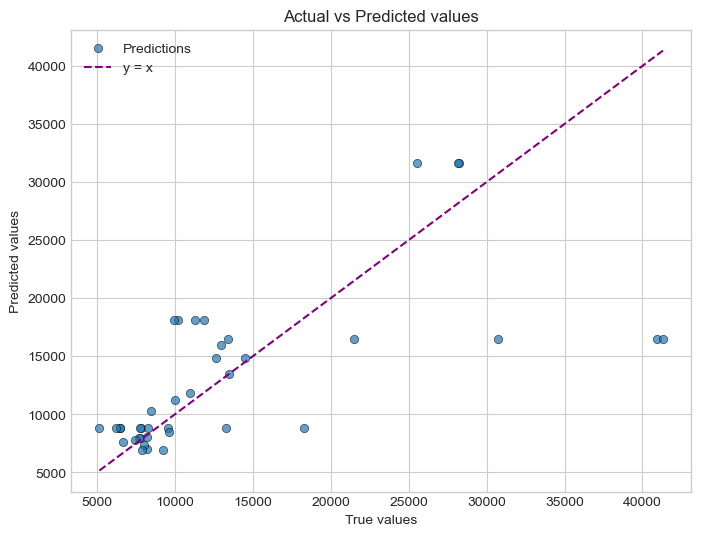

In [72]:
plot_actual_predicted(y_test_original_scale, y_pred_not_scaled)

- Analysis : we notice that the points do not follow the pattern the way we want so we will need some improvement

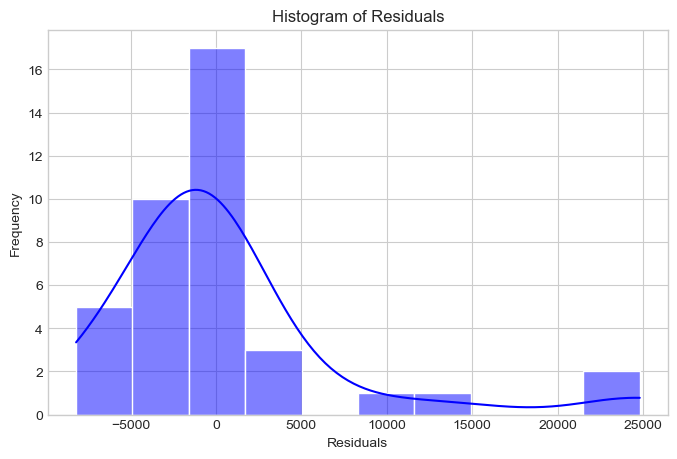

In [73]:
histogram_residuals(y_test_original_scale, y_pred_not_scaled)

- The residuals are right-skewed, indicating the model tends to underestimate some values, with moderate variance and a few outliers, suggesting potential improvements through transformation, feature scaling, or a more robust model.

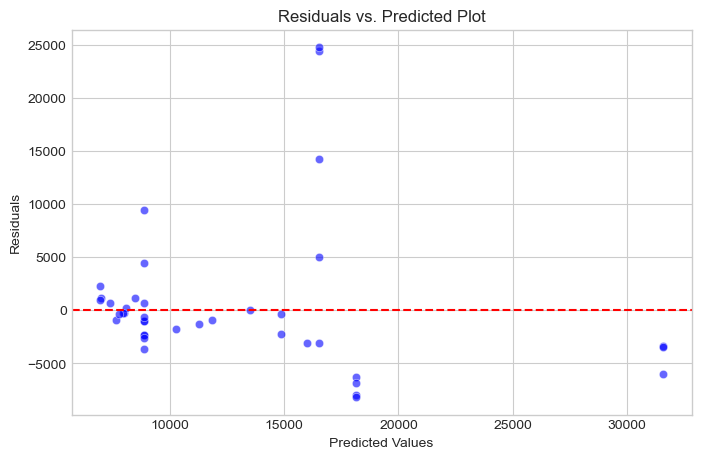

In [74]:
plot_residuals_vs_predicted(y_test_original_scale, y_pred_not_scaled)

- Residuals vs. Predicted Plot: Residuals show patterns, indicating model bias or underfitting.

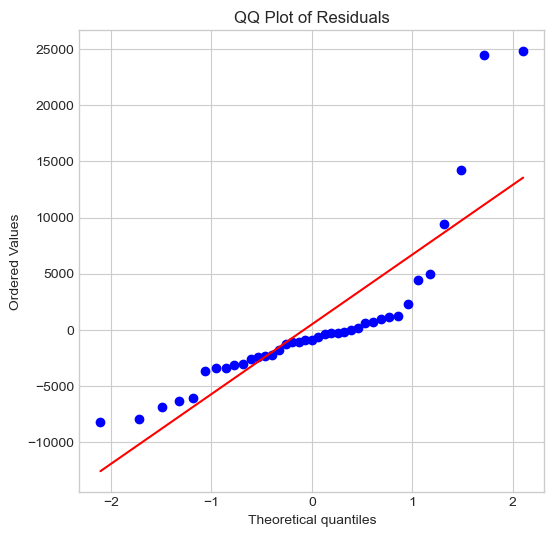

In [75]:
residuals = y_test_original_scale - y_pred_not_scaled
plot_qq(residuals)

Residuals deviate from normality

- Analyze the diffrent results :

According to the performance measures the model is not performing well because of the quite small R2 value and the relatively high value for the error measures.

We can also see that our model does follow the pattern we want but not with the amount we want so we it will need a bit of improvement


- Use hypermarameter tuning to improve the model by selecting the best epsilon value :

In [76]:
from skopt.space import Categorical

pipeline_bayes = make_pipeline(
    GaussianNaiveBayesRegressor()  
)

search_space = {
    'gaussiannaivebayesregressor__epsilon': Categorical([ 2e-3,3e-3,4e-3,5e-3,6e-3,7e-3,8e-3 ,9.4e-3]),
}

bayes_search = BayesSearchCV(
    pipeline_bayes, 
    search_space, 
    n_iter=20,  
    cv=5, 
    scoring="neg_mean_squared_error", 
    n_jobs=-1
)

bayes_search.fit(X_train, y_train)

print(" Bayesian Search Best Parameters: ", bayes_search.best_params_)

best_model_bayes = bayes_search.best_estimator_

y_pred_bayes = best_model_bayes.predict(X_test)

regression_report(y_pred_bayes, y_test)

 Bayesian Search Best Parameters:  OrderedDict([('gaussiannaivebayesregressor__epsilon', 0.0094)])
       Regression performance report
   Mean squared error:  0.189 
   Mean absolute error: 0.275 
   Root mean squared error: 0.434 
   R2 score: 0.866


In [77]:
y_pred_bayes_not_scaled = scaler_y.inverse_transform(y_pred_bayes.reshape(-1, 1)).flatten()

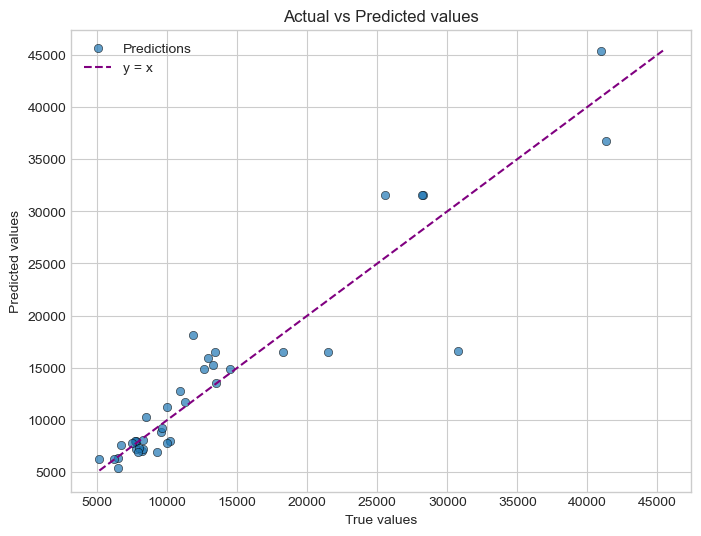

In [78]:
plot_actual_predicted(y_test_original_scale, y_pred_bayes_not_scaled)

 Predictions align well with the diagonal line, but some outliers deviate from the pattern

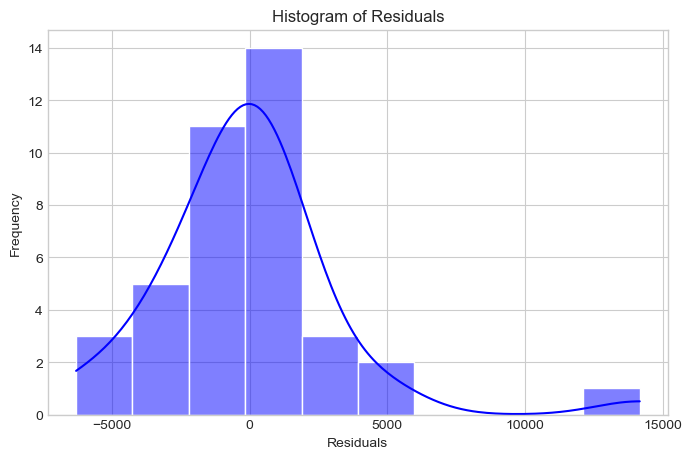

In [79]:
histogram_residuals(y_test_original_scale, y_pred_bayes_not_scaled)

 Residuals are roughly centered around zero, but the distribution is slightly skewed.

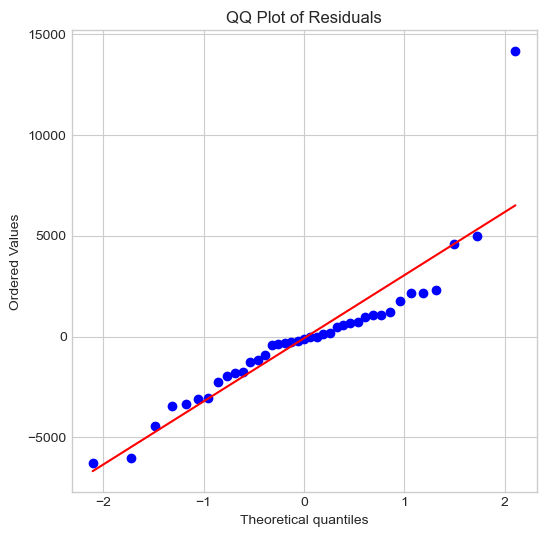

In [80]:
plot_qq(y_test_original_scale - y_pred_bayes_not_scaled)

Residuals mostly follow the red line, but slight deviations at the tails suggest minor non-normality.

- Analyzing the improvement results :
We can see that our model has significantly improved in terms of performance measures and capturing the patterns 

- Comparision between predictions and actual price values

In [82]:
actual = y_test_original_scale
pred = y_pred_bayes_not_scaled

comparaison = pd.DataFrame({
    "Actual price standardized: ":actual,
    "Predicted Price standardized: ":pred
})

print(comparaison)

    Actual price standardized:   Predicted Price standardized: 
0                       30760.0                    16595.204730
1                        9549.0                     8850.950869
2                       11850.0                    18150.000000
3                       28248.0                    31600.000000
4                        7799.0                     7243.274002
5                        7788.0                     7898.000000
6                        9258.0                     6938.000000
7                       10198.0                     8013.000000
8                        7775.0                     7995.000000
9                       13295.0                    15250.000000
10                       8238.0                     8058.000000
11                      18280.0                    16500.000000
12                       9988.0                    11248.000000
13                      40960.0                    45400.000000
14                       6488.0         

- Conclusion :
    - The overall Naive Bayes performance is good , with quite law error performance measures and a high R2 score.
    - The predictions comparisions are quite close with the presence of some outliers that we can see them present in our comparision.
    - Hyper paramter tuning helped in improving the model perfomance noticebally 



# ANN Regression for Car Price Prediction

This notebook focuses exclusively on improving the Artificial Neural Network (ANN) model for car price prediction through:
- Enhanced data preprocessing and feature engineering
- Systematic neural architecture optimization
- Advanced training techniques
- Comprehensive model evaluation

## 1. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, PReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError, Huber
from tensorflow.keras.metrics import RootMeanSquaredError
import time

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Load and Explore Data

In [24]:
# Load the data
x_train = pd.DataFrame(X_train_original_scale)
y_train = pd.DataFrame(y_train_original_scale)
x_test = pd.DataFrame(X_test_original_scale)
y_test = pd.DataFrame(y_test_original_scale)

print("Training features shape:", x_train.shape)
print("Training target shape:", y_train.shape)
print("Test features shape:", x_test.shape)
print("Test target shape:", y_test.shape)

# Check for missing values
print("\nMissing values in training data:", x_train.isnull().sum().sum())
print("Missing values in test data:", x_test.isnull().sum().sum())

Training features shape: (162, 67)
Training target shape: (162, 1)
Test features shape: (39, 67)
Test target shape: (39, 1)

Missing values in training data: 0
Missing values in test data: 0


## 3. Enhanced Exploratory Data Analysis


Feature Statistics:


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,power_to_weight,num_cylinders,engine_size_per_cylinder,combined_mpg
count,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000
mean,0.901235,122.808642,98.756790,174.230247,65.897531,53.746296,2555.654321,126.166667,3.318457,3.257346,10.092654,103.845679,5140.123457,25.043210,30.512346,0.040079,4.370370,28.794856,27.777778
std,1.252128,33.150988,5.996468,12.069087,2.068424,2.477956,508.300595,40.166617,0.266019,0.319479,3.877837,37.682652,494.184802,6.085671,6.397047,0.009358,1.079964,4.934102,6.188800
min,-2.000000,65.000000,86.600000,144.600000,61.800000,47.800000,1819.000000,70.000000,2.540000,2.070000,7.000000,52.000000,4150.000000,13.000000,16.000000,0.019936,2.000000,19.750000,15.000000
25%,0.000000,101.250000,94.500000,166.800000,64.200000,52.000000,2174.250000,98.000000,3.150000,3.127500,8.600000,72.250000,4800.000000,19.000000,25.000000,0.034346,4.000000,24.500000,22.125000
50%,1.000000,118.000000,96.750000,173.100000,65.500000,54.100000,2422.500000,119.500000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,0.037961,4.000000,27.500000,27.000000
75%,2.000000,145.000000,102.300000,183.400000,66.575000,55.575000,2931.500000,141.000000,3.540000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,0.043848,4.000000,30.500000,32.000000
max,3.000000,256.000000,115.600000,202.600000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,45.000000,50.000000,0.075109,12.000000,43.000000,47.500000



Target Statistics:


,price
count,162.000000
mean,13137.796296
std,7653.384687
min,5118.000000
25%,7641.250000
50%,10646.500000
75%,16512.000000
max,45400.000000


Potential outliers in target: 11


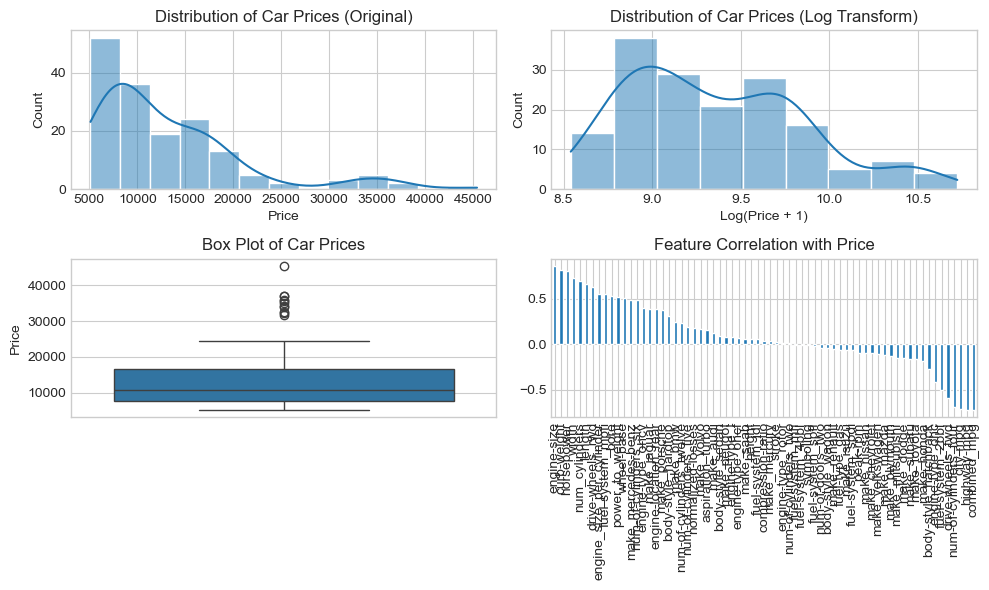

In [25]:
# Feature statistics
print("\nFeature Statistics:")
display(x_train.describe())

# Target statistics
print("\nTarget Statistics:")
display(y_train.describe())

# Check for outliers in the target variable
Q1 = y_train['price'].quantile(0.25)
Q3 = y_train['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Potential outliers in target: {((y_train['price'] < lower_bound) | (y_train['price'] > upper_bound)).sum()}")

# Visualize distribution and transformations
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.histplot(y_train['price'], kde=True)
plt.title('Distribution of Car Prices (Original)')
plt.xlabel('Price')

# Log transform for skewed price distribution
plt.subplot(2, 2, 2)
sns.histplot(np.log1p(y_train['price']), kde=True)
plt.title('Distribution of Car Prices (Log Transform)')
plt.xlabel('Log(Price + 1)')

# Boxplot to visualize outliers
plt.subplot(2, 2, 3)
sns.boxplot(y=y_train['price'])
plt.title('Box Plot of Car Prices')
plt.ylabel('Price')

# Feature correlation analysis
plt.subplot(2, 2, 4)
correlation = x_train.corrwith(y_train['price']).sort_values(ascending=False)
correlation.plot(kind='bar', figsize=(10, 6))
plt.title('Feature Correlation with Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. Feature Engineering and Preprocessing

In [26]:
# Handle outliers in target (capping extreme values)
y_train_processed = y_train.copy()
y_train_processed['price'] = np.where(y_train['price'] > upper_bound, upper_bound, 
                              np.where(y_train['price'] < lower_bound, lower_bound, y_train['price']))

# Feature selection
selector = SelectKBest(f_regression, k='all')
selector.fit(x_train, y_train_processed['price'])
feature_scores = pd.DataFrame({'Feature': x_train.columns, 'Score': selector.scores_})
top_features = feature_scores.sort_values('Score', ascending=False)
print("\nTop 10 important features:")
display(top_features.head(10))

# Create polynomial features for top numerical features
# Identify top numerical features
numerical_features = x_train.select_dtypes(include=['int64', 'float64']).columns
top_num_features = [col for col in top_features['Feature'].head(5) if col in numerical_features]

# Create a copy of the datasets for feature engineering
x_train_fe = x_train.copy()
x_test_fe = x_test.copy()

for feature in top_num_features:
    x_train_fe[f'{feature}_squared'] = x_train_fe[feature] ** 2
    x_test_fe[f'{feature}_squared'] = x_test_fe[feature] ** 2

# Add interaction terms between top features
if len(top_num_features) >= 2:
    for i in range(len(top_num_features)-1):
        for j in range(i+1, len(top_num_features)):
            feat1, feat2 = top_num_features[i], top_num_features[j]
            x_train_fe[f'{feat1}_x_{feat2}'] = x_train_fe[feat1] * x_train_fe[feat2]
            x_test_fe[f'{feat1}_x_{feat2}'] = x_test_fe[feat1] * x_test_fe[feat2]

print(f"Features after engineering: {x_train_fe.shape[1]}")

# Scaling and transformations
# Standard scaling
scaler_standard = StandardScaler()
X_train_scaled = scaler_standard.fit_transform(x_train_fe)
X_test_scaled = scaler_standard.transform(x_test_fe)

# Power transform for potentially better handling of skewed features
power_transformer = PowerTransformer(method='yeo-johnson')
X_train_power = power_transformer.fit_transform(x_train_fe)
X_test_power = power_transformer.transform(x_test_fe)

# Robust scaling (less sensitive to outliers)
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(x_train_fe)
X_test_robust = robust_scaler.transform(x_test_fe)

# For target, try both regular and log transform scaling
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_processed)
y_test_scaled = y_scaler.transform(y_test)

# Log transform version
y_train_log = np.log1p(y_train_processed)
y_test_log = np.log1p(y_test)
y_log_scaler = StandardScaler()
y_train_log_scaled = y_log_scaler.fit_transform(y_train_log)
y_test_log_scaled = y_log_scaler.transform(y_test_log)


Top 10 important features:


,Feature,Score
6,curb-weight,417.126308
7,engine-size,355.022676
11,horsepower,323.655484
4,width,209.455501
18,combined_mpg,206.712397
14,highway-mpg,202.571134
13,city-mpg,195.206119
3,length,152.968420
56,num-of-cylinders_four,149.498621
48,drive-wheels_rwd,125.362874


Features after engineering: 82


## 5. Custom Callbacks and Helpers for Model Training

In [27]:
# Custom callback to save best weights in memory to avoid TensorFlow model loading issues
class BestWeightsCallback(tf.keras.callbacks.Callback):
    def __init__(self, monitor='val_loss', mode='min'):
        super(BestWeightsCallback, self).__init__()
        self.monitor = monitor
        self.best_weights = None
        self.best_epoch = 0
        self.mode = mode
        if mode == 'min':
            self.best = float('inf')
            self.monitor_op = lambda a, b: a < b
        else:  # 'max'
            self.best = float('-inf')
            self.monitor_op = lambda a, b: a > b

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return
        
        if self.monitor_op(current, self.best):
            self.best = current
            self.best_epoch = epoch + 1
            self.best_weights = self.model.get_weights()
            print(f'\nEpoch {epoch+1}: New best {self.monitor} = {current:.6f}')

# Training utility function
def train_model(X_train, y_train, X_val, y_val, model, 
                batch_size=32, epochs=500, optimizer='adam', learning_rate=0.001,
                loss='mse', patience=15):
    
    # Best weights callback
    best_weights_callback = BestWeightsCallback(monitor='val_loss', mode='min')
    
    # Define callbacks
    callbacks = [
        # Early stopping
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            verbose=1,
            min_delta=0.0001
        ),
        # Reduce learning rate when training plateaus
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            verbose=1,
            min_delta=0.0001,
            min_lr=1e-6
        ),
        # Custom callback to track best weights
        best_weights_callback
    ]
    
    # Configure optimizer
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9, nesterov=True)
    
    # Configure loss function
    if loss == 'mse':
        loss_fn = MeanSquaredError()
    elif loss == 'mae':
        loss_fn = MeanAbsoluteError()
    elif loss == 'huber':
        loss_fn = Huber(delta=1.0)
    
    # Compile model
    model.compile(
        optimizer=opt,
        loss=loss_fn,
        metrics=[RootMeanSquaredError()]
    )
    
    # Train model
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    training_time = time.time() - start_time
    
    # Restore best weights
    if best_weights_callback.best_weights is not None:
        print(f"Restoring best weights from epoch {best_weights_callback.best_epoch}")
        model.set_weights(best_weights_callback.best_weights)
    
    return model, history, training_time

## 6. Neural Architecture Search

In [28]:
# Split validation set
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.15, random_state=42
)

# For log-transformed target
_, _, y_train_log_main, y_val_log = train_test_split(
    X_train_scaled, y_train_log_scaled, test_size=0.15, random_state=42
)

# Define architecture search space
def create_model_architecture(input_dim, architecture_params):
    model = Sequential()
    
    # First layer always includes input shape
    model.add(Dense(architecture_params['layer_sizes'][0], input_shape=(input_dim,)))
    
    # Add batch normalization if specified
    if architecture_params['use_batch_norm']:
        model.add(BatchNormalization())
        
    # Add activation
    if architecture_params['activation'] == 'leaky_relu':
        model.add(LeakyReLU(alpha=0.1))
    elif architecture_params['activation'] == 'prelu':
        model.add(PReLU())
    else:  # Regular ReLU
        model.add(tf.keras.layers.Activation('relu'))
    
    # Add dropout if rate > 0
    if architecture_params['dropout_rates'][0] > 0:
        model.add(Dropout(architecture_params['dropout_rates'][0]))
    
    # Add remaining hidden layers
    for i in range(1, len(architecture_params['layer_sizes'])):
        reg = None
        if architecture_params['use_regularization']:
            reg = l1_l2(l1=1e-5, l2=1e-4)
            
        model.add(Dense(architecture_params['layer_sizes'][i], kernel_regularizer=reg))
        
        if architecture_params['use_batch_norm']:
            model.add(BatchNormalization())
            
        if architecture_params['activation'] == 'leaky_relu':
            model.add(LeakyReLU(alpha=0.1))
        elif architecture_params['activation'] == 'prelu':
            model.add(PReLU())
        else:  # Regular ReLU
            model.add(tf.keras.layers.Activation('relu'))
        
        if i < len(architecture_params['dropout_rates']) and architecture_params['dropout_rates'][i] > 0:
            model.add(Dropout(architecture_params['dropout_rates'][i]))
    
    # Output layer
    model.add(Dense(1))
    
    return model

# Define architectures to try
architecture_search_space = [
    {
        'name': 'Small Network',
        'layer_sizes': [64, 32],
        'dropout_rates': [0.2, 0.1],
        'activation': 'relu',
        'use_batch_norm': False,
        'use_regularization': False
    },
    {
        'name': 'Medium Network with Regularization',
        'layer_sizes': [128, 64, 32],
        'dropout_rates': [0.3, 0.3, 0.2],
        'activation': 'relu',
        'use_batch_norm': True,
        'use_regularization': True
    },
    {
        'name': 'Deep Network',
        'layer_sizes': [256, 128, 64, 32],
        'dropout_rates': [0.4, 0.3, 0.3, 0.2],
        'activation': 'leaky_relu',
        'use_batch_norm': True,
        'use_regularization': True
    },
    {
        'name': 'Wide Network',
        'layer_sizes': [512, 256, 128],
        'dropout_rates': [0.5, 0.4, 0.3],
        'activation': 'leaky_relu',
        'use_batch_norm': True,
        'use_regularization': True
    },
    {
        'name': 'PReLU Network',
        'layer_sizes': [256, 128, 64],
        'dropout_rates': [0.4, 0.3, 0.2],
        'activation': 'prelu',
        'use_batch_norm': True,
        'use_regularization': True
    }
]

# Training parameters to try
training_params = [
    {'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'loss': 'mse'},
    {'optimizer': 'adam', 'learning_rate': 0.0005, 'batch_size': 64, 'loss': 'mse'},
    {'optimizer': 'rmsprop', 'learning_rate': 0.001, 'batch_size': 32, 'loss': 'mse'},
    {'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'loss': 'huber'}
]

# Target transformation options
target_options = [
    {'name': 'Standard Scaled', 'X_train': X_train_main, 'y_train': y_train_main, 
     'X_val': X_val, 'y_val': y_val, 'X_test': X_test_scaled, 'y_test': y_test_scaled,
     'inverse_func': lambda y: y_scaler.inverse_transform(y)},
    
    {'name': 'Log Transformed', 'X_train': X_train_main, 'y_train': y_train_log_main,
     'X_val': X_val, 'y_val': y_val_log, 'X_test': X_test_scaled, 'y_test': y_test_log_scaled,
     'inverse_func': lambda y: np.expm1(y_log_scaler.inverse_transform(y))}
]

## 7. Run Architecture Search



Training: Standard Scaled + Small Network + adam (lr=0.001) + mse


Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 3.3078 - root_mean_squared_error: 1.8187
Epoch 1: New best val_loss = 0.262603
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 2.3489 - root_mean_squared_error: 1.5267 - val_loss: 0.2626 - val_root_mean_squared_error: 0.5124 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 2.0012 - root_mean_squared_error: 1.4146
Epoch 2: New best val_loss = 0.242690
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.2941 - root_mean_squared_error: 1.1284 - val_loss: 0.2427 - val_root_mean_squared_error: 0.4926 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5732 - root_mean_squared_error: 0.7552 - val_loss: 0.2883 - val_root_mean_squared_error: 0.5369 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5189 - root_mean_squared_error: 0.7203 - val_loss: 0.3048 - val_root_mean_squared_error: 0.5520 - learning_rate: 0.0010
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━

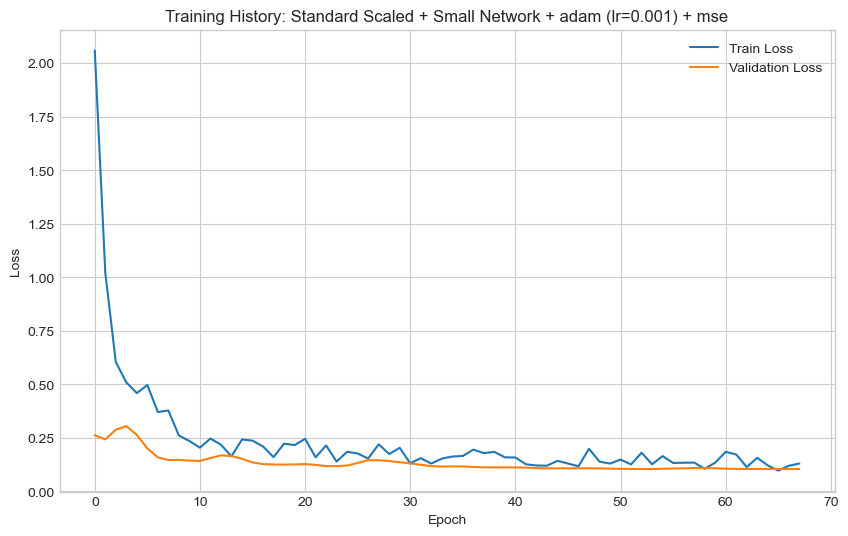



Training: Standard Scaled + Small Network + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 935ms/step - loss: 0.9710 - root_mean_squared_error: 0.9854
Epoch 1: New best val_loss = 0.339189
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 1.0339 - root_mean_squared_error: 1.0166 - val_loss: 0.3392 - val_root_mean_squared_error: 0.5824 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6569 - root_mean_squared_error: 0.8105
Epoch 2: New best val_loss = 0.299033
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.7276 - root_mean_squared_error: 0.8527 - val_loss: 0.2990 - val_root_mean_squared_error: 0.5468 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.5216 - root_mean_squared_error: 0.7222
Epoch 3: New best val_loss = 0.275207
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.6118 - root_mean_squared_error: 0.7814 - val_loss: 0.2752 - val_root_mean_squared_error: 0.5246 - learning_rate: 5.0000e-04
Ep

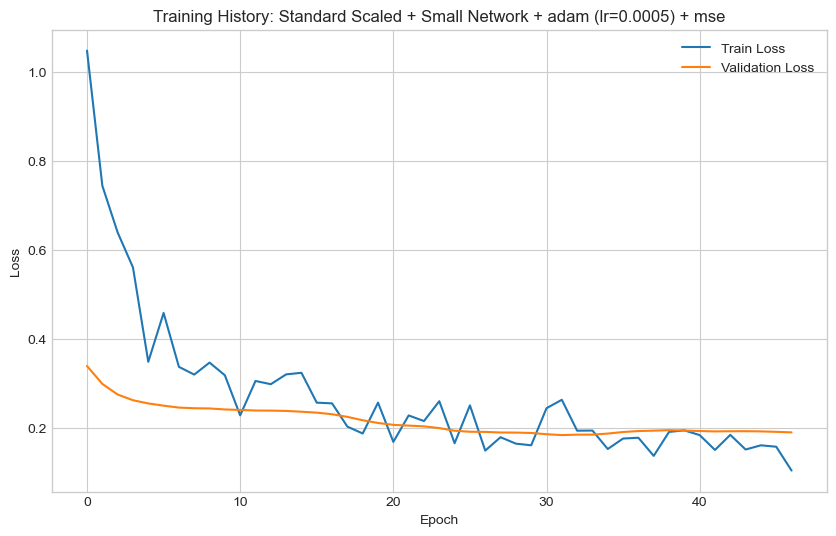



Training: Standard Scaled + Small Network + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 653ms/step - loss: 3.1547 - root_mean_squared_error: 1.7761
Epoch 1: New best val_loss = 0.394520
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 1.9113 - root_mean_squared_error: 1.3698 - val_loss: 0.3945 - val_root_mean_squared_error: 0.6281 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3960 - root_mean_squared_error: 0.6293
Epoch 2: New best val_loss = 0.336251
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5377 - root_mean_squared_error: 0.7303 - val_loss: 0.3363 - val_root_mean_squared_error: 0.5799 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6043 - root_mean_squared_error: 0.7773
Epoch 3: New best val_loss = 0.265694
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5266 - root_mean_squared_error: 0.7249 - val_loss: 0.2657 - val_root_mean_squared_error: 0.5155 - learning_rate: 0.0010
Epoch 4/500
5

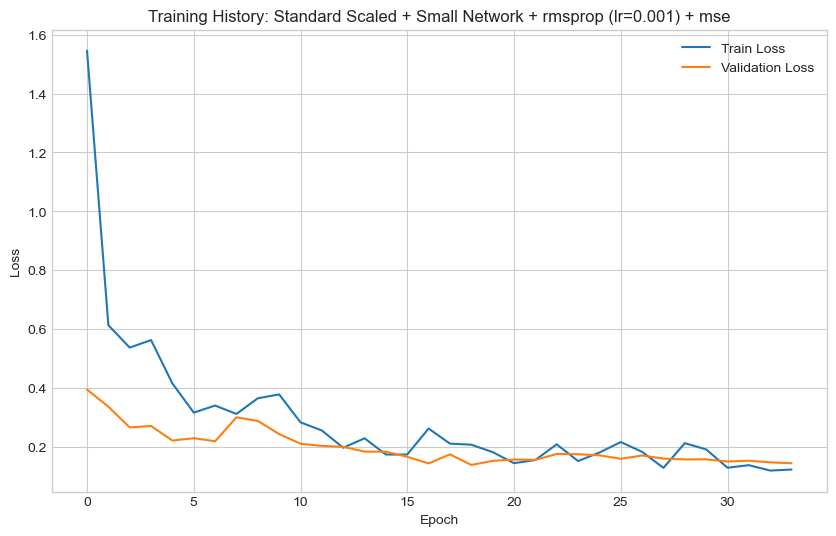



Training: Standard Scaled + Small Network + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 3s 941ms/step - loss: 0.8230 - root_mean_squared_error: 1.9502
Epoch 1: New best val_loss = 0.234741
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.7745 - root_mean_squared_error: 1.7033 - val_loss: 0.2347 - val_root_mean_squared_error: 0.7376 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6140 - root_mean_squared_error: 1.5004
Epoch 2: New best val_loss = 0.162857
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4921 - root_mean_squared_error: 1.2302 - val_loss: 0.1629 - val_root_mean_squared_error: 0.5900 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3159 - root_mean_squared_error: 0.8368
Epoch 3: New best val_loss = 0.136021
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2974 - root_mean_squared_error: 0.8290 - val_loss: 0.1360 - val_root_mean_squared_error: 0.5287 - learning_rate: 0.0010
Epoch 4/500
1/

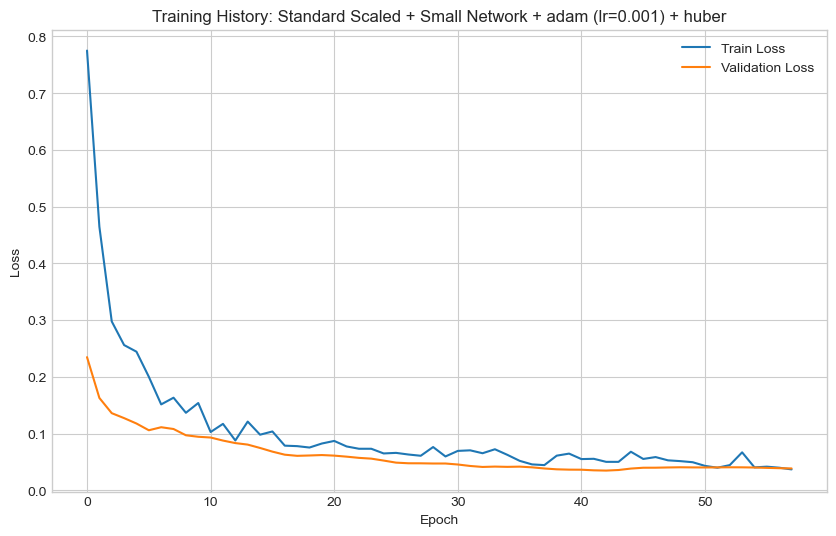



Training: Standard Scaled + Medium Network with Regularization + adam (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 2.3969 - root_mean_squared_error: 1.5409
Epoch 1: New best val_loss = 0.309743
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 1.8209 - root_mean_squared_error: 1.3374 - val_loss: 0.3097 - val_root_mean_squared_error: 0.5358 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.5951 - root_mean_squared_error: 1.2540
Epoch 2: New best val_loss = 0.236085
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.3484 - root_mean_squared_error: 1.1503 - val_loss: 0.2361 - val_root_mean_squared_error: 0.4619 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.2313 - root_mean_squared_error: 1.0994
Epoch 3: New best val_loss = 0.221022
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.2003 - root_mean_squared_error: 1.0850 - val_loss: 0.2210 - val_root_mean_squared_error: 0.4453 - learning_rate: 0.00

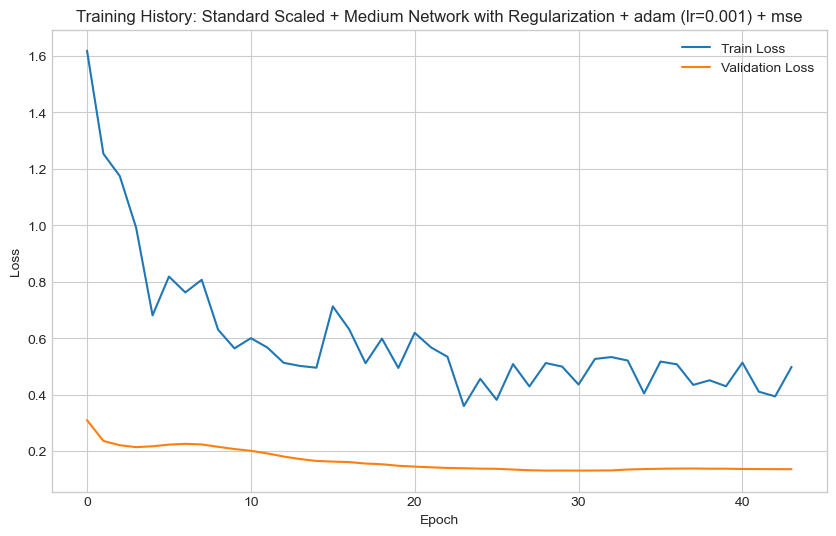



Training: Standard Scaled + Medium Network with Regularization + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 2.2845 - root_mean_squared_error: 1.5040
Epoch 1: New best val_loss = 0.700669
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - loss: 2.1461 - root_mean_squared_error: 1.4569 - val_loss: 0.7007 - val_root_mean_squared_error: 0.8234 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.8573 - root_mean_squared_error: 1.3545
Epoch 2: New best val_loss = 0.622598
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.6415 - root_mean_squared_error: 1.2714 - val_loss: 0.6226 - val_root_mean_squared_error: 0.7746 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.5045 - root_mean_squared_error: 1.2173
Epoch 3: New best val_loss = 0.545985
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.4325 - root_mean_squared_error: 1.1873 - val_loss: 0.5460 - val_root_mean_squared_error: 0.7234 - learning_r

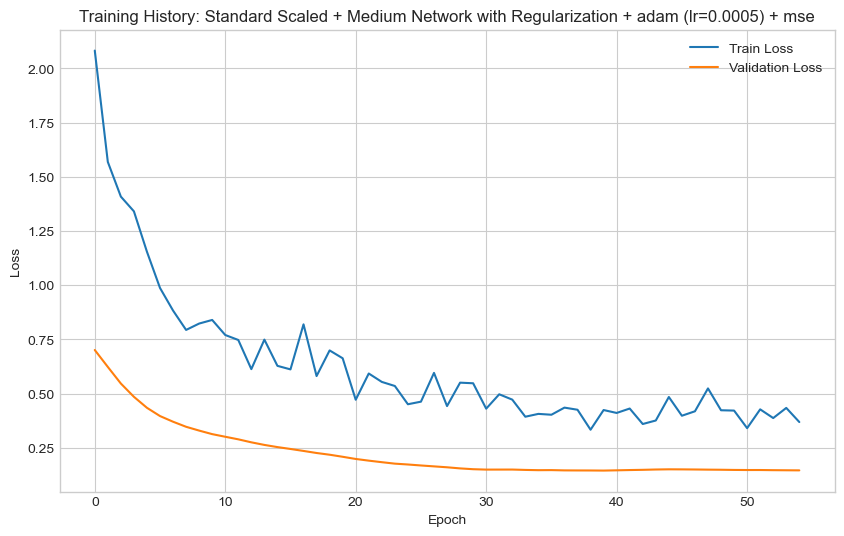



Training: Standard Scaled + Medium Network with Regularization + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 2.8942 - root_mean_squared_error: 1.6946
Epoch 1: New best val_loss = 0.505979
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 2.7597 - root_mean_squared_error: 1.6542 - val_loss: 0.5060 - val_root_mean_squared_error: 0.6952 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.8397 - root_mean_squared_error: 1.6784
Epoch 2: New best val_loss = 0.379772
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.2522 - root_mean_squared_error: 1.4901 - val_loss: 0.3798 - val_root_mean_squared_error: 0.5976 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.9388 - root_mean_squared_error: 0.9571
Epoch 3: New best val_loss = 0.280448
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1529 - root_mean_squared_error: 1.0606 - val_loss: 0.2804 - val_root_mean_squared_error: 0.5077 - learning_rate: 0.

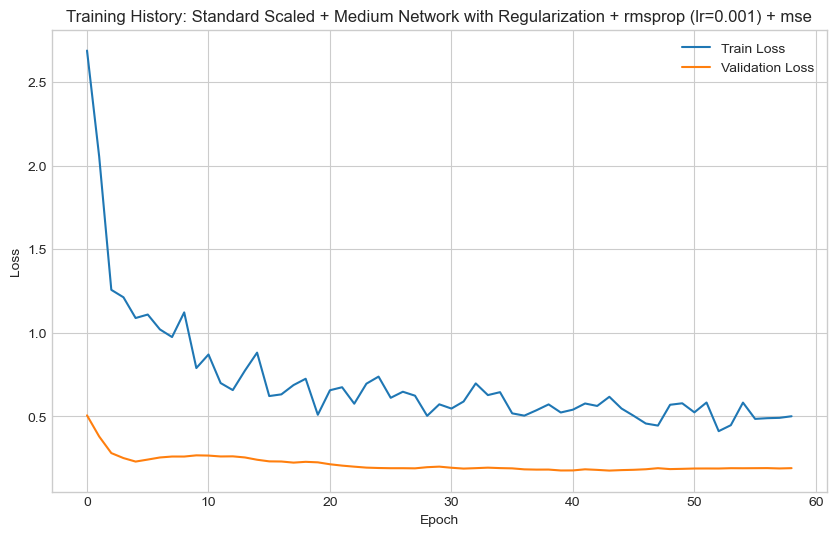



Training: Standard Scaled + Medium Network with Regularization + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.5996 - root_mean_squared_error: 1.3371
Epoch 1: New best val_loss = 0.260086
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.5926 - root_mean_squared_error: 1.3179 - val_loss: 0.2601 - val_root_mean_squared_error: 0.7215 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.4826 - root_mean_squared_error: 1.3198
Epoch 2: New best val_loss = 0.183204
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4419 - root_mean_squared_error: 1.1270 - val_loss: 0.1832 - val_root_mean_squared_error: 0.5766 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3034 - root_mean_squared_error: 0.7889
Epoch 3: New best val_loss = 0.148812
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4338 - root_mean_squared_error: 1.0205 - val_loss: 0.1488 - val_root_mean_squared_error: 0.5035 - learning_rate: 0.0

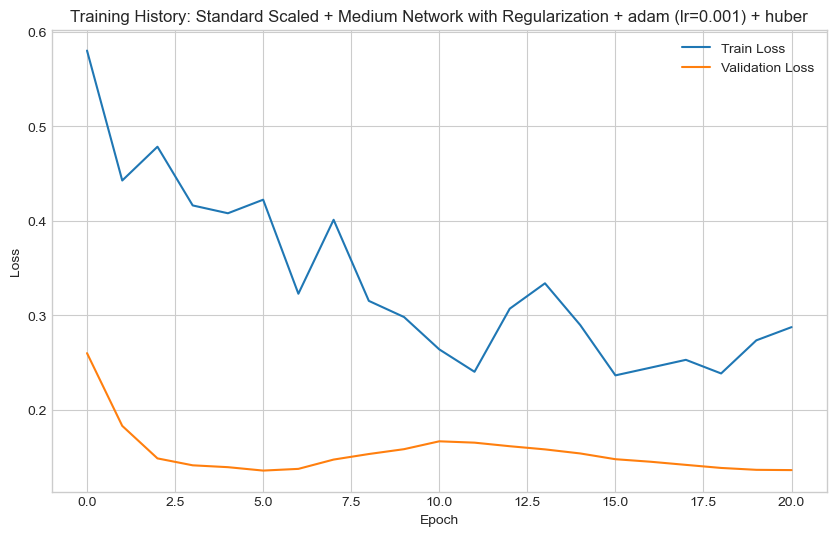



Training: Standard Scaled + Deep Network + adam (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 2.2777 - root_mean_squared_error: 1.4892
Epoch 1: New best val_loss = 0.444091
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 1.8257 - root_mean_squared_error: 1.3266 - val_loss: 0.4441 - val_root_mean_squared_error: 0.6197 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.2077 - root_mean_squared_error: 1.0713
Epoch 2: New best val_loss = 0.379494
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.0866 - root_mean_squared_error: 1.0128 - val_loss: 0.3795 - val_root_mean_squared_error: 0.5652 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.2857 - root_mean_squared_error: 1.1071
Epoch 3: New best val_loss = 0.347329
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1620 - root_mean_squared_error: 1.0493 - val_loss: 0.3473 - val_root_mean_squared_error: 0.5359 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━

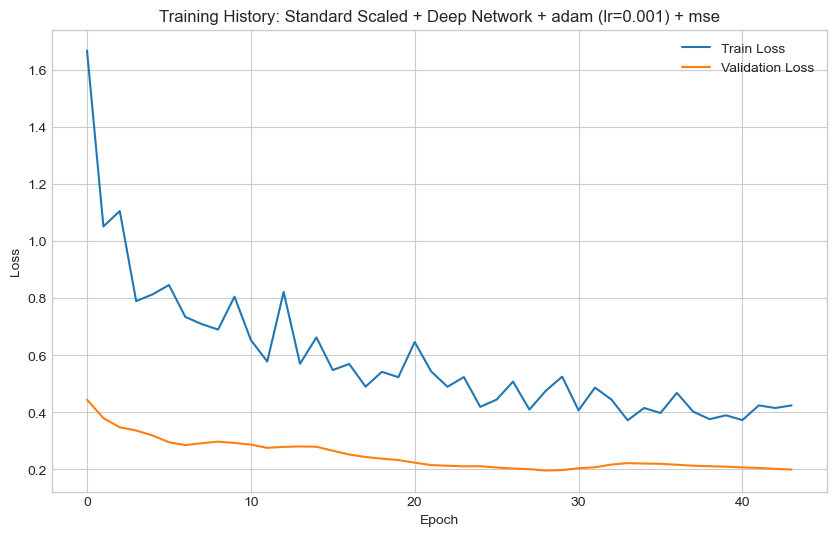



Training: Standard Scaled + Deep Network + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - loss: 1.9458 - root_mean_squared_error: 1.3732
Epoch 1: New best val_loss = 0.365535
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - loss: 2.0309 - root_mean_squared_error: 1.4037 - val_loss: 0.3655 - val_root_mean_squared_error: 0.5526 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.4285 - root_mean_squared_error: 1.1697
Epoch 2: New best val_loss = 0.325949
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.5496 - root_mean_squared_error: 1.2200 - val_loss: 0.3259 - val_root_mean_squared_error: 0.5155 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.2637 - root_mean_squared_error: 1.0970
Epoch 3: New best val_loss = 0.294319
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.3115 - root_mean_squared_error: 1.1185 - val_loss: 0.2943 - val_root_mean_squared_error: 0.4838 - learning_rate: 5.0000e-04
Epoch 

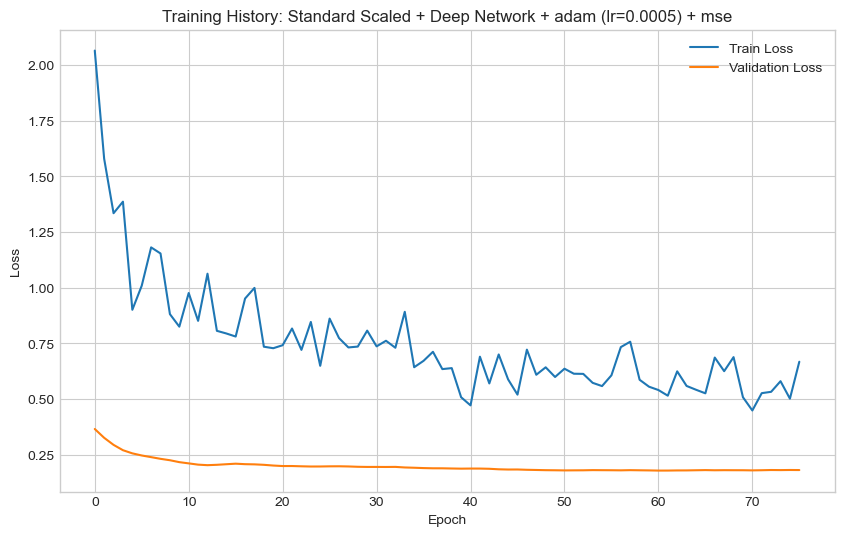



Training: Standard Scaled + Deep Network + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 1.3673 - root_mean_squared_error: 1.1432
Epoch 1: New best val_loss = 0.356969
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 1.4683 - root_mean_squared_error: 1.1862 - val_loss: 0.3570 - val_root_mean_squared_error: 0.5445 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0080 - root_mean_squared_error: 0.9734
Epoch 2: New best val_loss = 0.304131
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.1710 - root_mean_squared_error: 1.0529 - val_loss: 0.3041 - val_root_mean_squared_error: 0.4935 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.2543 - root_mean_squared_error: 1.0926
Epoch 3: New best val_loss = 0.280115
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0700 - root_mean_squared_error: 1.0038 - val_loss: 0.2801 - val_root_mean_squared_error: 0.4685 - learning_rate: 0.0010
Epoch 4/500
1/5 ━

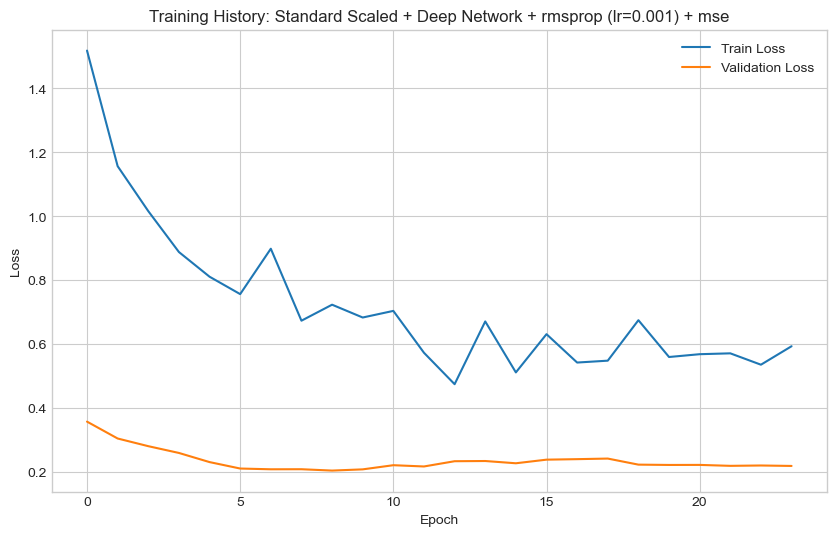



Training: Standard Scaled + Deep Network + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 1.3693 - root_mean_squared_error: 2.2839
Epoch 1: New best val_loss = 0.264014
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 1.0602 - root_mean_squared_error: 1.8853 - val_loss: 0.2640 - val_root_mean_squared_error: 0.6678 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6720 - root_mean_squared_error: 1.3319
Epoch 2: New best val_loss = 0.191978
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6356 - root_mean_squared_error: 1.2620 - val_loss: 0.1920 - val_root_mean_squared_error: 0.5203 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5310 - root_mean_squared_error: 1.0802
Epoch 3: New best val_loss = 0.159949
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5177 - root_mean_squared_error: 1.0754 - val_loss: 0.1599 - val_root_mean_squared_error: 0.4482 - learning_rate: 0.0010
Epoch 4/500
1/5 ━

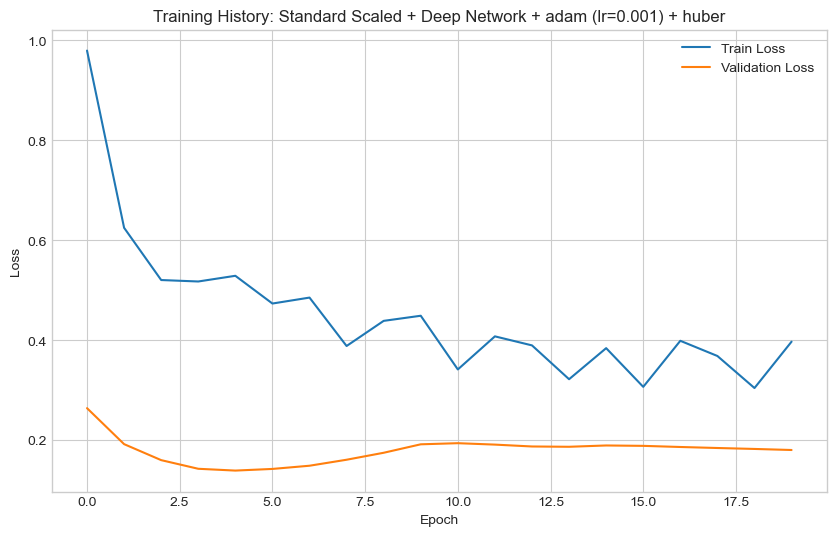



Training: Standard Scaled + Wide Network + adam (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 2.8776 - root_mean_squared_error: 1.6578
Epoch 1: New best val_loss = 0.387926
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 2.2320 - root_mean_squared_error: 1.4463 - val_loss: 0.3879 - val_root_mean_squared_error: 0.5082 - learning_rate: 0.0010
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.1947 - root_mean_squared_error: 1.0305 - val_loss: 0.4614 - val_root_mean_squared_error: 0.5758 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.2372 - root_mean_squared_error: 1.0516 - val_loss: 0.4453 - val_root_mean_squared_error: 0.5615 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.1930 - root_mean_squared_error: 1.0257 - val_loss: 0.4328 - val_root_mean_squared_error: 0.5500 - learning_rate: 0.0010
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9420 - root_mean_squared_error

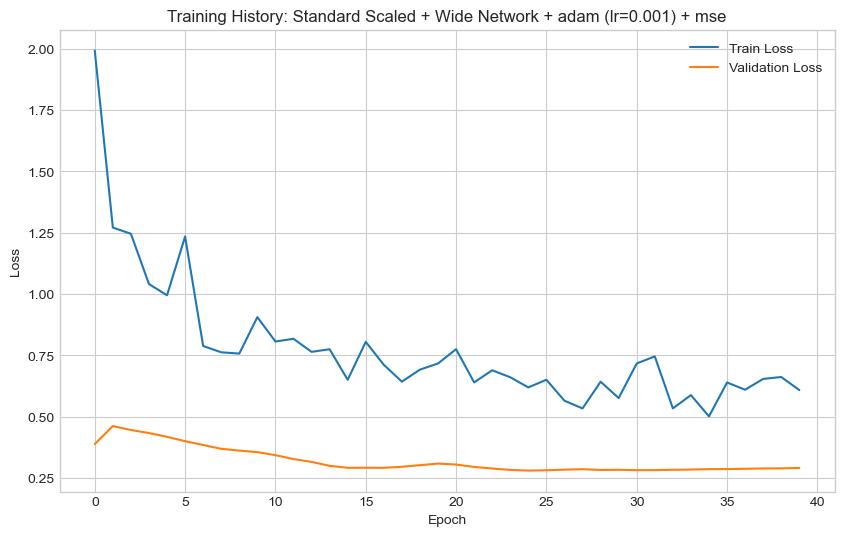



Training: Standard Scaled + Wide Network + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - loss: 3.1233 - root_mean_squared_error: 1.7303
Epoch 1: New best val_loss = 0.630067
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - loss: 2.8804 - root_mean_squared_error: 1.6581 - val_loss: 0.6301 - val_root_mean_squared_error: 0.7076 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.4540 - root_mean_squared_error: 1.1509
Epoch 2: New best val_loss = 0.490893
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.5382 - root_mean_squared_error: 1.1867 - val_loss: 0.4909 - val_root_mean_squared_error: 0.6012 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.1169 - root_mean_squared_error: 0.9937
Epoch 3: New best val_loss = 0.416088
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.1376 - root_mean_squared_error: 1.0041 - val_loss: 0.4161 - val_root_mean_squared_error: 0.5353 - learning_rate: 5.0000e-04
Epoch 

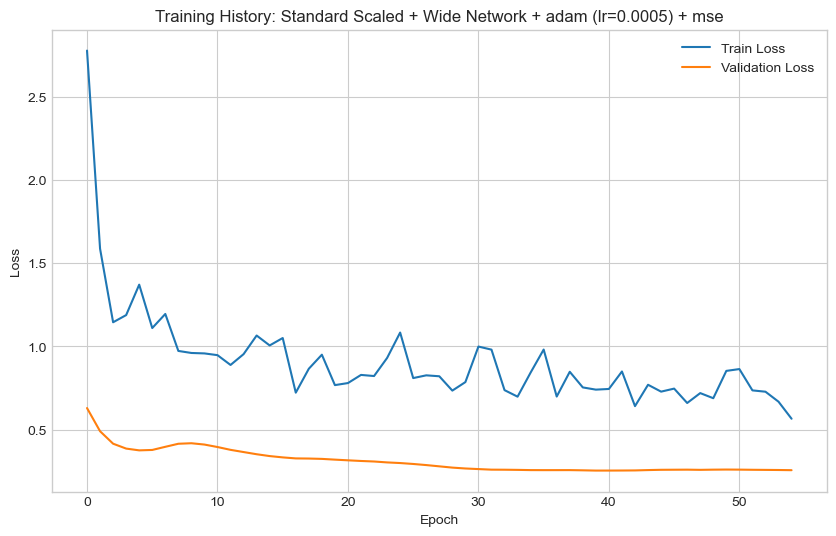



Training: Standard Scaled + Wide Network + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 2.4839 - root_mean_squared_error: 1.5344
Epoch 1: New best val_loss = 0.509463
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 1.8702 - root_mean_squared_error: 1.3154 - val_loss: 0.5095 - val_root_mean_squared_error: 0.6159 - learning_rate: 0.0010
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.4636 - root_mean_squared_error: 1.1545 - val_loss: 0.5740 - val_root_mean_squared_error: 0.6661 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.3343 - root_mean_squared_error: 1.0973
Epoch 3: New best val_loss = 0.458101
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.2277 - root_mean_squared_error: 1.0472 - val_loss: 0.4581 - val_root_mean_squared_error: 0.5725 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.1730 - root_mean_squared_error: 1.0211
Epoch 4: New best val_loss = 0.361898
5/5 ━

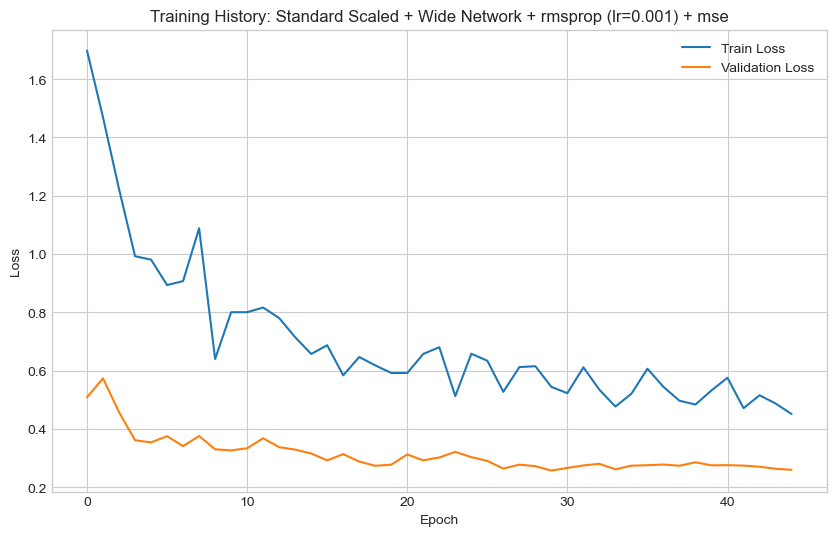



Training: Standard Scaled + Wide Network + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 1.0529 - root_mean_squared_error: 1.7272
Epoch 1: New best val_loss = 0.240989
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.9014 - root_mean_squared_error: 1.5274 - val_loss: 0.2410 - val_root_mean_squared_error: 0.4742 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6313 - root_mean_squared_error: 1.1085
Epoch 2: New best val_loss = 0.236378
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6156 - root_mean_squared_error: 1.0716 - val_loss: 0.2364 - val_root_mean_squared_error: 0.4611 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6325 - root_mean_squared_error: 1.1591 - val_loss: 0.2413 - val_root_mean_squared_error: 0.4723 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5470 - root_mean_squared_error: 1.0112 - val_loss: 0.2554 - val_root_mean_squared_e

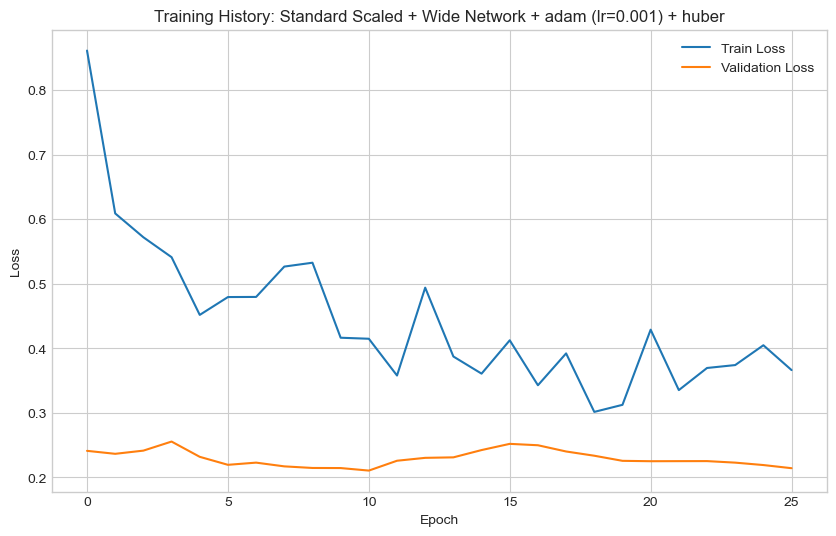



Training: Standard Scaled + PReLU Network + adam (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 2.1782 - root_mean_squared_error: 1.4578
Epoch 1: New best val_loss = 0.488981
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 1.8771 - root_mean_squared_error: 1.3494 - val_loss: 0.4890 - val_root_mean_squared_error: 0.6602 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.9827 - root_mean_squared_error: 0.9641
Epoch 2: New best val_loss = 0.444606
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0741 - root_mean_squared_error: 1.0086 - val_loss: 0.4446 - val_root_mean_squared_error: 0.6256 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8220 - root_mean_squared_error: 0.8767 - val_loss: 0.4906 - val_root_mean_squared_error: 0.6613 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6152 - root_mean_squared_error: 0.7494 - val_loss: 0.5236 - val_root_mean_squared_e

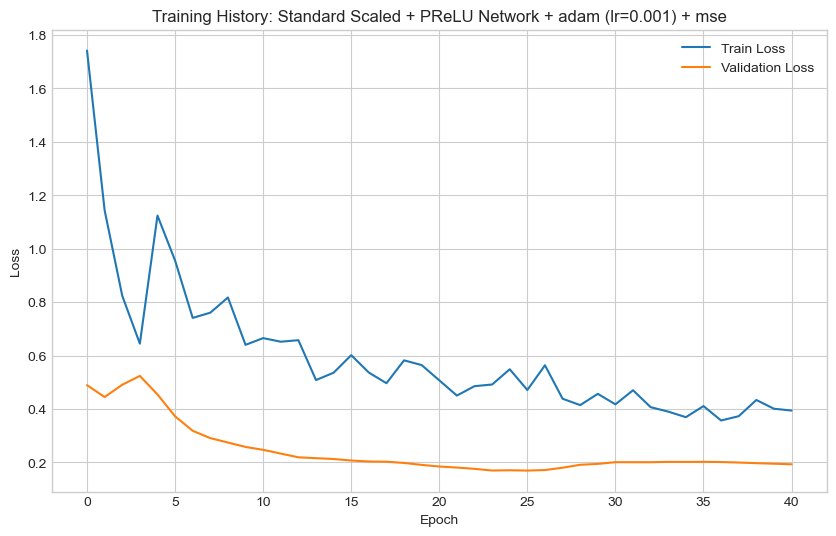



Training: Standard Scaled + PReLU Network + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - loss: 2.0295 - root_mean_squared_error: 1.4057
Epoch 1: New best val_loss = 0.460996
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - loss: 1.7889 - root_mean_squared_error: 1.3164 - val_loss: 0.4610 - val_root_mean_squared_error: 0.6384 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.8314 - root_mean_squared_error: 1.3334
Epoch 2: New best val_loss = 0.391259
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.6831 - root_mean_squared_error: 1.2762 - val_loss: 0.3913 - val_root_mean_squared_error: 0.5812 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.4526 - root_mean_squared_error: 1.1829
Epoch 3: New best val_loss = 0.337351
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.2584 - root_mean_squared_error: 1.0966 - val_loss: 0.3374 - val_root_mean_squared_error: 0.5328 - learning_rate: 5.0000e-04
Epoch

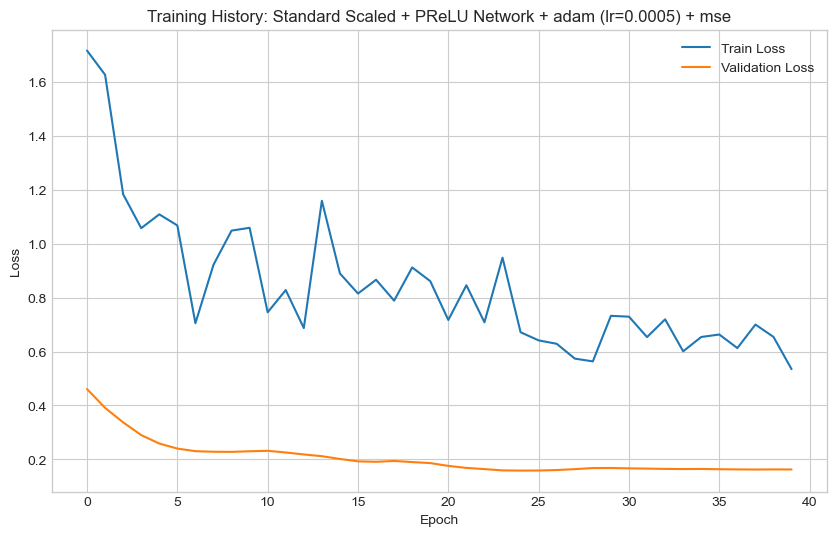



Training: Standard Scaled + PReLU Network + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 4.9557 - root_mean_squared_error: 2.2142
Epoch 1: New best val_loss = 0.311577
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 3.6306 - root_mean_squared_error: 1.8850 - val_loss: 0.3116 - val_root_mean_squared_error: 0.5083 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.1360 - root_mean_squared_error: 1.0406
Epoch 2: New best val_loss = 0.284120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.6454 - root_mean_squared_error: 1.2580 - val_loss: 0.2841 - val_root_mean_squared_error: 0.4805 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.4313 - root_mean_squared_error: 1.1730 - val_loss: 0.3081 - val_root_mean_squared_error: 0.5048 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.2427 - root_mean_squared_error: 1.0886 - val_loss: 0.3029 - val_root_mean_squared

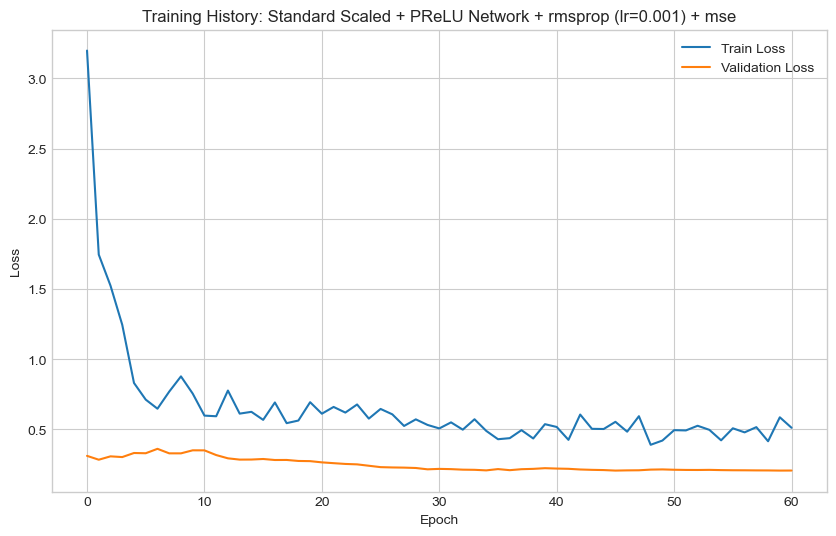



Training: Standard Scaled + PReLU Network + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 0.8717 - root_mean_squared_error: 1.4770
Epoch 1: New best val_loss = 0.221672
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.7914 - root_mean_squared_error: 1.4014 - val_loss: 0.2217 - val_root_mean_squared_error: 0.5841 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.5764 - root_mean_squared_error: 1.2014
Epoch 2: New best val_loss = 0.197952
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5093 - root_mean_squared_error: 1.0736 - val_loss: 0.1980 - val_root_mean_squared_error: 0.5404 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6638 - root_mean_squared_error: 1.3646
Epoch 3: New best val_loss = 0.182558
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5721 - root_mean_squared_error: 1.2011 - val_loss: 0.1826 - val_root_mean_squared_error: 0.5106 - learning_rate: 0.0010
Epoch 4/500
1/5 

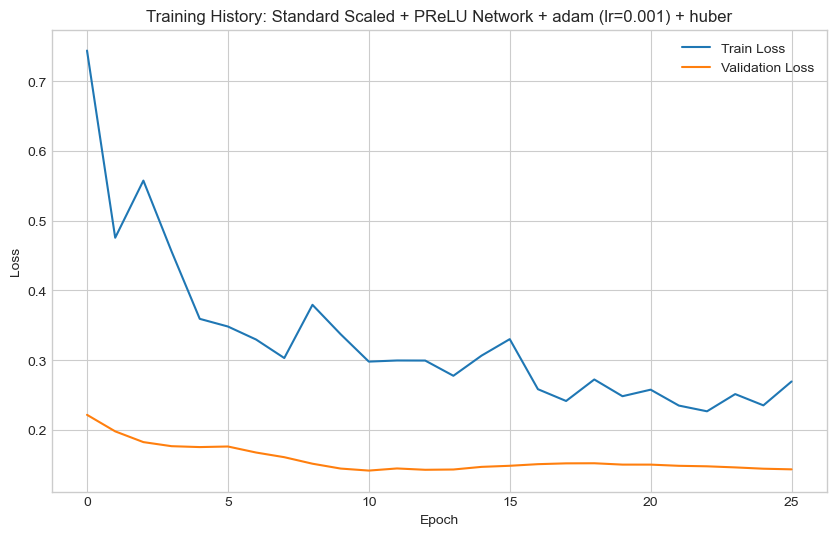



Training: Log Transformed + Small Network + adam (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 3s 898ms/step - loss: 0.8249 - root_mean_squared_error: 0.9083
Epoch 1: New best val_loss = 0.214734
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.9270 - root_mean_squared_error: 0.9623 - val_loss: 0.2147 - val_root_mean_squared_error: 0.4634 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.3389 - root_mean_squared_error: 0.5821
Epoch 2: New best val_loss = 0.144786
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4458 - root_mean_squared_error: 0.6665 - val_loss: 0.1448 - val_root_mean_squared_error: 0.3805 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3919 - root_mean_squared_error: 0.6260
Epoch 3: New best val_loss = 0.126221
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3460 - root_mean_squared_error: 0.5878 - val_loss: 0.1262 - val_root_mean_squared_error: 0.3553 - learning_rate: 0.0010
Epoch 4/500
1/5 

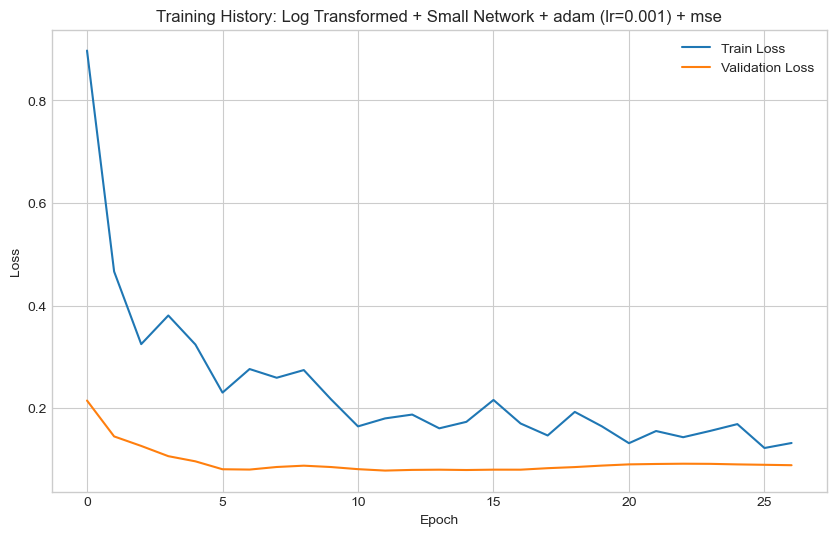



Training: Log Transformed + Small Network + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step - loss: 1.0066 - root_mean_squared_error: 1.0033
Epoch 1: New best val_loss = 0.742974
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 1.2267 - root_mean_squared_error: 1.1060 - val_loss: 0.7430 - val_root_mean_squared_error: 0.8620 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.3009 - root_mean_squared_error: 1.1405
Epoch 2: New best val_loss = 0.618132
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.5124 - root_mean_squared_error: 1.2287 - val_loss: 0.6181 - val_root_mean_squared_error: 0.7862 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.9334 - root_mean_squared_error: 0.9661
Epoch 3: New best val_loss = 0.532548
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.9676 - root_mean_squared_error: 0.9836 - val_loss: 0.5325 - val_root_mean_squared_error: 0.7298 - learning_rate: 5.0000e-04
Ep

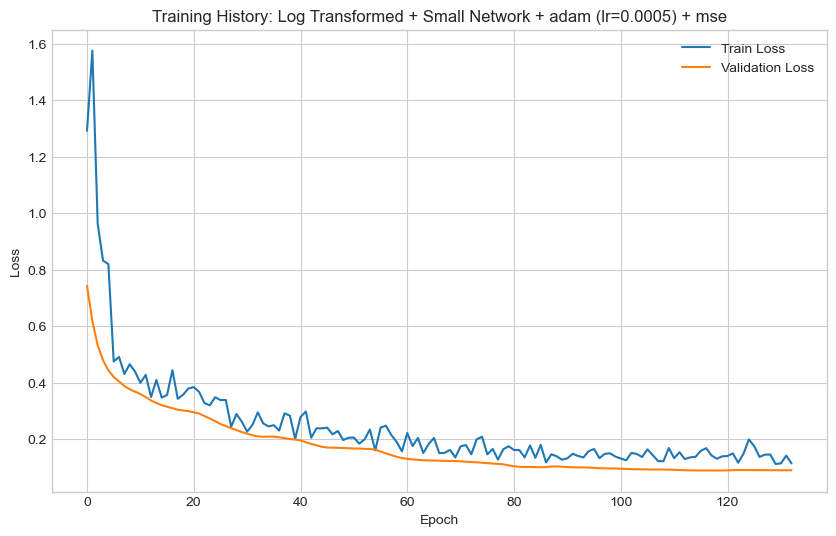



Training: Log Transformed + Small Network + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 717ms/step - loss: 0.8722 - root_mean_squared_error: 0.9339
Epoch 1: New best val_loss = 0.250438
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.8360 - root_mean_squared_error: 0.9129 - val_loss: 0.2504 - val_root_mean_squared_error: 0.5004 - learning_rate: 0.0010
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5593 - root_mean_squared_error: 0.7475 - val_loss: 0.2563 - val_root_mean_squared_error: 0.5063 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2916 - root_mean_squared_error: 0.5400
Epoch 3: New best val_loss = 0.206774
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3988 - root_mean_squared_error: 0.6302 - val_loss: 0.2068 - val_root_mean_squared_error: 0.4547 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2336 - root_mean_squared_error: 0.4834
Epoch 4: New best val_loss = 0.170399
5

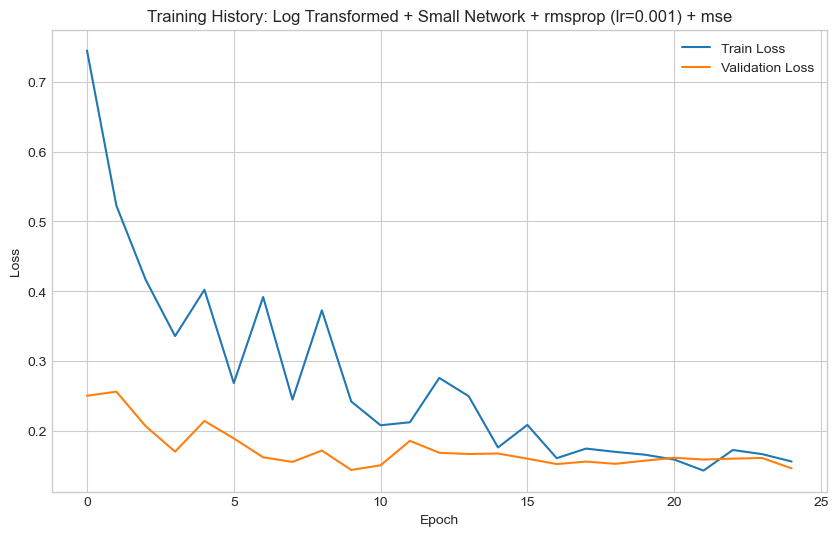



Training: Log Transformed + Small Network + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 3s 957ms/step - loss: 1.1618 - root_mean_squared_error: 1.9371
Epoch 1: New best val_loss = 0.481081
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.8638 - root_mean_squared_error: 1.5778 - val_loss: 0.4811 - val_root_mean_squared_error: 1.0352 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6737 - root_mean_squared_error: 1.3781
Epoch 2: New best val_loss = 0.283730
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4926 - root_mean_squared_error: 1.1132 - val_loss: 0.2837 - val_root_mean_squared_error: 0.7660 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3903 - root_mean_squared_error: 1.1404
Epoch 3: New best val_loss = 0.193445
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3007 - root_mean_squared_error: 0.9103 - val_loss: 0.1934 - val_root_mean_squared_error: 0.6229 - learning_rate: 0.0010
Epoch 4/500
1/

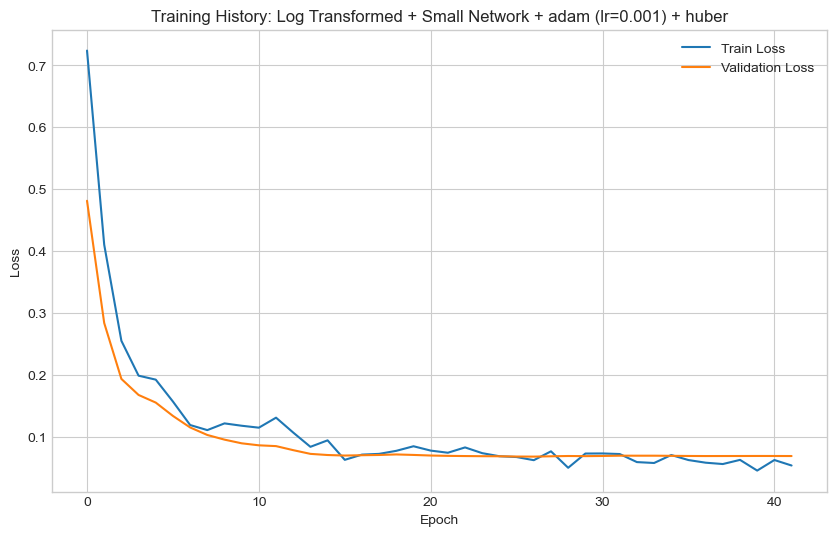



Training: Log Transformed + Medium Network with Regularization + adam (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 1.1993 - root_mean_squared_error: 1.0846
Epoch 1: New best val_loss = 1.195435
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 1.4169 - root_mean_squared_error: 1.1794 - val_loss: 1.1954 - val_root_mean_squared_error: 1.0828 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 1.9595 - root_mean_squared_error: 1.3916
Epoch 2: New best val_loss = 0.894668
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.4913 - root_mean_squared_error: 1.2084 - val_loss: 0.8947 - val_root_mean_squared_error: 0.9337 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9230 - root_mean_squared_error: 0.9487
Epoch 3: New best val_loss = 0.702987
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.0689 - root_mean_squared_error: 1.0221 - val_loss: 0.7030 - val_root_mean_squared_error: 0.8247 - learning_rate: 0.001

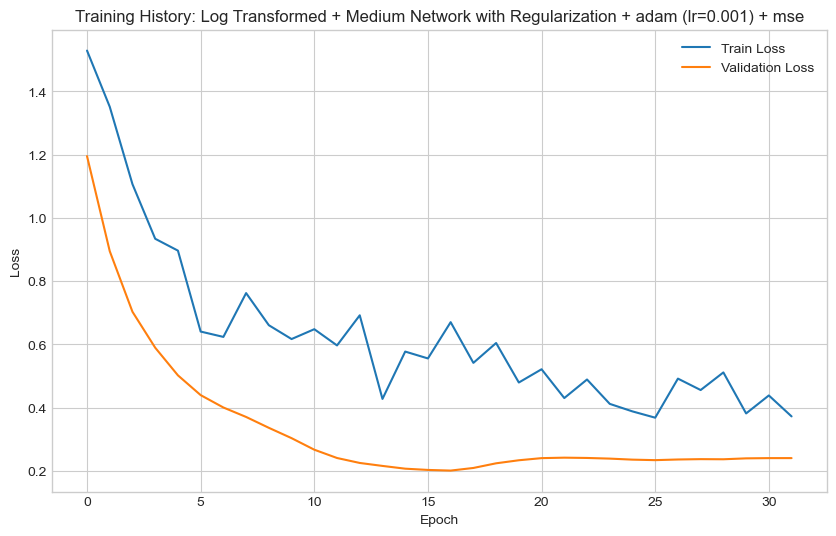



Training: Log Transformed + Medium Network with Regularization + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 2.8663 - root_mean_squared_error: 1.6863
Epoch 1: New best val_loss = 0.763586
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - loss: 2.4426 - root_mean_squared_error: 1.5537 - val_loss: 0.7636 - val_root_mean_squared_error: 0.8608 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.1019 - root_mean_squared_error: 1.4420
Epoch 2: New best val_loss = 0.685786
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.0342 - root_mean_squared_error: 1.4182 - val_loss: 0.6858 - val_root_mean_squared_error: 0.8143 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.8688 - root_mean_squared_error: 1.3587
Epoch 3: New best val_loss = 0.619843
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1.7597 - root_mean_squared_error: 1.3177 - val_loss: 0.6198 - val_root_mean_squared_error: 0.7728 - learning_r

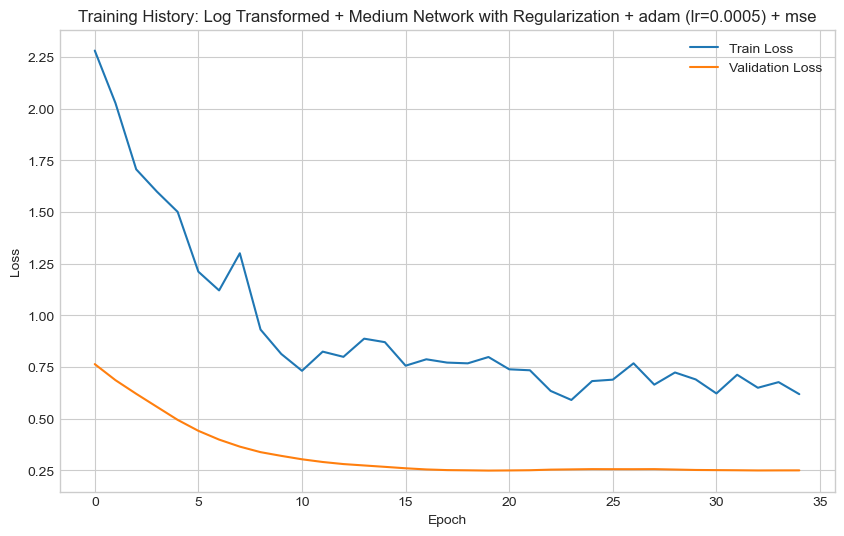



Training: Log Transformed + Medium Network with Regularization + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 2.0304 - root_mean_squared_error: 1.4171
Epoch 1: New best val_loss = 0.553620
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 1.4508 - root_mean_squared_error: 1.1890 - val_loss: 0.5536 - val_root_mean_squared_error: 0.7289 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7681 - root_mean_squared_error: 0.8636
Epoch 2: New best val_loss = 0.498312
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7067 - root_mean_squared_error: 0.8264 - val_loss: 0.4983 - val_root_mean_squared_error: 0.6899 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6811 - root_mean_squared_error: 0.8117
Epoch 3: New best val_loss = 0.468532
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6477 - root_mean_squared_error: 0.7906 - val_loss: 0.4685 - val_root_mean_squared_error: 0.6680 - learning_rate: 0.

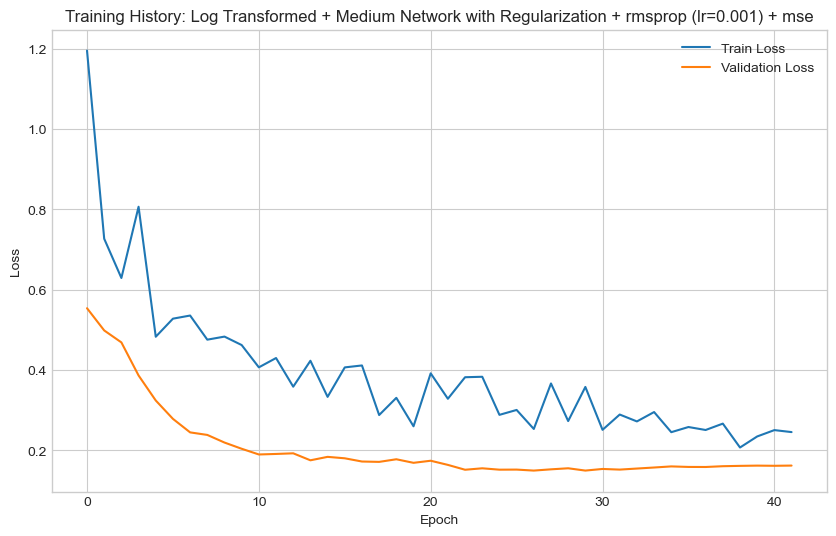



Training: Log Transformed + Medium Network with Regularization + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.9949 - root_mean_squared_error: 1.6495
Epoch 1: New best val_loss = 0.339720
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.7682 - root_mean_squared_error: 1.4080 - val_loss: 0.3397 - val_root_mean_squared_error: 0.8209 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6741 - root_mean_squared_error: 1.3897
Epoch 2: New best val_loss = 0.280587
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6346 - root_mean_squared_error: 1.3066 - val_loss: 0.2806 - val_root_mean_squared_error: 0.7272 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.5710 - root_mean_squared_error: 1.1211
Epoch 3: New best val_loss = 0.229938
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4930 - root_mean_squared_error: 1.0485 - val_loss: 0.2299 - val_root_mean_squared_error: 0.6477 - learning_rate: 0.0

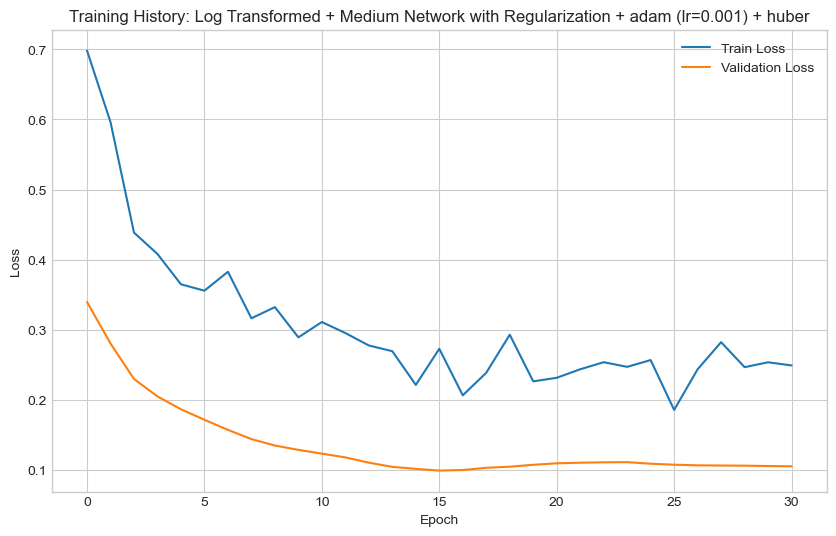



Training: Log Transformed + Deep Network + adam (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - loss: 1.5796 - root_mean_squared_error: 1.2327
Epoch 1: New best val_loss = 0.561523
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 1.3982 - root_mean_squared_error: 1.1562 - val_loss: 0.5615 - val_root_mean_squared_error: 0.7082 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.2117 - root_mean_squared_error: 1.0732
Epoch 2: New best val_loss = 0.363117
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.2151 - root_mean_squared_error: 1.0745 - val_loss: 0.3631 - val_root_mean_squared_error: 0.5505 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.2711 - root_mean_squared_error: 1.1005
Epoch 3: New best val_loss = 0.281213
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9390 - root_mean_squared_error: 0.9344 - val_loss: 0.2812 - val_root_mean_squared_error: 0.4702 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━

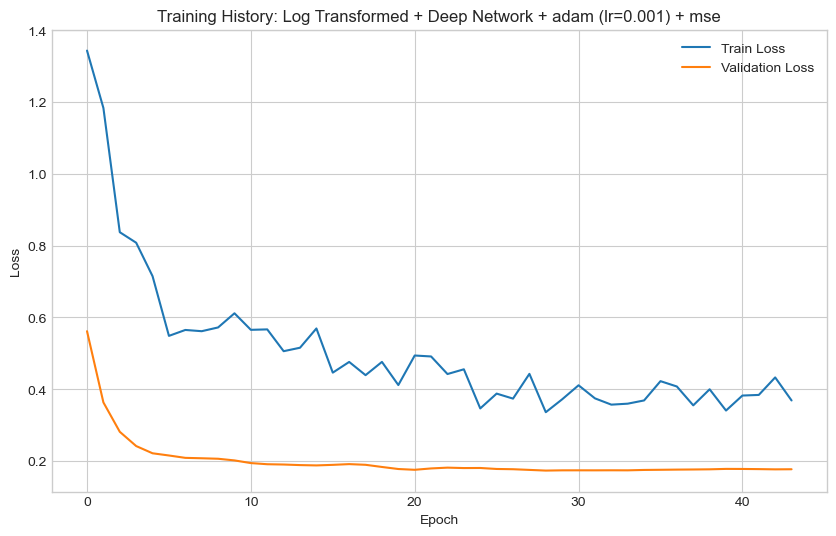



Training: Log Transformed + Deep Network + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - loss: 1.7870 - root_mean_squared_error: 1.3141
Epoch 1: New best val_loss = 0.529979
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - loss: 1.7762 - root_mean_squared_error: 1.3100 - val_loss: 0.5300 - val_root_mean_squared_error: 0.6855 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.6891 - root_mean_squared_error: 1.2763
Epoch 2: New best val_loss = 0.445543
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.5105 - root_mean_squared_error: 1.2036 - val_loss: 0.4455 - val_root_mean_squared_error: 0.6208 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.1447 - root_mean_squared_error: 1.0414
Epoch 3: New best val_loss = 0.381917
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.2367 - root_mean_squared_error: 1.0844 - val_loss: 0.3819 - val_root_mean_squared_error: 0.5673 - learning_rate: 5.0000e-04
Epoch 

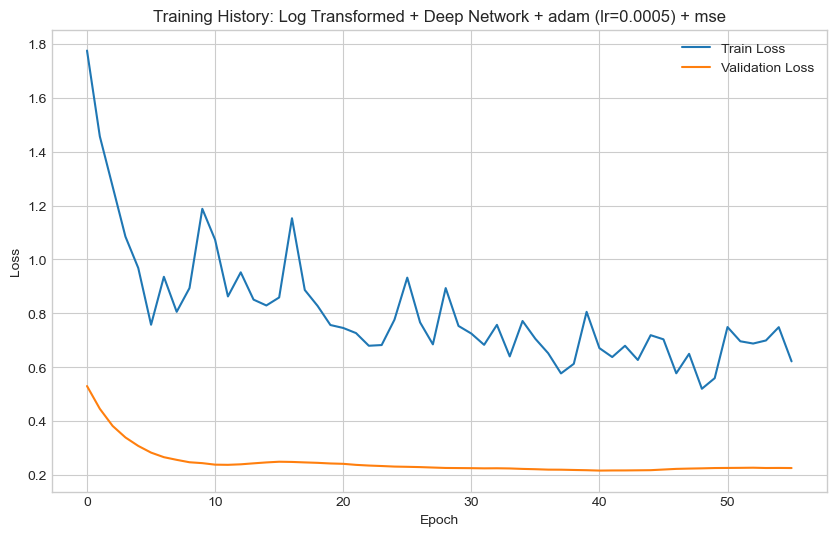



Training: Log Transformed + Deep Network + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 2.6377 - root_mean_squared_error: 1.6056
Epoch 1: New best val_loss = 0.326295
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 1.8632 - root_mean_squared_error: 1.3358 - val_loss: 0.3263 - val_root_mean_squared_error: 0.5161 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.3689 - root_mean_squared_error: 1.1441
Epoch 2: New best val_loss = 0.298162
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.1206 - root_mean_squared_error: 1.0283 - val_loss: 0.2982 - val_root_mean_squared_error: 0.4880 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8668 - root_mean_squared_error: 0.8982
Epoch 3: New best val_loss = 0.292847
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7822 - root_mean_squared_error: 0.8494 - val_loss: 0.2928 - val_root_mean_squared_error: 0.4825 - learning_rate: 0.0010
Epoch 4/500
1/5 ━

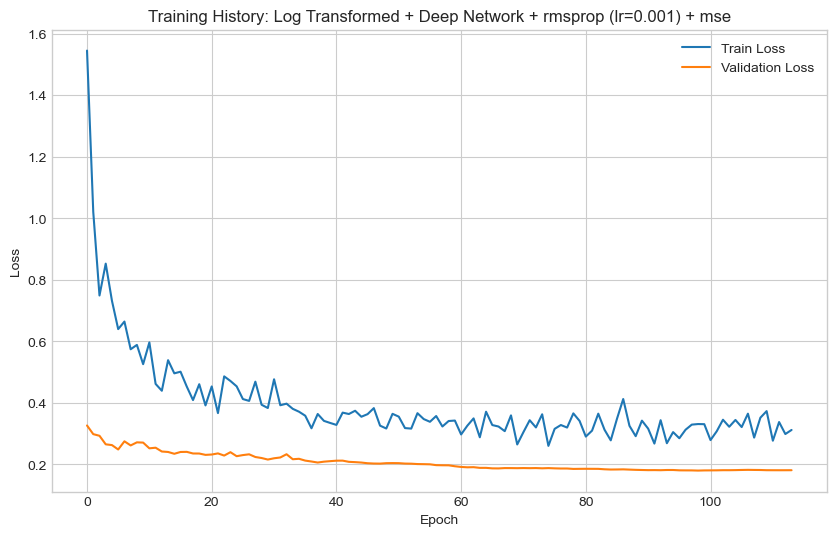



Training: Log Transformed + Deep Network + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 0.7134 - root_mean_squared_error: 1.6134
Epoch 1: New best val_loss = 0.162279
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.8239 - root_mean_squared_error: 1.6863 - val_loss: 0.1623 - val_root_mean_squared_error: 0.4551 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.7081 - root_mean_squared_error: 1.3479
Epoch 2: New best val_loss = 0.141840
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7100 - root_mean_squared_error: 1.3197 - val_loss: 0.1418 - val_root_mean_squared_error: 0.4050 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6139 - root_mean_squared_error: 1.2074 - val_loss: 0.1496 - val_root_mean_squared_error: 0.4237 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5546 - root_mean_squared_error: 1.1476 - val_loss: 0.1655 - val_root_mean_squared_

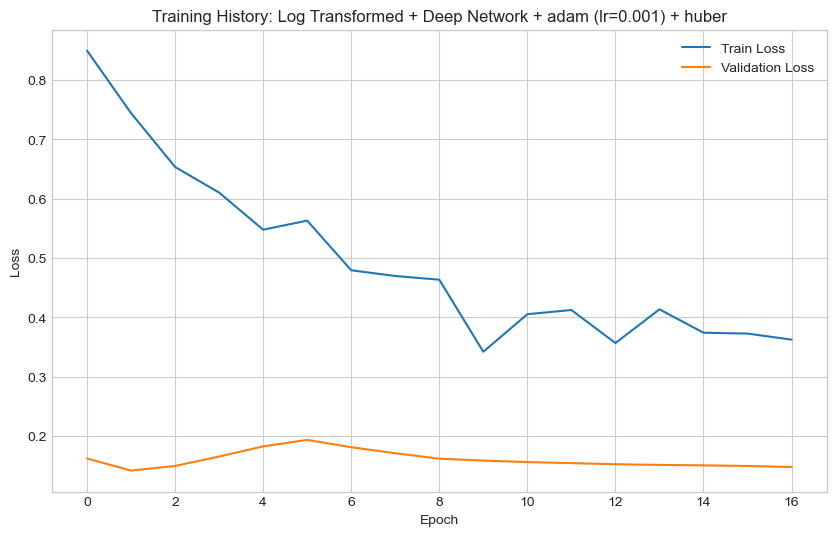



Training: Log Transformed + Wide Network + adam (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 1.9014 - root_mean_squared_error: 1.3310
Epoch 1: New best val_loss = 0.370861
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 1.6128 - root_mean_squared_error: 1.2159 - val_loss: 0.3709 - val_root_mean_squared_error: 0.4908 - learning_rate: 0.0010
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.4479 - root_mean_squared_error: 1.1479 - val_loss: 0.3787 - val_root_mean_squared_error: 0.4985 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.2995 - root_mean_squared_error: 1.0792 - val_loss: 0.3958 - val_root_mean_squared_error: 0.5152 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.2781 - root_mean_squared_error: 1.0714
Epoch 4: New best val_loss = 0.369811
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0183 - root_mean_squared_error: 0.9401 - val_loss: 0.3698 - val_root_mean_squared_err

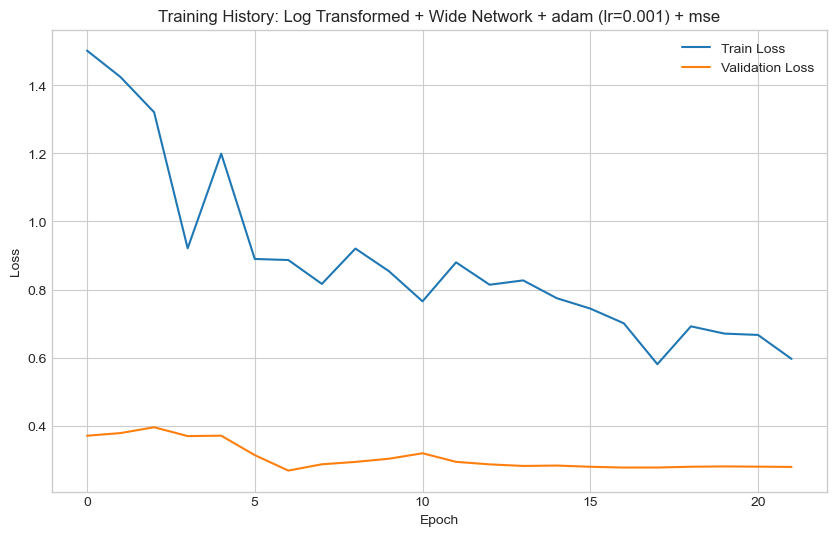



Training: Log Transformed + Wide Network + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 3.1486 - root_mean_squared_error: 1.7375
Epoch 1: New best val_loss = 0.677549
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - loss: 2.7008 - root_mean_squared_error: 1.6015 - val_loss: 0.6775 - val_root_mean_squared_error: 0.7400 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - loss: 1.8541 - root_mean_squared_error: 1.3131
Epoch 2: New best val_loss = 0.497398
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.5484 - root_mean_squared_error: 1.1888 - val_loss: 0.4974 - val_root_mean_squared_error: 0.6062 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.9178 - root_mean_squared_error: 1.3371
Epoch 3: New best val_loss = 0.418555
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.4874 - root_mean_squared_error: 1.1606 - val_loss: 0.4186 - val_root_mean_squared_error: 0.5372 - learning_rate: 5.0000e-04
Epoch

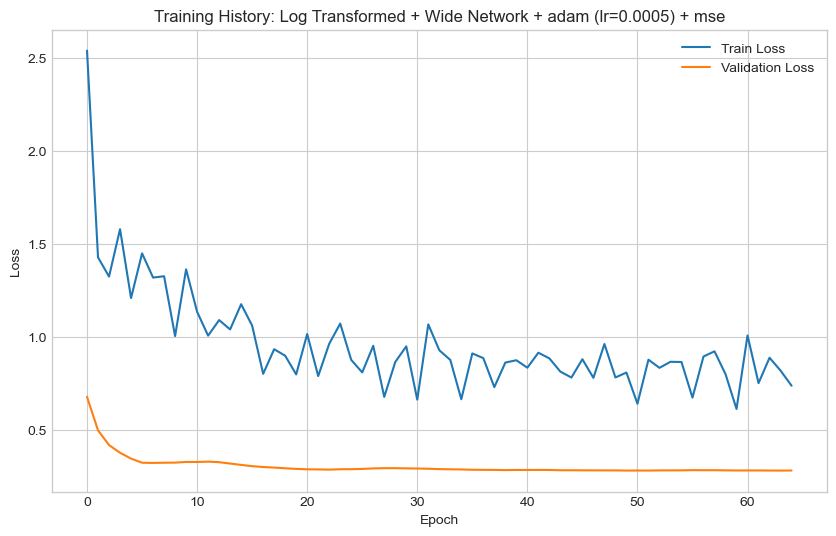



Training: Log Transformed + Wide Network + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 3.5400 - root_mean_squared_error: 1.8467
Epoch 1: New best val_loss = 0.512034
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 2.0975 - root_mean_squared_error: 1.3857 - val_loss: 0.5120 - val_root_mean_squared_error: 0.6179 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.3147 - root_mean_squared_error: 1.0883
Epoch 2: New best val_loss = 0.375163
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.2061 - root_mean_squared_error: 1.0368 - val_loss: 0.3752 - val_root_mean_squared_error: 0.4947 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4923 - root_mean_squared_error: 0.6015
Epoch 3: New best val_loss = 0.353576
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7361 - root_mean_squared_error: 0.7742 - val_loss: 0.3536 - val_root_mean_squared_error: 0.4723 - learning_rate: 0.0010
Epoch 4/500
5/5 ━

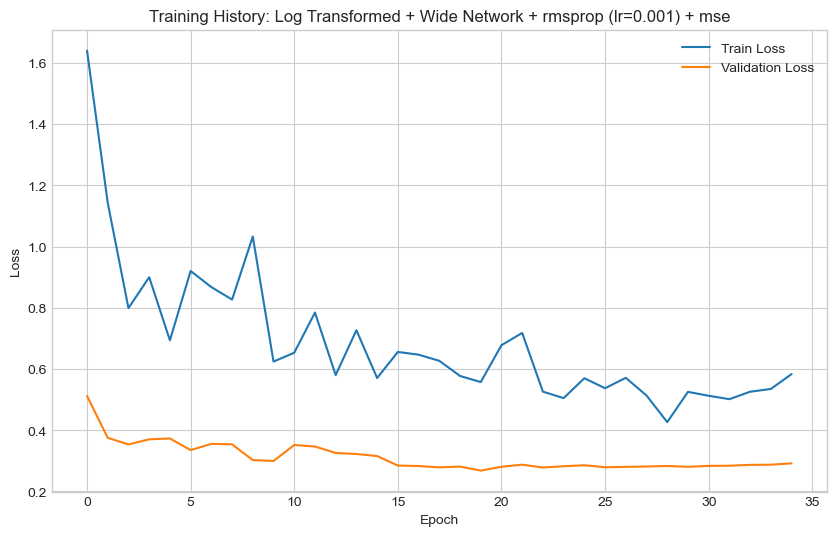



Training: Log Transformed + Wide Network + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.8080 - root_mean_squared_error: 1.3785
Epoch 1: New best val_loss = 0.215043
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.6995 - root_mean_squared_error: 1.2430 - val_loss: 0.2150 - val_root_mean_squared_error: 0.4131 - learning_rate: 0.0010
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6465 - root_mean_squared_error: 1.1396 - val_loss: 0.2194 - val_root_mean_squared_error: 0.4233 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5747 - root_mean_squared_error: 1.1123 - val_loss: 0.2423 - val_root_mean_squared_error: 0.4741 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4719 - root_mean_squared_error: 0.9053 - val_loss: 0.2730 - val_root_mean_squared_error: 0.5391 - learning_rate: 0.0010
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4586 - root_mean_squared_err

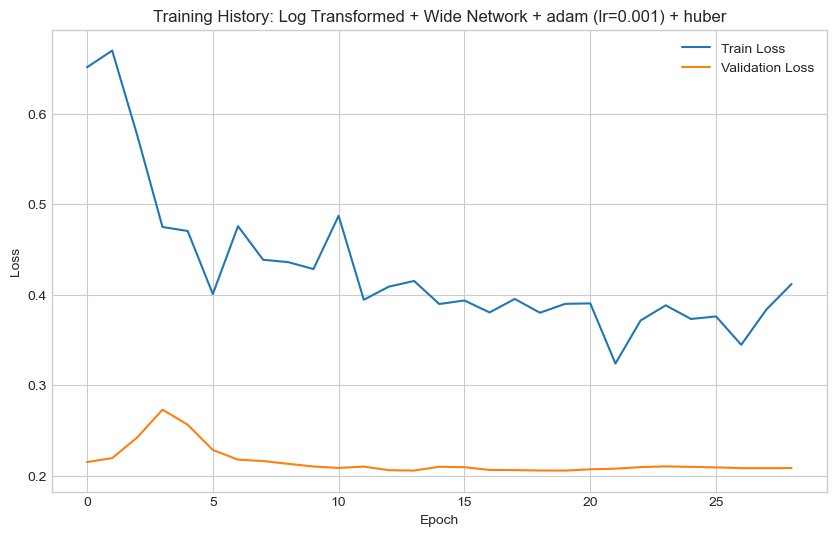



Training: Log Transformed + PReLU Network + adam (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - loss: 2.5137 - root_mean_squared_error: 1.5686
Epoch 1: New best val_loss = 0.467842
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 1.7118 - root_mean_squared_error: 1.2808 - val_loss: 0.4678 - val_root_mean_squared_error: 0.6439 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.1917 - root_mean_squared_error: 1.0670
Epoch 2: New best val_loss = 0.363280
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.1269 - root_mean_squared_error: 1.0361 - val_loss: 0.3633 - val_root_mean_squared_error: 0.5568 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9603 - root_mean_squared_error: 0.9524
Epoch 3: New best val_loss = 0.298420
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8653 - root_mean_squared_error: 0.9007 - val_loss: 0.2984 - val_root_mean_squared_error: 0.4951 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━

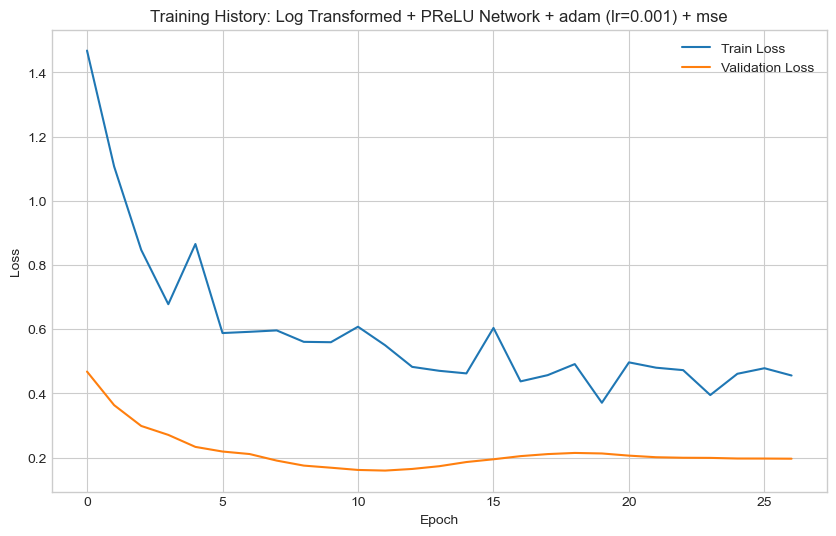



Training: Log Transformed + PReLU Network + adam (lr=0.0005) + mse
Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - loss: 2.7244 - root_mean_squared_error: 1.6343
Epoch 1: New best val_loss = 1.683902
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - loss: 2.4419 - root_mean_squared_error: 1.5446 - val_loss: 1.6839 - val_root_mean_squared_error: 1.2768 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.7823 - root_mean_squared_error: 1.6519
Epoch 2: New best val_loss = 1.287780
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.3838 - root_mean_squared_error: 1.5247 - val_loss: 1.2878 - val_root_mean_squared_error: 1.1109 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.5312 - root_mean_squared_error: 1.5740
Epoch 3: New best val_loss = 1.009790
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.9963 - root_mean_squared_error: 1.3897 - val_loss: 1.0098 - val_root_mean_squared_error: 0.9778 - learning_rate: 5.0000e-04
Epoch

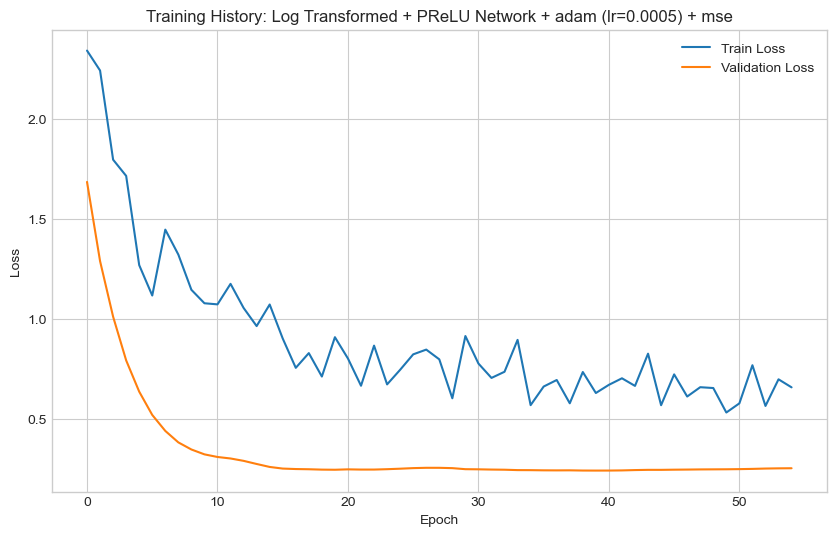



Training: Log Transformed + PReLU Network + rmsprop (lr=0.001) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 1.4771 - root_mean_squared_error: 1.1932
Epoch 1: New best val_loss = 0.422008
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 1.4380 - root_mean_squared_error: 1.1767 - val_loss: 0.4220 - val_root_mean_squared_error: 0.6071 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.7480 - root_mean_squared_error: 0.8334
Epoch 2: New best val_loss = 0.401153
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7912 - root_mean_squared_error: 0.8586 - val_loss: 0.4012 - val_root_mean_squared_error: 0.5897 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5494 - root_mean_squared_error: 0.7043
Epoch 3: New best val_loss = 0.327486
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8311 - root_mean_squared_error: 0.8782 - val_loss: 0.3275 - val_root_mean_squared_error: 0.5235 - learning_rate: 0.0010
Epoch 4/500
1/5 

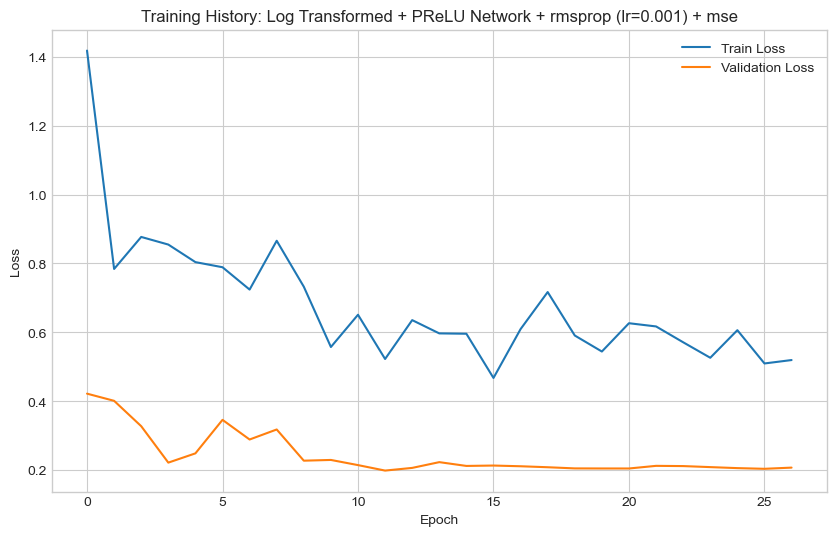



Training: Log Transformed + PReLU Network + adam (lr=0.001) + huber
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 0.8871 - root_mean_squared_error: 1.4908
Epoch 1: New best val_loss = 0.267019
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.7757 - root_mean_squared_error: 1.4181 - val_loss: 0.2670 - val_root_mean_squared_error: 0.6571 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5769 - root_mean_squared_error: 1.1749
Epoch 2: New best val_loss = 0.176540
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5015 - root_mean_squared_error: 1.0611 - val_loss: 0.1765 - val_root_mean_squared_error: 0.4965 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2902 - root_mean_squared_error: 0.7145
Epoch 3: New best val_loss = 0.170297
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3326 - root_mean_squared_error: 0.7976 - val_loss: 0.1703 - val_root_mean_squared_error: 0.4838 - learning_rate: 0.0010
Epoch 4/500
5/5 

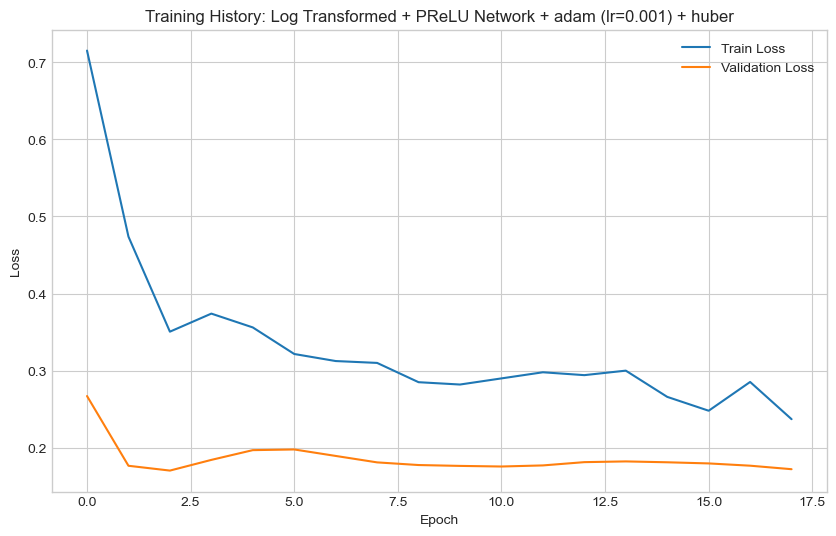

In [29]:
# Store results
search_results = []

# Systematic search through combinations
for target in target_options:
    for arch in architecture_search_space:
        for params in training_params:
            # Create a unique name for this configuration
            config_name = f"{target['name']} + {arch['name']} + {params['optimizer']} (lr={params['learning_rate']}) + {params['loss']}"
            print(f"\n\nTraining: {config_name}")
            
            # Create model
            model = create_model_architecture(X_train_main.shape[1], arch)
            
            # Train model
            trained_model, history, training_time = train_model(
                target['X_train'], target['y_train'],
                target['X_val'], target['y_val'],
                model=model,
                batch_size=params['batch_size'],
                optimizer=params['optimizer'],
                learning_rate=params['learning_rate'],
                loss=params['loss'],
                patience=15
            )
            
            # Evaluate on test set
            y_pred = trained_model.predict(target['X_test'])
            
            # Convert to original scale
            y_pred_original = target['inverse_func'](y_pred)
            y_test_original = target['inverse_func'](target['y_test'])
            
            # Calculate metrics
            rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
            mae = mean_absolute_error(y_test_original, y_pred_original)
            r2 = r2_score(y_test_original, y_pred_original)
            
            print(f"Results for {config_name}:")
            print(f"RMSE: {rmse:.2f}")
            print(f"MAE: {mae:.2f}")
            print(f"R² Score: {r2:.4f}")
            print(f"Training time: {training_time:.2f} seconds")
            
            # Plot learning curves
            plt.figure(figsize=(10, 6))
            plt.plot(history.history['loss'], label='Train Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.title(f'Training History: {config_name}')
            plt.ylabel('Loss')
            plt.xlabel('Epoch')
            plt.legend()
            plt.show()
            
            # Store results
            search_results.append({
                'name': config_name,
                'architecture': arch['name'],
                'target_transformation': target['name'],
                'optimizer': params['optimizer'],
                'learning_rate': params['learning_rate'],
                'loss': params['loss'],
                'batch_size': params['batch_size'],
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'training_time': training_time,
                'model': trained_model,
                'history': history,
                'y_pred': y_pred_original,
                'y_test': y_test_original
            })

## 8. Analyze Architecture Search Results

,Config,Architecture,Target,Optimizer,Learning Rate,Loss,RMSE,MAE,R²,Time (s)
8,Standard Scaled + Deep Network + adam (lr=0.00...,Deep Network,Standard Scaled,adam,0.0010,mse,3503.230186,2003.938251,0.850273,8.126766
21,Log Transformed + Small Network + adam (lr=0.0...,Small Network,Log Transformed,adam,0.0005,mse,3719.283096,2030.214568,0.831235,16.105181
18,Standard Scaled + PReLU Network + rmsprop (lr=...,PReLU Network,Standard Scaled,rmsprop,0.0010,mse,3750.800420,2432.510892,0.828363,9.842062
6,Standard Scaled + Medium Network with Regulari...,Medium Network with Regularization,Standard Scaled,rmsprop,0.0010,mse,3838.231419,2112.168507,0.820268,8.093641
22,Log Transformed + Small Network + rmsprop (lr=...,Small Network,Log Transformed,rmsprop,0.0010,mse,3915.467898,2477.468850,0.812962,3.682747
14,Standard Scaled + Wide Network + rmsprop (lr=0...,Wide Network,Standard Scaled,rmsprop,0.0010,mse,3915.684078,2044.388547,0.812941,6.995361
19,Standard Scaled + PReLU Network + adam (lr=0.0...,PReLU Network,Standard Scaled,adam,0.0010,huber,3921.082754,2302.641026,0.812425,6.794236
13,Standard Scaled + Wide Network + adam (lr=0.00...,Wide Network,Standard Scaled,adam,0.0005,mse,3954.516535,2484.574907,0.809213,8.845395
15,Standard Scaled + Wide Network + adam (lr=0.00...,Wide Network,Standard Scaled,adam,0.0010,huber,3955.836002,2260.680226,0.809085,5.365462
26,Log Transformed + Medium Network with Regulari...,Medium Network with Regularization,Log Transformed,rmsprop,0.0010,mse,3995.969846,2190.429462,0.805192,7.006717



Best Model: Standard Scaled + Deep Network + adam (lr=0.001) + mse
RMSE: 3503.23
MAE: 2003.94
R² Score: 0.8503


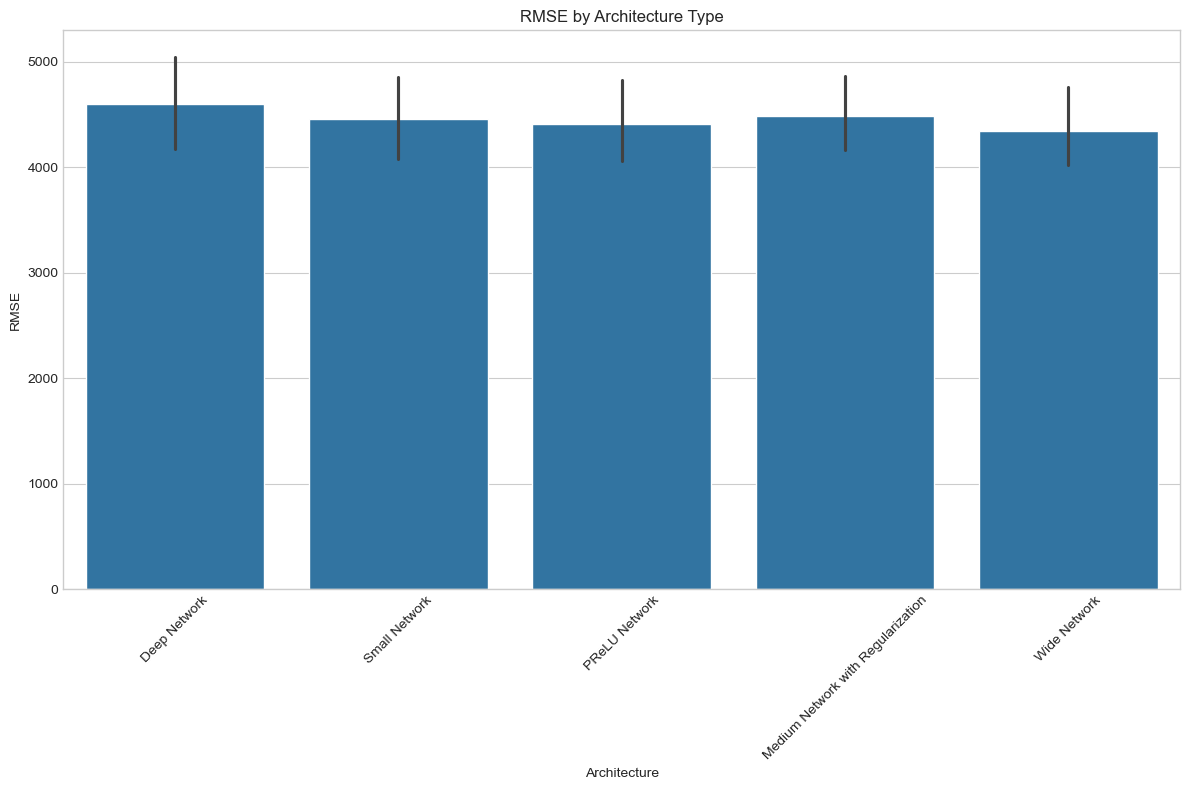

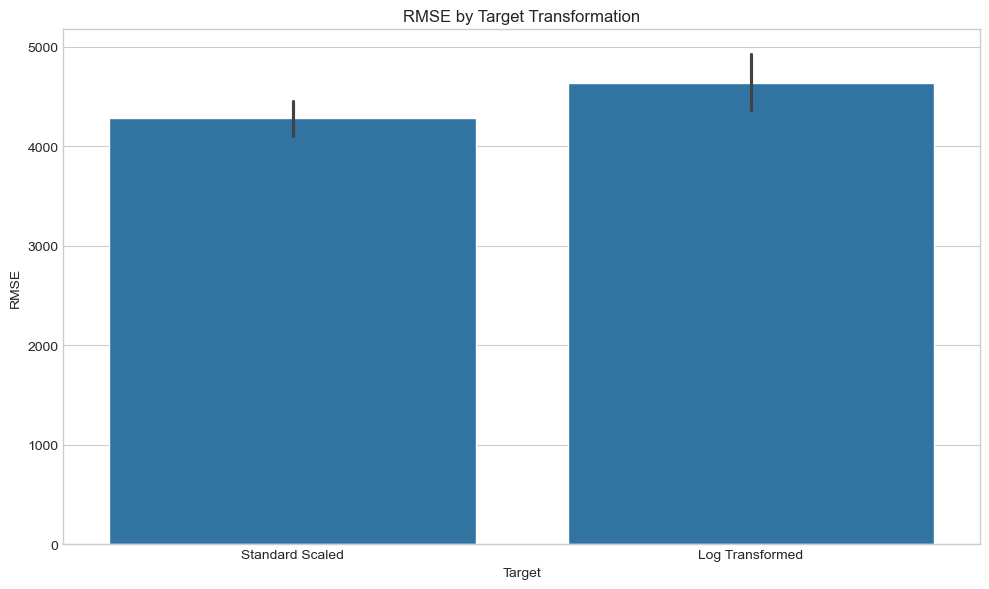

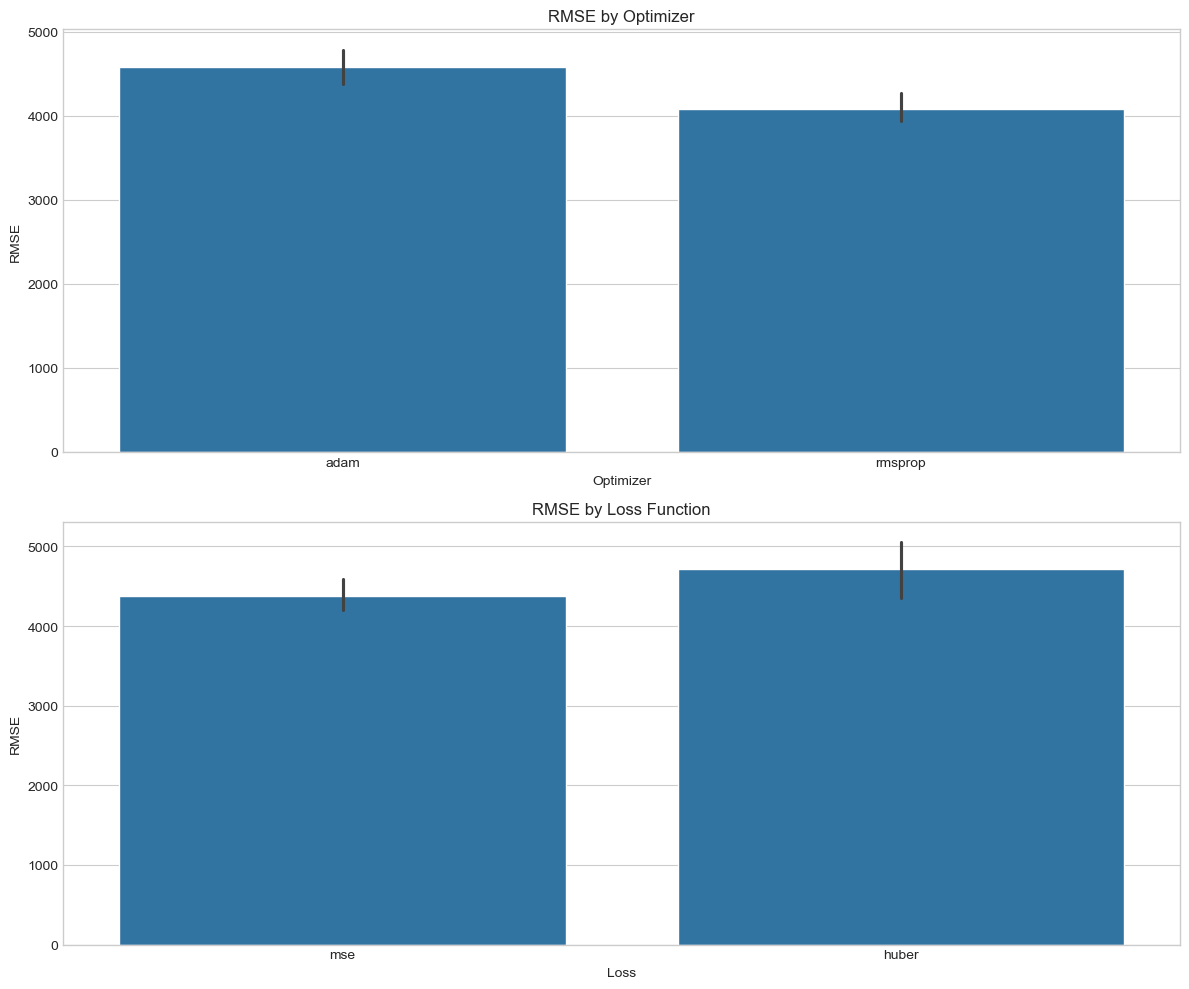

In [30]:
# Create a DataFrame with the results
results_df = pd.DataFrame([
    {'Config': r['name'], 'Architecture': r['architecture'], 'Target': r['target_transformation'],
     'Optimizer': r['optimizer'], 'Learning Rate': r['learning_rate'], 'Loss': r['loss'],
     'RMSE': r['rmse'], 'MAE': r['mae'], 'R²': r['r2'], 'Time (s)': r['training_time']}
    for r in search_results
])

# Sort by RMSE (primary metric)
results_df_sorted = results_df.sort_values('RMSE')
display(results_df_sorted)

# Find best model
best_model_config = search_results[results_df_sorted.index[0]]
print(f"\nBest Model: {best_model_config['name']}")
print(f"RMSE: {best_model_config['rmse']:.2f}")
print(f"MAE: {best_model_config['mae']:.2f}")
print(f"R² Score: {best_model_config['r2']:.4f}")

# Plot comparisons of different architectures
plt.figure(figsize=(12, 8))
sns.barplot(x='Architecture', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Architecture Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot comparisons of target transformations
plt.figure(figsize=(10, 6))
sns.barplot(x='Target', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Target Transformation')
plt.tight_layout()
plt.show()

# Plot comparisons of optimizers and loss functions
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
sns.barplot(x='Optimizer', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Optimizer')

plt.subplot(2, 1, 2)
sns.barplot(x='Loss', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Loss Function')
plt.tight_layout()
plt.show()

## 9. Fine-tuning the Best Model

In [31]:
# Extract information about the best model configuration
best_architecture = next(a for a in architecture_search_space if a['name'] == best_model_config['architecture'])
best_target = next(t for t in target_options if t['name'] == best_model_config['target_transformation'])

# Fine-tune by making small adjustments to the best architecture
fine_tuned_architectures = [
    # Slight variations of the best architecture
    {
        'name': f"Fine-Tuned {best_architecture['name']} v1",
        'layer_sizes': best_architecture['layer_sizes'].copy(),  # Add 20% more neurons
        'dropout_rates': [rate * 0.9 for rate in best_architecture['dropout_rates']],  # Slightly less dropout
        'activation': best_architecture['activation'],
        'use_batch_norm': best_architecture['use_batch_norm'],
        'use_regularization': best_architecture['use_regularization']
    },
    {
        'name': f"Fine-Tuned {best_architecture['name']} v2",
        'layer_sizes': best_architecture['layer_sizes'] + [16],  # Add one more layer
        'dropout_rates': best_architecture['dropout_rates'] + [0.1],  # Add dropout for the new layer
        'activation': best_architecture['activation'],
        'use_batch_norm': best_architecture['use_batch_norm'],
        'use_regularization': best_architecture['use_regularization']
    },
    {
        'name': f"Fine-Tuned {best_architecture['name']} v3",
        'layer_sizes': best_architecture['layer_sizes'],
        'dropout_rates': best_architecture['dropout_rates'],
        'activation': 'prelu' if best_architecture['activation'] != 'prelu' else 'leaky_relu',  # Try different activation
        'use_batch_norm': best_architecture['use_batch_norm'],
        'use_regularization': best_architecture['use_regularization']
    }
]

# Fine-tune training parameters
fine_tuned_params = [
    {
        'optimizer': best_model_config['optimizer'],
        'learning_rate': best_model_config['learning_rate'] * 0.5,  # Lower learning rate
        'batch_size': best_model_config['batch_size'],
        'loss': best_model_config['loss']
    },
    {
        'optimizer': best_model_config['optimizer'],
        'learning_rate': best_model_config['learning_rate'],
        'batch_size': best_model_config['batch_size'] * 2,  # Larger batch size
        'loss': best_model_config['loss']
    },
    {
        'optimizer': best_model_config['optimizer'],
        'learning_rate': best_model_config['learning_rate'],
        'batch_size': best_model_config['batch_size'],
        'loss': 'huber' if best_model_config['loss'] != 'huber' else 'mse'  # Try different loss
    }
]

# Run fine-tuning
fine_tuning_results = []

# Include the original best model for comparison
fine_tuning_results.append(best_model_config)

# Train fine-tuned models
for arch in fine_tuned_architectures:
    for params in fine_tuned_params:
        # Create a unique name for this configuration
        config_name = f"{best_target['name']} + {arch['name']} + {params['optimizer']} (lr={params['learning_rate']}) + {params['loss']}"
        print(f"\n\nFine-Tuning: {config_name}")
        
        # Create model
        model = create_model_architecture(best_target['X_train'].shape[1], arch)
        
        # Train with longer patience for fine-tuning
        trained_model, history, training_time = train_model(
            best_target['X_train'], best_target['y_train'],
            best_target['X_val'], best_target['y_val'],
            model=model,
            batch_size=params['batch_size'],
            optimizer=params['optimizer'],
            learning_rate=params['learning_rate'],
            loss=params['loss'],
            patience=20  # Longer patience for fine-tuning
        )
        
        # Evaluate on test set
        y_pred = trained_model.predict(best_target['X_test'])
        
        # Convert to original scale
        y_pred_original = best_target['inverse_func'](y_pred)
        y_test_original = best_target['inverse_func'](best_target['y_test'])
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
        mae = mean_absolute_error(y_test_original, y_pred_original)
        r2 = r2_score(y_test_original, y_pred_original)
        
        print(f"Results for fine-tuned model:")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAE: {mae:.2f}")
        print(f"R² Score: {r2:.4f}")
        
        # Store results
        fine_tuning_results.append({
            'name': config_name,
            'architecture': arch['name'],
            'target_transformation': best_target['name'],
            'optimizer': params['optimizer'],
            'learning_rate': params['learning_rate'],
            'loss': params['loss'],
            'batch_size': params['batch_size'],
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'training_time': training_time,
            'model': trained_model,
            'history': history,
            'y_pred': y_pred_original,
            'y_test': y_test_original
        })



Fine-Tuning: Standard Scaled + Fine-Tuned Deep Network v1 + adam (lr=0.0005) + mse
Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 3.7674 - root_mean_squared_error: 1.9254
Epoch 1: New best val_loss = 0.816527
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 2.9281 - root_mean_squared_error: 1.6883 - val_loss: 0.8165 - val_root_mean_squared_error: 0.8696 - learning_rate: 5.0000e-04
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.7385 - root_mean_squared_error: 1.6365
Epoch 2: New best val_loss = 0.559153
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.9743 - root_mean_squared_error: 1.3774 - val_loss: 0.5592 - val_root_mean_squared_error: 0.7063 - learning_rate: 5.0000e-04
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.7609 - root_mean_squared_error: 0.8370
Epoch 3: New best val_loss = 0.417141
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2763 - root_mean_squared_error: 1.0961 - val_loss: 0.4171 - val_root_mean_squared_error: 0.5973 - learning_rate: 

## 10. Analyze Fine-Tuning Results

In [32]:
# Create a DataFrame with the fine-tuning results
fine_tuning_df = pd.DataFrame([
    {'Config': r['name'], 'Architecture': r['architecture'],
     'Optimizer': r['optimizer'], 'Learning Rate': r['learning_rate'], 'Loss': r['loss'],
     'RMSE': r['rmse'], 'MAE': r['mae'], 'R²': r['r2'], 'Time (s)': r['training_time']}
    for r in fine_tuning_results
])

# Sort by RMSE
fine_tuning_df_sorted = fine_tuning_df.sort_values('RMSE')
display(fine_tuning_df_sorted)

# Find the best fine-tuned model
best_fine_tuned = fine_tuning_results[fine_tuning_df_sorted.index[0]]
print(f"\nBest Fine-Tuned Model: {best_fine_tuned['name']}")
print(f"RMSE: {best_fine_tuned['rmse']:.2f}")
print(f"MAE: {best_fine_tuned['mae']:.2f}")
print(f"R² Score: {best_fine_tuned['r2']:.4f}")

# Show improvement over initial best model
improvement_rmse = ((best_model_config['rmse'] - best_fine_tuned['rmse']) / best_model_config['rmse']) * 100
improvement_r2 = ((best_fine_tuned['r2'] - best_model_config['r2']) / best_model_config['r2']) * 100

print(f"\nImprovement over initial best model:")
print(f"RMSE improvement: {improvement_rmse:.2f}%")
print(f"R² improvement: {improvement_r2:.2f}%")

,Config,Architecture,Optimizer,Learning Rate,Loss,RMSE,MAE,R²,Time (s)
3,Standard Scaled + Fine-Tuned Deep Network v1 +...,Fine-Tuned Deep Network v1,adam,0.0010,huber,2940.198257,1575.875701,0.894533,9.684577
7,Standard Scaled + Fine-Tuned Deep Network v3 +...,Fine-Tuned Deep Network v3,adam,0.0005,mse,3273.850876,1993.989508,0.869238,12.655659
9,Standard Scaled + Fine-Tuned Deep Network v3 +...,Fine-Tuned Deep Network v3,adam,0.0010,huber,3398.002251,1989.001027,0.859133,9.159057
0,Standard Scaled + Deep Network + adam (lr=0.00...,Deep Network,adam,0.0010,mse,3503.230186,2003.938251,0.850273,8.126766
5,Standard Scaled + Fine-Tuned Deep Network v2 +...,Fine-Tuned Deep Network v2,adam,0.0010,mse,3647.877024,2205.788524,0.837653,13.765101
6,Standard Scaled + Fine-Tuned Deep Network v2 +...,Fine-Tuned Deep Network v2,adam,0.0010,huber,3720.972038,2109.335437,0.831082,14.803751
2,Standard Scaled + Fine-Tuned Deep Network v1 +...,Fine-Tuned Deep Network v1,adam,0.0010,mse,4158.213374,2551.350173,0.789051,8.028078
8,Standard Scaled + Fine-Tuned Deep Network v3 +...,Fine-Tuned Deep Network v3,adam,0.0010,mse,4201.280309,2189.292030,0.784659,12.072258
1,Standard Scaled + Fine-Tuned Deep Network v1 +...,Fine-Tuned Deep Network v1,adam,0.0005,mse,4208.601797,2200.323381,0.783908,8.559455
4,Standard Scaled + Fine-Tuned Deep Network v2 +...,Fine-Tuned Deep Network v2,adam,0.0005,mse,4627.323960,2544.052872,0.738770,9.997323



Best Fine-Tuned Model: Standard Scaled + Fine-Tuned Deep Network v1 + adam (lr=0.001) + huber
RMSE: 2940.20
MAE: 1575.88
R² Score: 0.8945

Improvement over initial best model:
RMSE improvement: 16.07%
R² improvement: 5.21%


## 11. Final Model Analysis and Visualization

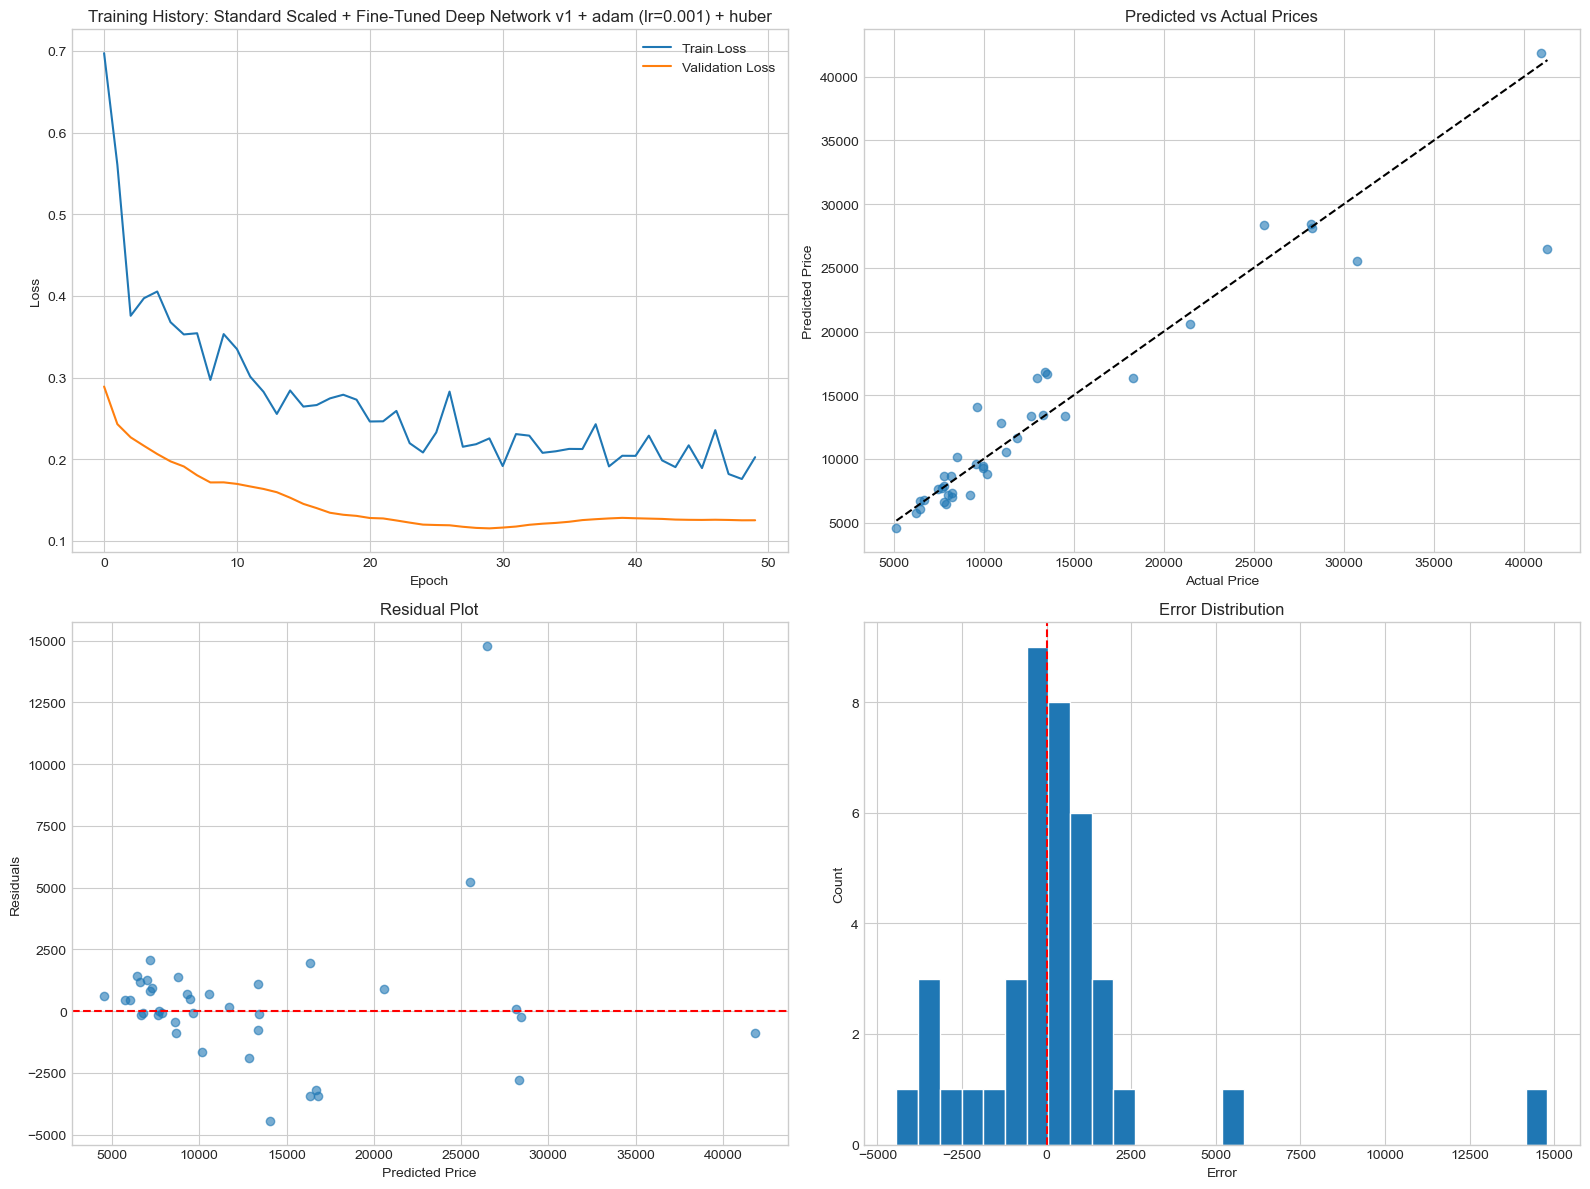

In [33]:
# Select the final best model - either from initial search or fine-tuning
final_model = best_fine_tuned if best_fine_tuned['rmse'] < best_model_config['rmse'] else best_model_config

# Visualize the final model's performance
plt.figure(figsize=(16, 12))

# Plot training & validation loss
plt.subplot(2, 2, 1)
plt.plot(final_model['history'].history['loss'], label='Train Loss')
plt.plot(final_model['history'].history['val_loss'], label='Validation Loss')
plt.title(f'Training History: {final_model["name"]}')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot predictions vs actual
plt.subplot(2, 2, 2)
plt.scatter(final_model['y_test'], final_model['y_pred'], alpha=0.6)
plt.plot([min(final_model['y_test']), max(final_model['y_test'])], 
         [min(final_model['y_test']), max(final_model['y_test'])], 'k--')
plt.title('Predicted vs Actual Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Plot residuals
residuals = final_model['y_test'] - final_model['y_pred']
plt.subplot(2, 2, 3)
plt.scatter(final_model['y_pred'], residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')

# Plot error distribution
plt.subplot(2, 2, 4)
plt.hist(residuals, bins=30)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Error Distribution')
plt.xlabel('Error')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 12. Error Analysis

Worst Predictions (Highest Errors):


,Actual,Predicted,Error,Abs_Error,Squared_Error,Rel_Error_Pct
24,41315.0,26514.894531,14800.105469,14800.105469,2.190431e+08,35.822596
0,30760.0,25509.000000,5251.000000,5251.000000,2.757300e+07,17.070871
25,9639.0,14076.767578,-4437.767578,4437.767578,1.969378e+07,46.039709
28,12940.0,16367.877930,-3427.877930,3427.877930,1.175035e+07,26.490556
26,13415.0,16828.068359,-3413.068359,3413.068359,1.164904e+07,25.442179
20,13499.0,16699.201172,-3200.201172,3200.201172,1.024129e+07,23.706950
29,25552.0,28330.376953,-2778.376953,2778.376953,7.719378e+06,10.873423
6,9258.0,7191.564453,2066.435547,2066.435547,4.270156e+06,22.320539
11,18280.0,16336.529297,1943.470703,1943.470703,3.777078e+06,10.631678
36,10945.0,12842.736328,-1897.736328,1897.736328,3.601403e+06,17.338843



Error Distribution Statistics:
Mean Absolute Error: 1575.88
Median Absolute Error: 887.70
Mean Relative Error: 11.06%
Median Relative Error: 7.70%
90th Percentile Error: 3416.03
95th Percentile Error: 4519.09


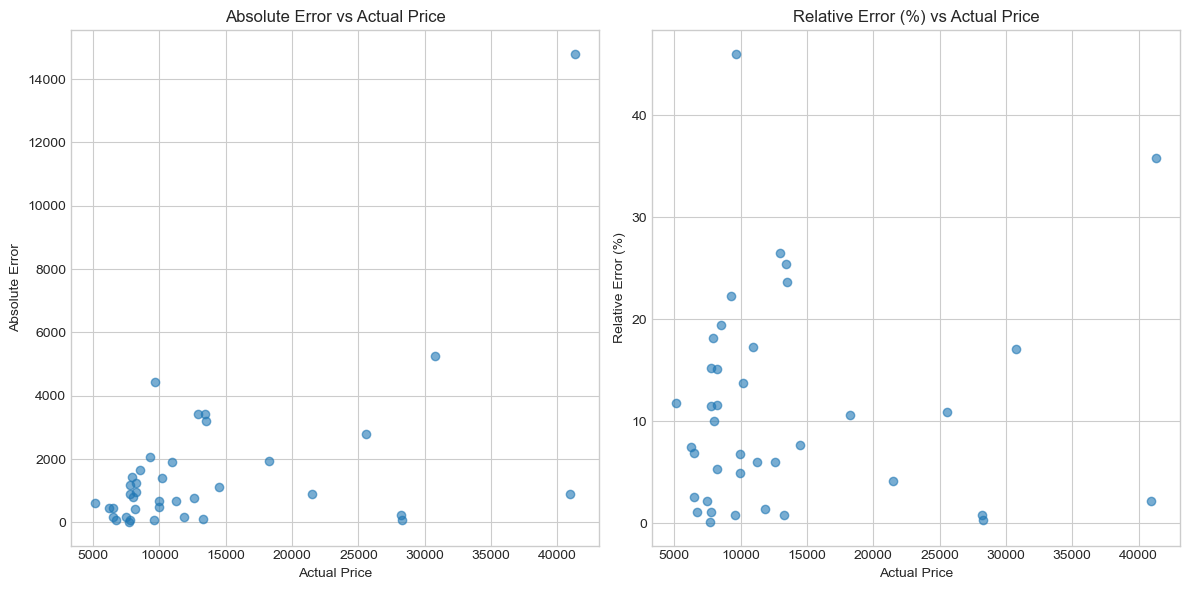

In [34]:
# Create error analysis dataframe
error_df = pd.DataFrame({
    'Actual': final_model['y_test'].flatten(),
    'Predicted': final_model['y_pred'].flatten(),
    'Error': residuals.flatten(),
    'Abs_Error': np.abs(residuals.flatten()),
    'Squared_Error': residuals.flatten() ** 2,
    'Rel_Error_Pct': (np.abs(residuals.flatten()) / final_model['y_test'].flatten()) * 100
})

# Find the worst predictions
print("Worst Predictions (Highest Errors):")
display(error_df.sort_values('Squared_Error', ascending=False).head(10))

# Error statistics
print("\nError Distribution Statistics:")
print(f"Mean Absolute Error: {error_df['Abs_Error'].mean():.2f}")
print(f"Median Absolute Error: {error_df['Abs_Error'].median():.2f}")
print(f"Mean Relative Error: {error_df['Rel_Error_Pct'].mean():.2f}%")
print(f"Median Relative Error: {error_df['Rel_Error_Pct'].median():.2f}%")
print(f"90th Percentile Error: {np.percentile(error_df['Abs_Error'], 90):.2f}")
print(f"95th Percentile Error: {np.percentile(error_df['Abs_Error'], 95):.2f}")

# Check if errors are correlated with price
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(error_df['Actual'], error_df['Abs_Error'], alpha=0.6)
plt.title('Absolute Error vs Actual Price')
plt.xlabel('Actual Price')
plt.ylabel('Absolute Error')

plt.subplot(1, 2, 2)
plt.scatter(error_df['Actual'], error_df['Rel_Error_Pct'], alpha=0.6)
plt.title('Relative Error (%) vs Actual Price')
plt.xlabel('Actual Price')
plt.ylabel('Relative Error (%)')
plt.tight_layout()
plt.show()

# Decision Tree


- Train the model


In [31]:
from sklearn.tree import DecisionTreeRegressor , plot_tree

In [32]:
DecisionTreeModel=DecisionTreeRegressor()
DecisionTreeModel.fit(X_train, y_train)

DecisionTreeRegressor()

plot the decision tree


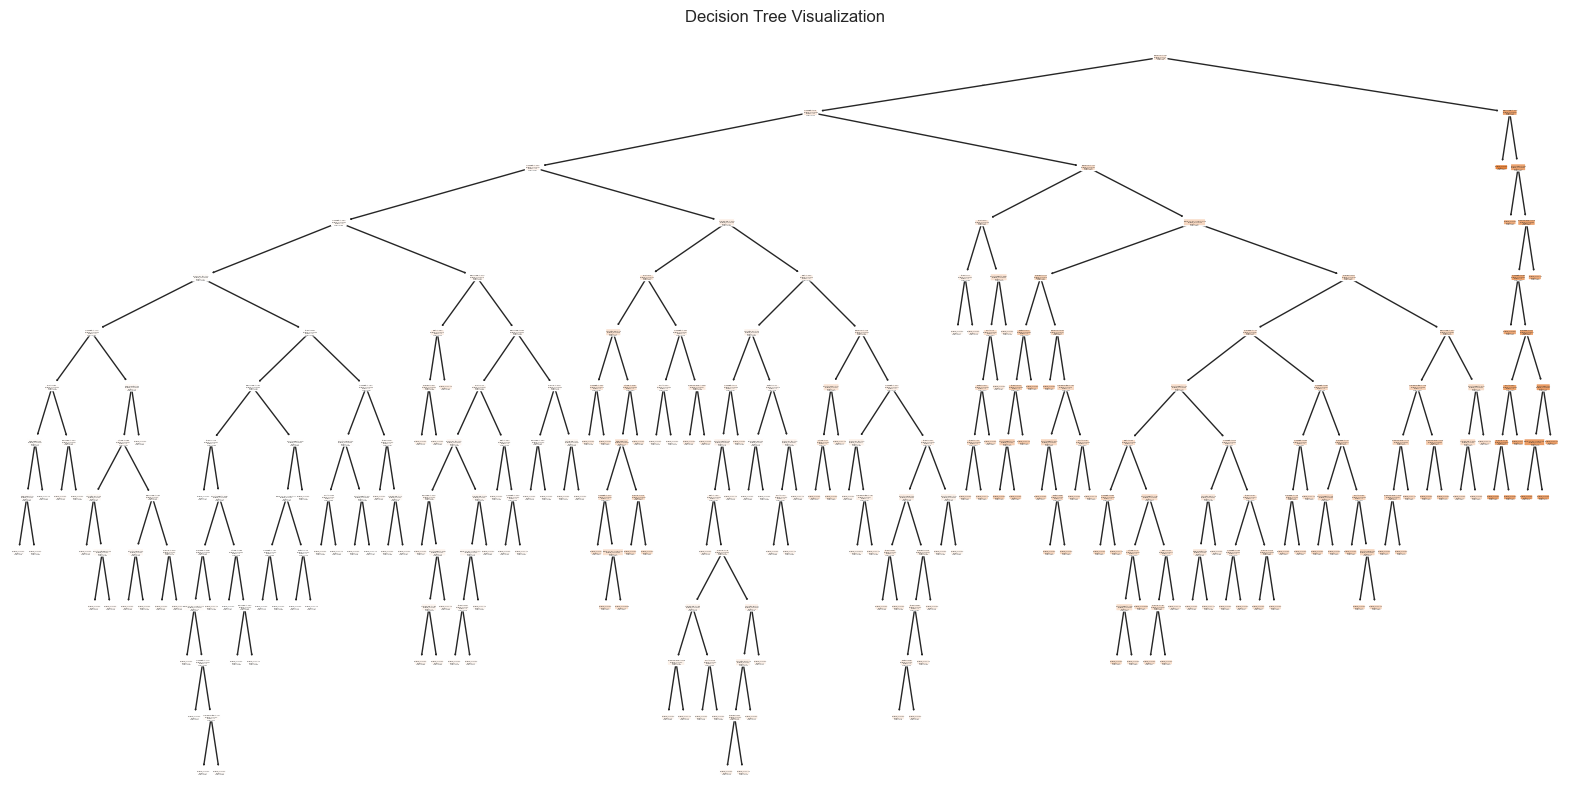

In [33]:
plt.figure(figsize=(20, 10))  # Adjust figure size for readability
plot_tree(DecisionTreeModel, feature_names=list(X_train.columns), filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

In [34]:
y_predicted_dt=DecisionTreeModel.predict(X_test)

In [35]:
regression_report(y_predicted_dt,y_test)

       Regression performance report
   Mean squared error:  0.1 
   Mean absolute error: 0.22 
   Root mean squared error: 0.316 
   R2 score: 0.929


In [36]:
dt_predict1_not_scaled = scaler_y.inverse_transform(y_predicted_dt.reshape(-1, 1)).flatten()

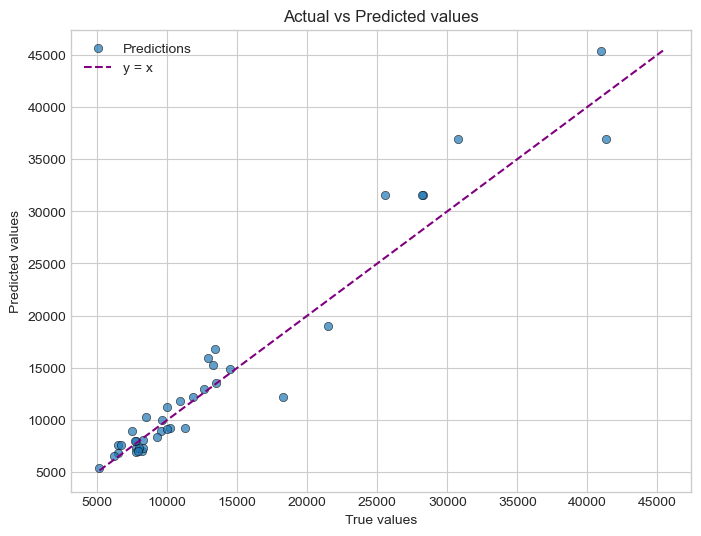

In [37]:
plot_actual_predicted(y_test_original_scale,dt_predict1_not_scaled)

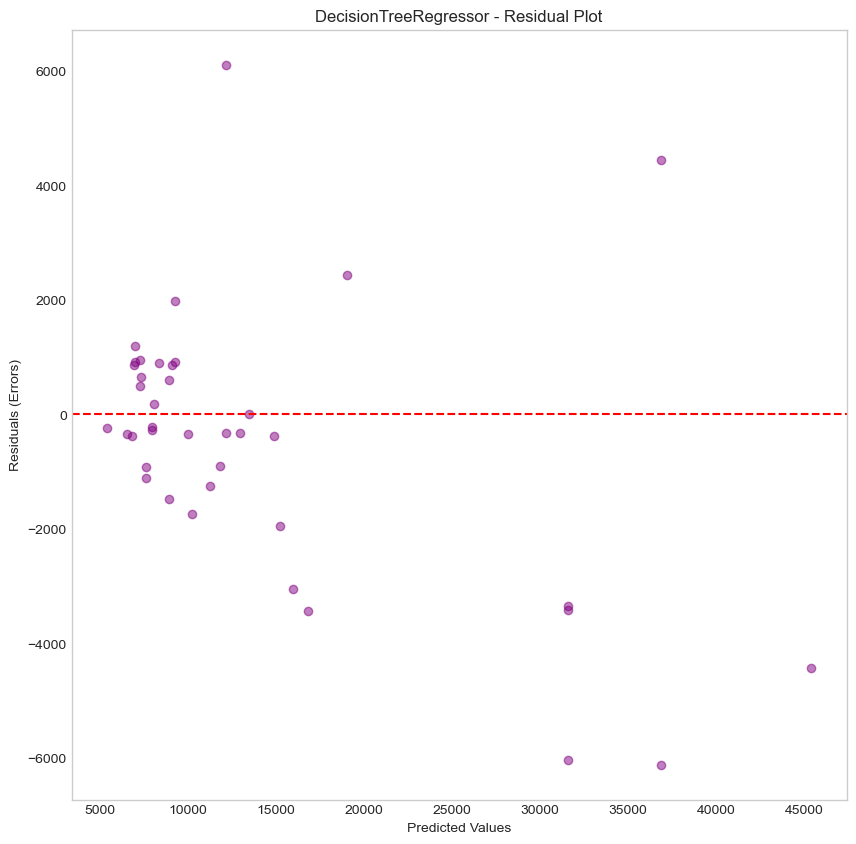

In [38]:
plot_residuals(y_test_original_scale,dt_predict1_not_scaled,"DecisionTreeRegressor")

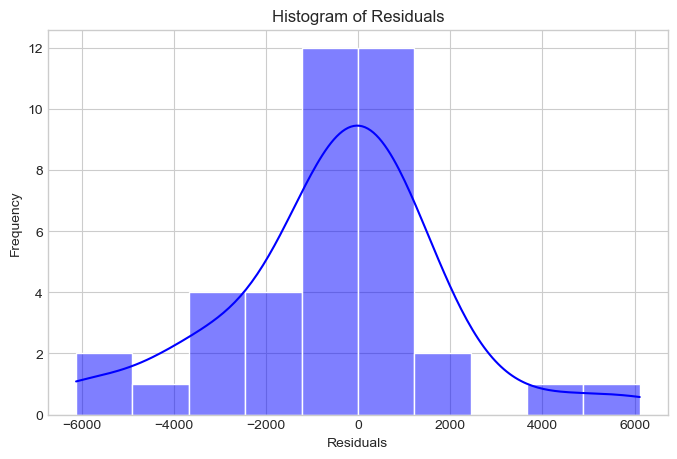

In [39]:

histogram_residuals(y_test_original_scale,dt_predict1_not_scaled)

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │     63.7476      │
├──────────────────────────┼──────────────────┤
│ curb-weight              │     27.5734      │
├──────────────────────────┼──────────────────┤
│ highway-mpg              │      1.65245     │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │      1.19342     │
├──────────────────────────┼──────────────────┤
│ engine_size_per_cylinder │      1.14471     │
├──────────────────────────┼──────────────────┤
│ peak-rpm                 │      0.900149    │
├──────────────────────────┼──────────────────┤
│ bore                     │      0.673574    │
├──────────────────────────┼──────────────────┤
│ height                   │      0.532822    │
├──────────────────────────┼──────────────────┤
│ horsepower               │      0.467061    │
├──────────────────────────┼────────────

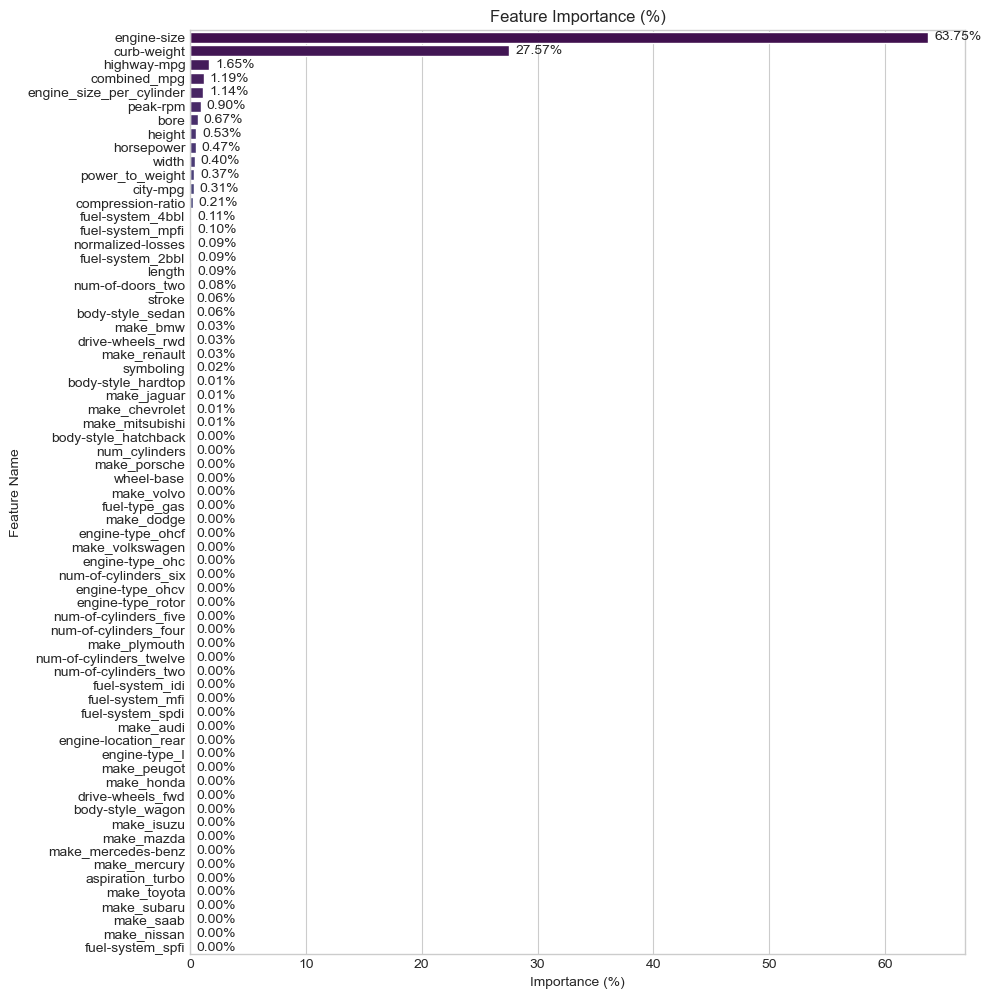

In [51]:
important_feature=plot_feature_importance(DecisionTreeModel,X_train.columns)

In [52]:
print(important_feature)
print(len(important_feature))

['engine-size', 'curb-weight', 'highway-mpg', 'combined_mpg', 'engine_size_per_cylinder', 'peak-rpm', 'bore', 'height', 'horsepower', 'width', 'power_to_weight', 'city-mpg', 'compression-ratio', 'fuel-system_4bbl', 'fuel-system_mpfi', 'normalized-losses', 'fuel-system_2bbl', 'length', 'num-of-doors_two', 'stroke', 'body-style_sedan', 'make_bmw', 'drive-wheels_rwd', 'make_renault', 'symboling', 'body-style_hardtop', 'make_jaguar', 'make_chevrolet', 'make_mitsubishi', 'body-style_hatchback', 'num_cylinders', 'make_porsche', 'wheel-base', 'make_volvo', 'fuel-type_gas', 'make_dodge', 'engine-type_ohcf', 'make_volkswagen', 'engine-type_ohc']
39


- cross validation of untuned decision tree


In [61]:
from sklearn.model_selection import cross_val_score
dt = DecisionTreeRegressor(random_state=42)
cv_scores = cross_val_score(dt, X_train, y_train, cv=10, scoring="neg_mean_squared_error")  #10-fold CV
mse_scores = -cv_scores  
rmse_scores = np.sqrt(mse_scores)  
std_mse = np.std(mse_scores)
print("Cross-Validation MSE Scores:", mse_scores)
print("Mean MSE:", np.mean(mse_scores))
print("MSE Standard Deviation:", std_mse)
print("Mean RMSE:", np.mean(rmse_scores))


Cross-Validation MSE Scores: [0.0761997  0.15111093 0.04207536 0.10764887 0.45755938 0.22786001
 0.16298591 0.11893213 0.17640186 0.23471804]
Mean MSE: 0.17554921966771428
MSE Standard Deviation: 0.11046467459176663
Mean RMSE: 0.40048325087207653


The Decision Tree model has a Mean MSE of 0.1755 and RMSE of 0.4005 indicating a reasonable but not optimal error rate

- High Variance Across Folds  indicates that the model is not very stable and may not generalize well to unseen data ( the model may be overfitting to some training subsets)  
  Need for improvement we may see hyparameter tuning or random forest (it can help reduce the variance and improve the model's stability)


- hyparameter tuning (Grid Search)


In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
import numpy as np

#  Select only important features
X_train_selected = X_train[important_feature]  
X_test_selected = X_test[important_feature]    

dt = DecisionTreeRegressor(random_state=42)

# define hyperparameter grid
param_grid = {
    "max_depth": np.arange(1, 15),  # 1 to 14 
    "min_samples_split": np.arange(2, 17, 2),  # even numbers from 2 to 16 (~10% OF total samples)
    "min_samples_leaf": np.arange(1, 9, 2)  # odd numbers from 1 to 7 (~5% of total samples)
}

# prform Grid Search with Cross Validation
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train_selected, y_train)  

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Model:", best_model)


Best Parameters: {'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 10}
Best Model: DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, min_samples_split=10,
                      random_state=42)


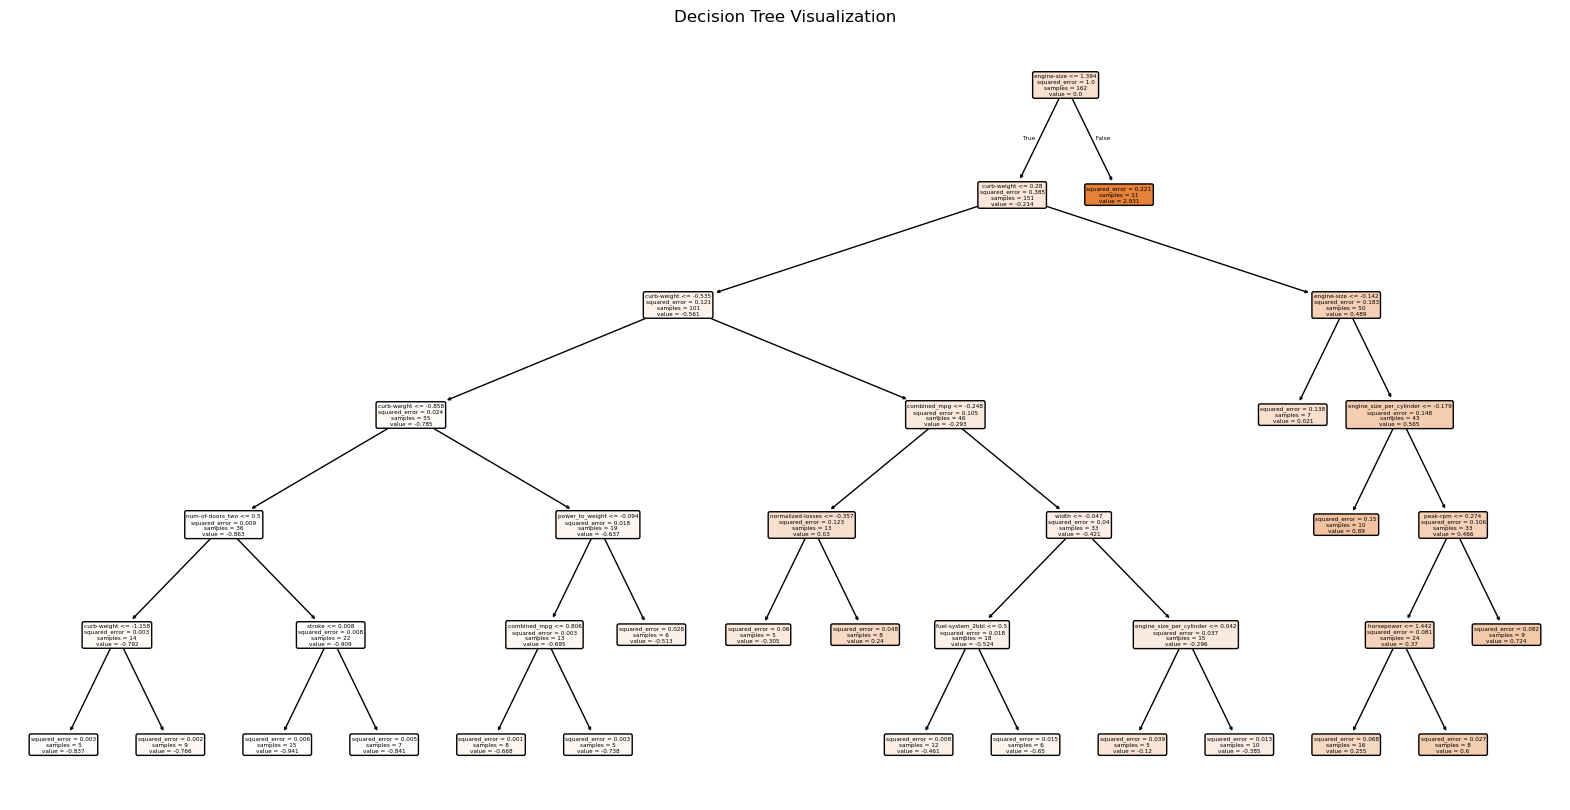

In [78]:
plt.figure(figsize=(20, 10))  # Adjust figure size for readability
plot_tree(best_model, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

In [58]:
best_model=DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, min_samples_split=10,
                      random_state=42)
best_model.fit(X_train_selected, y_train)  

DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, min_samples_split=10,
                      random_state=42)

In [59]:
y_predicted_dt_hyp=best_model.predict(X_test[important_feature])

In [ ]:

regression_report(y_test,y_predicted_dt_hyp)


Model: DecisionTreeRegressor with hyparameter tuning {'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 12} and important features
MAE: 0.28118293271300254
MSE: 0.17569078308465155
R² Score: 0.8752242991470398
Root Mean Squared Error (RMSE): 0.419154843804353


In [60]:
y_predicted_dt_hyp_not_scaled = scaler_y.inverse_transform(y_predicted_dt_hyp.reshape(-1, 1)).flatten()

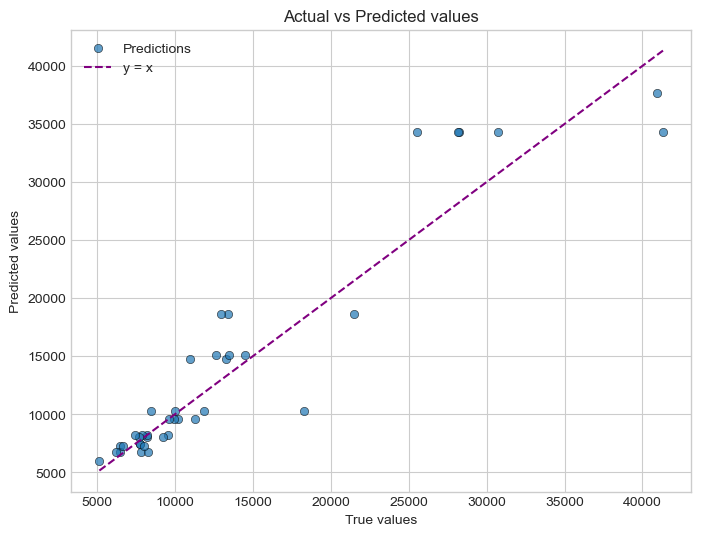

In [61]:
plot_actual_predicted(y_test_original_scale,y_predicted_dt_hyp_not_scaled)

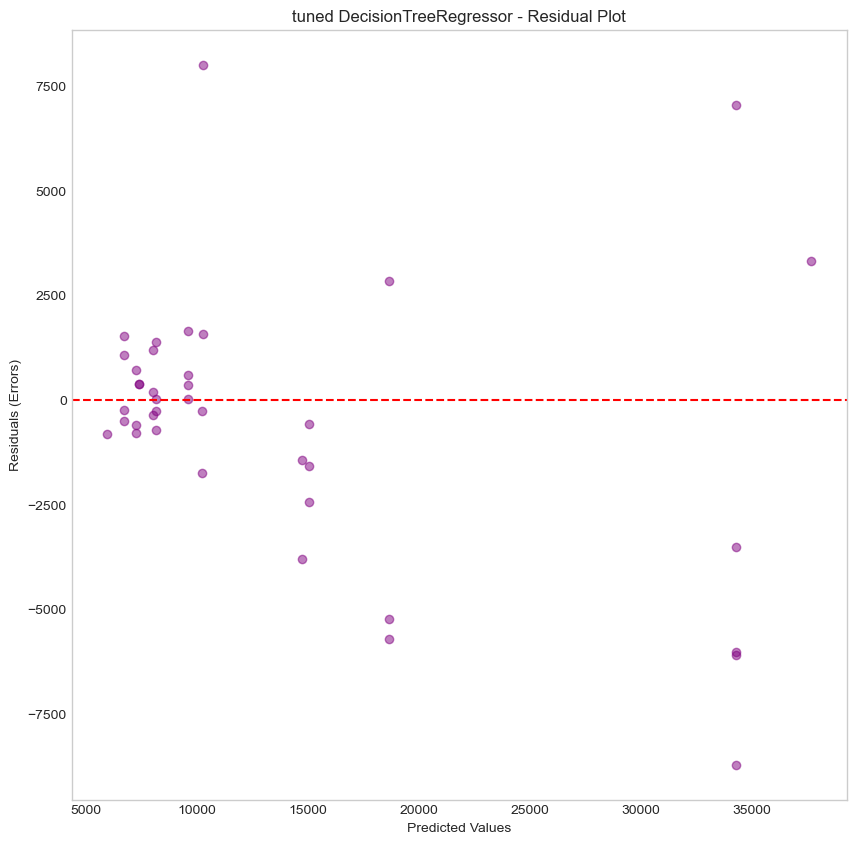

In [62]:
plot_residuals(y_test_original_scale,y_predicted_dt_hyp_not_scaled,"tuned DecisionTreeRegressor")

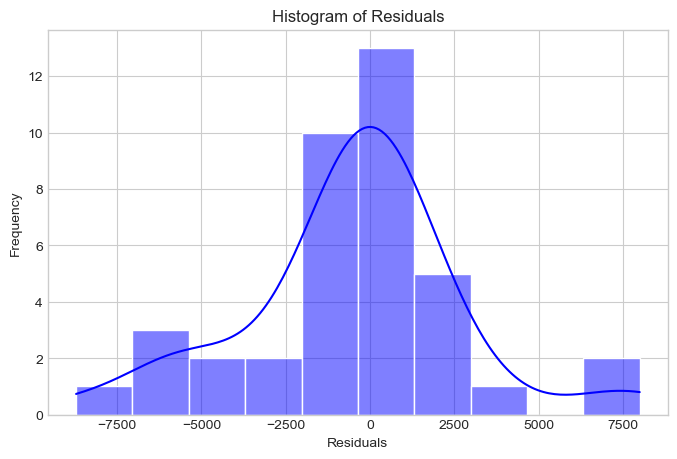

In [63]:

histogram_residuals(y_test_original_scale,y_predicted_dt_hyp_not_scaled)

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │       67.2026    │
├──────────────────────────┼──────────────────┤
│ curb-weight              │       28.3905    │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │        1.24529   │
├──────────────────────────┼──────────────────┤
│ engine_size_per_cylinder │        1.05205   │
├──────────────────────────┼──────────────────┤
│ normalized-losses        │        0.594678  │
├──────────────────────────┼──────────────────┤
│ peak-rpm                 │        0.535058  │
├──────────────────────────┼──────────────────┤
│ horsepower               │        0.414578  │
├──────────────────────────┼──────────────────┤
│ width                    │        0.27655   │
├──────────────────────────┼──────────────────┤
│ fuel-system_2bbl         │        0.0929132 │
├──────────────────────────┼────────────

C:\Users\dell\AppData\Local\Temp\ipykernel_7864\3648721288.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance (%)", y="Feature", data=feature_importance, palette="viridis")


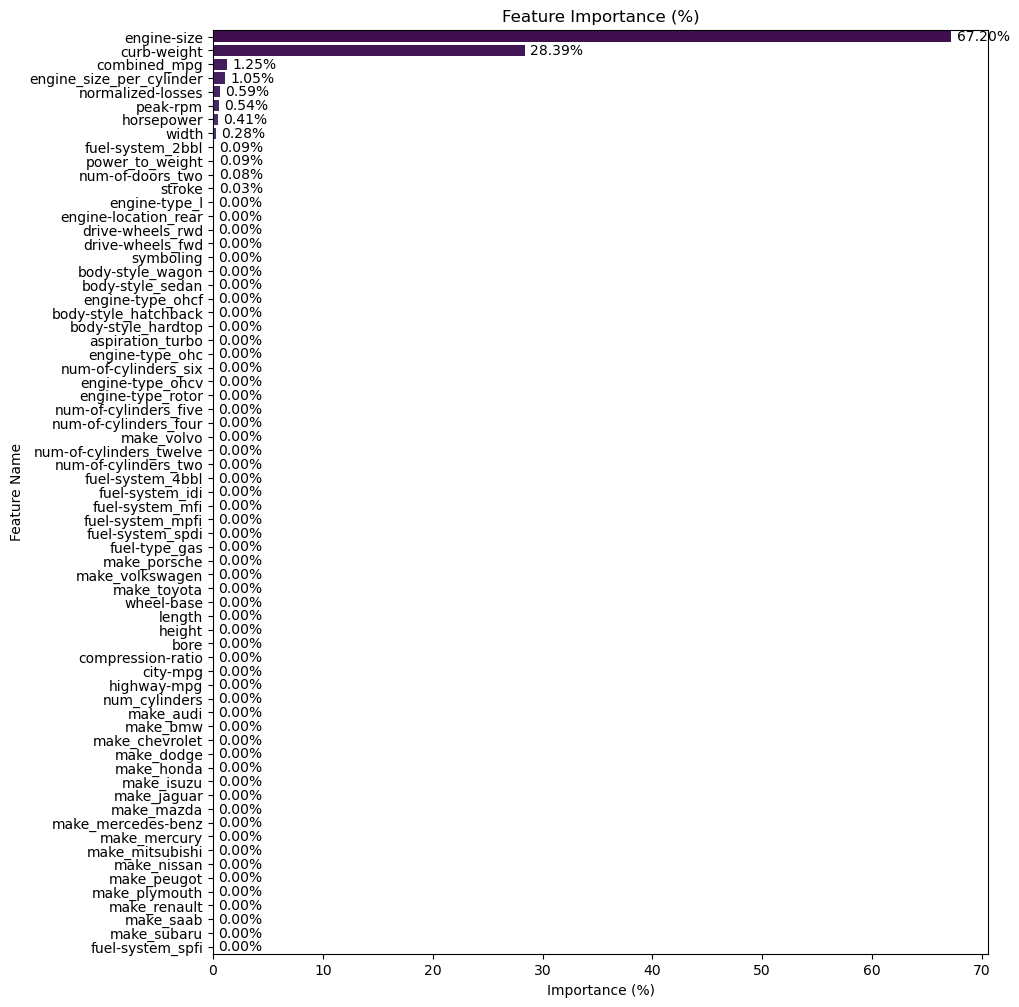

In [84]:
important_feature_tuned=plot_feature_importance(best_model,X_train.columns)

In [90]:
print(important_feature_tuned)
print(len(important_feature_tuned))

['engine-size', 'curb-weight', 'combined_mpg', 'engine_size_per_cylinder', 'normalized-losses', 'peak-rpm', 'horsepower', 'width', 'fuel-system_2bbl', 'power_to_weight', 'num-of-doors_two', 'stroke']
12


- cross validation for the tuned model


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 5-Fold Cross-Validation on the best model
cv_mse_scores = -cross_val_score(best_model, X_train_selected, y_train, cv=10, scoring="neg_mean_squared_error")

# Compute the mean and standard deviation of MSE
mean_mse = np.mean(cv_mse_scores)
std_mse = np.std(cv_mse_scores)
print("Cross-Validation MSE Scores:", cv_mse_scores)
print("Mean MSE:", mean_mse)
print("MSE Standard Deviation:", std_mse)
print("Mean RMSE:", np.sqrt(mean_mse))



Cross-Validation MSE Scores: [0.10999258 0.05461189 0.06450426 0.08398421 0.32782119 0.1998309
 0.0808003  0.14246641 0.09733924 0.23159116]
Mean MSE: 0.1392942121792864
MSE Standard Deviation: 0.08342665922047936
Mean RMSE: 0.3732213983405646


Conclusion:  
The first model, without tuning, performs better in terms of accuracy,but it exhibits overfitting, as indicated by its higher variance across cross-validation folds  
On the other hand, the tuned DecisionTreeRegressor with feature selection is more stable and generalizes better, even though its accuracy is slightly lower  
Since stability is crucial for real-world applications, the tuned model is preferred  
Further improvements could be made by using ensemble methods to find a balance between accuracy and stability


# Random Forest


- train the model


In [64]:
RandomForestModel=RandomForestRegressor()
RandomForestModel.fit(X_train,y_train)

RandomForestRegressor()

visualize some trees from the random forest model


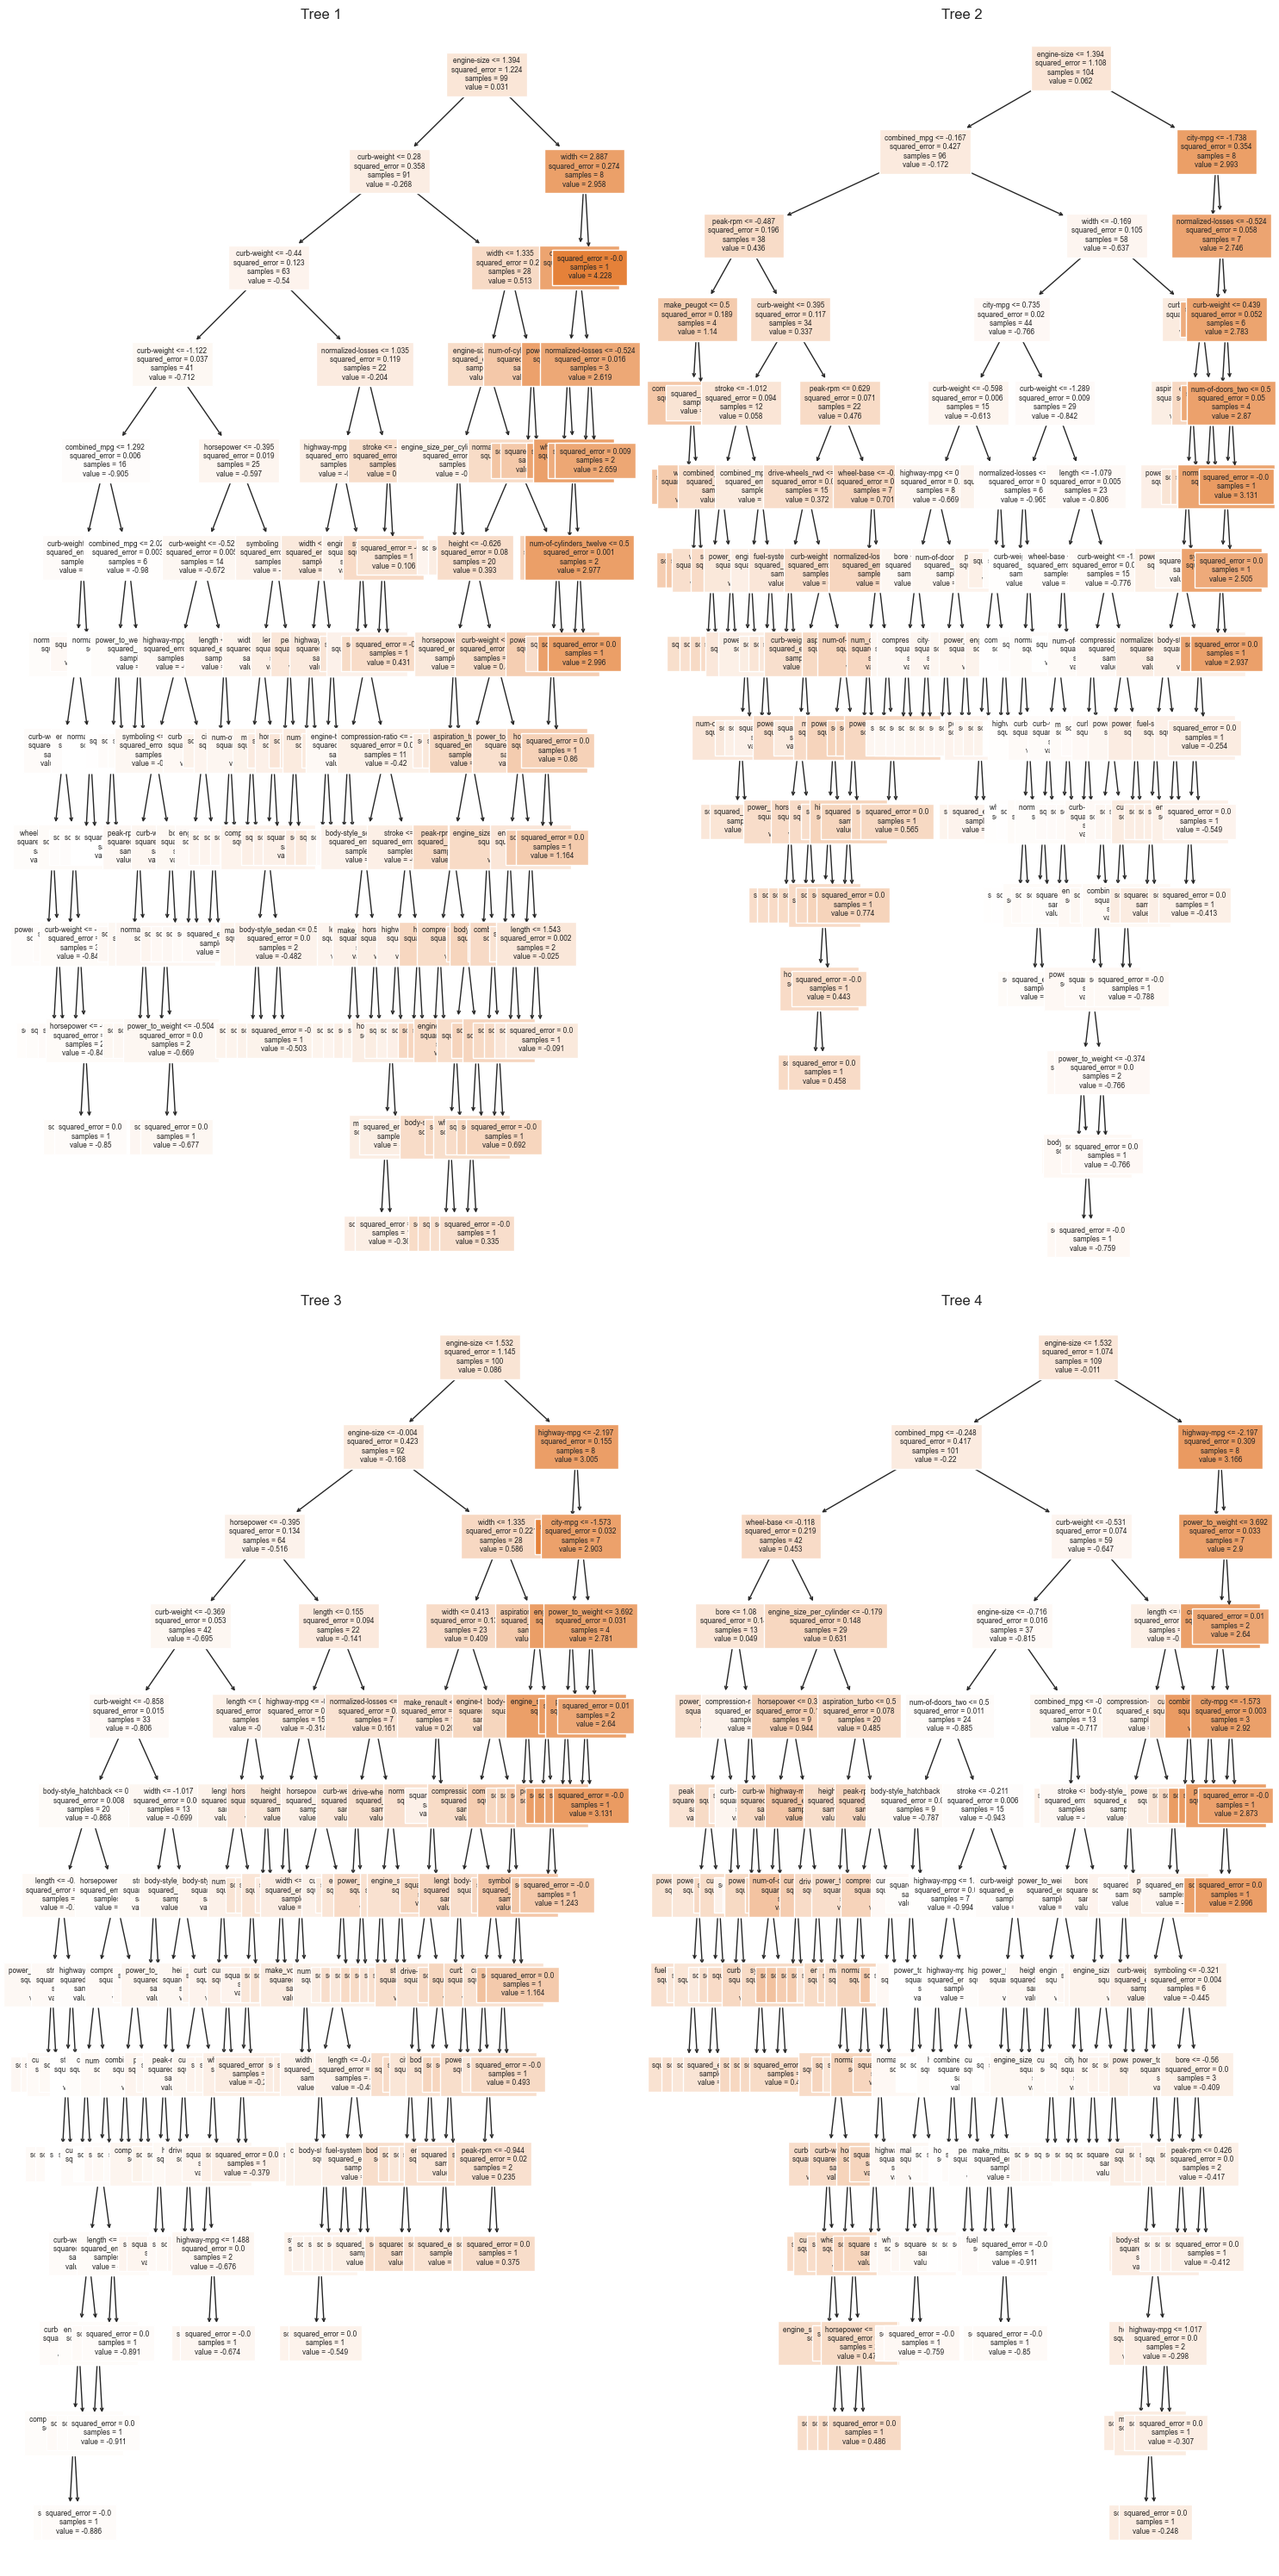

In [65]:
n_trees=4
fig,axes=plt.subplots(2, 2, figsize=(15, 30))
for i , ax in enumerate(axes.flat):
    plot_tree(RandomForestModel.estimators_[i],filled=True, feature_names=list(X_train.columns), ax=ax, fontsize=6)
    ax.set_title(f"Tree {i+1}")
plt.tight_layout()
plt.show()

In [67]:
max_depth = max(tree.get_depth() for tree in RandomForestModel.estimators_)
print("Maximum Tree Depth:", max_depth)


Maximum Tree Depth: 17


- prediction


In [68]:
y_predicted_rf=RandomForestModel.predict(X_test)

- Evaluation of the model


In [ ]:
regression_report(y_test,y_predicted_rf )

Model: RandomForestRegressor
MAE: 0.1737888786571339
MSE: 0.05940423316524063
R² Score: 0.9578110775267351
Root Mean Squared Error (RMSE): 0.24372983642804305


In [69]:
y_predicted_rf_not_scaled = scaler_y.inverse_transform(y_predicted_rf.reshape(-1, 1)).flatten()

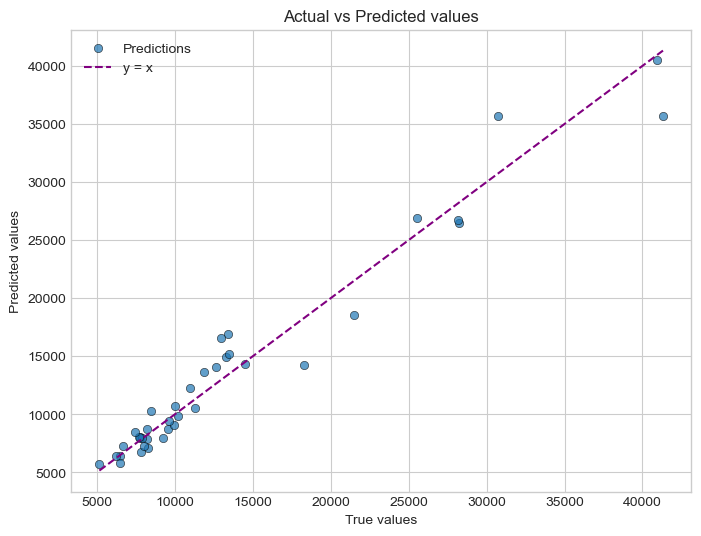

In [70]:
plot_actual_predicted(y_test_original_scale,y_predicted_rf_not_scaled)

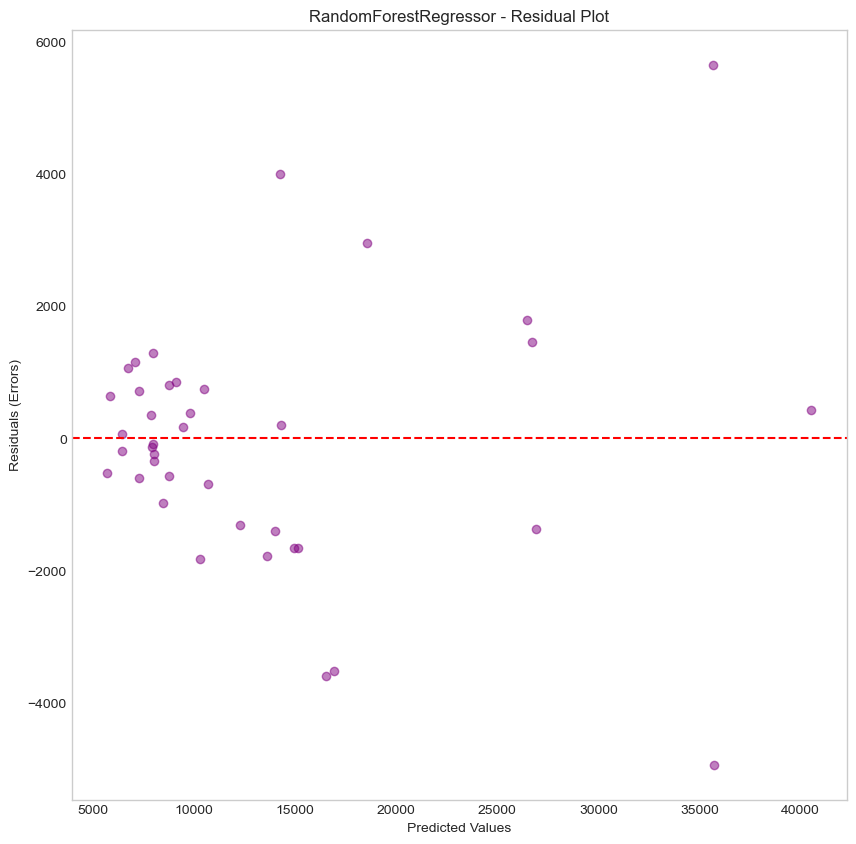

In [71]:
plot_residuals(y_test_original_scale,y_predicted_rf_not_scaled,"RandomForestRegressor")

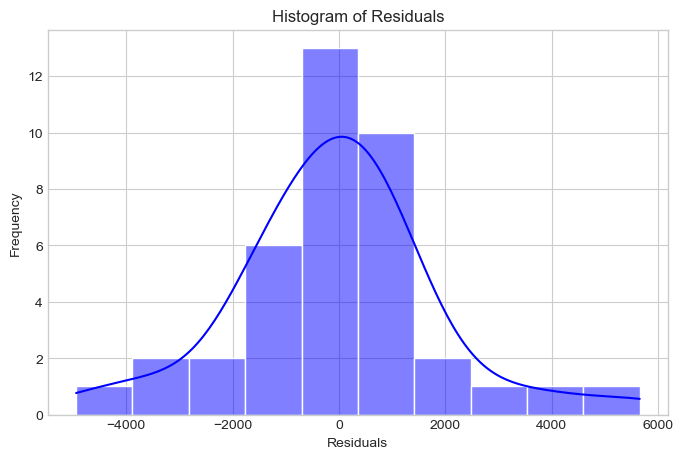

In [72]:

histogram_residuals(y_test_original_scale,y_predicted_rf_not_scaled)

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │     56.0418      │
├──────────────────────────┼──────────────────┤
│ curb-weight              │     27.2973      │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │      3.46986     │
├──────────────────────────┼──────────────────┤
│ highway-mpg              │      3.25741     │
├──────────────────────────┼──────────────────┤
│ horsepower               │      1.44077     │
├──────────────────────────┼──────────────────┤
│ width                    │      1.43118     │
├──────────────────────────┼──────────────────┤
│ wheel-base               │      0.784581    │
├──────────────────────────┼──────────────────┤
│ make_bmw                 │      0.618112    │
├──────────────────────────┼──────────────────┤
│ power_to_weight          │      0.595736    │
├──────────────────────────┼────────────

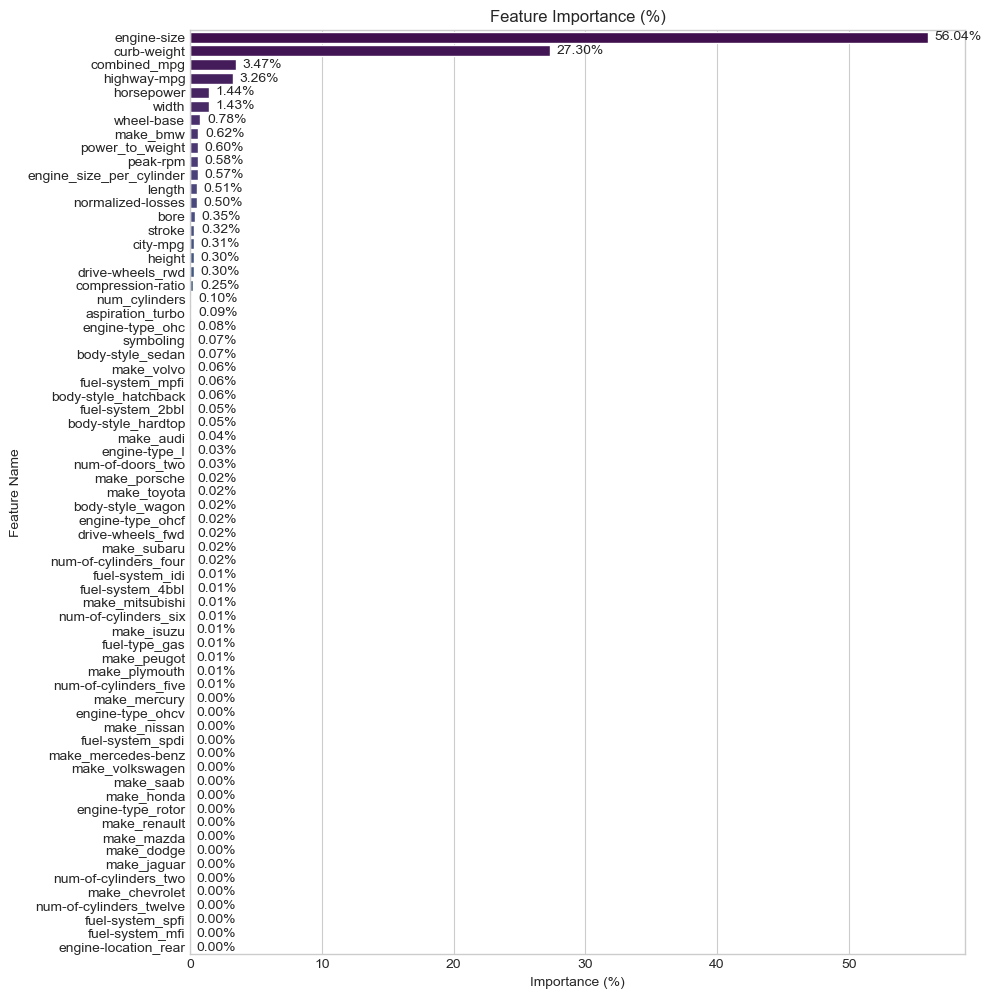

In [73]:
important_feature_rf=plot_feature_importance(RandomForestModel,X_train.columns)

In [91]:
for i in range(0, len(important_feature_rf), 5):  # Adjust chunk size
    print(", ".join(important_feature_rf[i:i+5]))


engine-size, curb-weight, highway-mpg, combined_mpg, width
horsepower, wheel-base, engine_size_per_cylinder, length, num_cylinders
make_bmw, power_to_weight, peak-rpm, normalized-losses, bore
city-mpg, height, compression-ratio, stroke, engine-type_ohc
body-style_sedan, drive-wheels_rwd, fuel-system_mpfi, aspiration_turbo, make_audi
symboling, make_volvo, fuel-system_2bbl, drive-wheels_fwd, num-of-doors_two
body-style_hardtop, body-style_hatchback, fuel-system_idi, engine-type_ohcf, make_toyota
body-style_wagon, num-of-cylinders_six, make_plymouth, num-of-cylinders_four, make_mazda
num-of-cylinders_two, fuel-type_gas, make_mercedes-benz, make_volkswagen, fuel-system_4bbl
make_mitsubishi, make_saab, fuel-system_spdi, make_nissan, engine-type_ohcv
engine-type_rotor, make_porsche, make_renault, make_subaru, num-of-cylinders_five
make_jaguar, engine-type_l, make_mercury, make_isuzu, engine-location_rear
make_honda, num-of-cylinders_twelve, make_dodge, make_peugot, fuel-system_spfi
make_che

In [74]:

print(len(important_feature_rf))


67


- cross validation


In [75]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation with 5 folds
cv_mse = -cross_val_score(RandomForestModel, X_train, y_train, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)

# Print cross-validation results
print("Cross-Validation MSE Scores:", cv_mse)
print("MSE standard deviation ",np.std(cv_mse))
print("Mean MSE:", np.mean(cv_mse))
print("Mean RMSE:", np.sqrt(np.mean(cv_mse)))


Cross-Validation MSE Scores: [0.06201583 0.0946287  0.03426113 0.03320019 0.27731834 0.14093062
 0.05884576 0.07218977 0.05259059 0.24945469]
MSE standard deviation  0.08357927677444014
Mean MSE: 0.10754356123995137
Mean RMSE: 0.327938349754876


we can see that the accuracy of random forest regressor is better than untuned and tuned decision tree and more stable than both


- hyparameter tuning


In [94]:
param_grid = {
    'n_estimators': [10, 50, 100],  
    'max_depth': list(range(1, 18)),  
    'min_samples_split': [2, 4, 8],  
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2']  
}
"""
max_features="sqrt" (default for Random Forest regression) : uses √(total features) per split reducing correlation between trees and improving generalization.
max_features="log2" : uses log2(total features) per split  increasing randomness and preventing overfitting
"""

rf=RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid,cv=10,scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_rf_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

print("Best Parameters:", best_rf_params)
print("Best Model:", best_rf_model)

Best Parameters: {'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Model: RandomForestRegressor(max_depth=12, max_features='log2', n_estimators=50,
                      random_state=42)


c:\Users\dell\anaconda3\envs\DM_ENV\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\dell\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [76]:
best_rf_model = RandomForestRegressor(max_depth=12, max_features='log2', n_estimators=50,
                      random_state=42)
best_rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, max_features='log2', n_estimators=50,
                      random_state=42)

In [77]:
y_pred_rf_tuned=best_rf_model.predict(X_test)

- evaluate the tuned random forest


In [ ]:
regression_report(y_test,y_pred_rf_tuned)

Model:  Tuned RandomForestRegressor 
MAE: 0.2033071855492788
MSE: 0.11294485956983714
R² Score: 0.919786492136156
Root Mean Squared Error (RMSE): 0.33607269982823235


In [78]:
y_pred_rf_tuned_not_scaled = scaler_y.inverse_transform(y_pred_rf_tuned.reshape(-1, 1)).flatten()

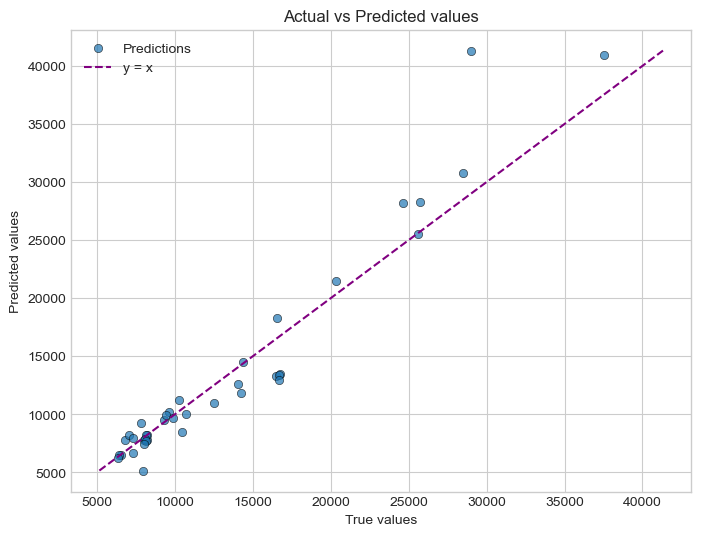

In [79]:
plot_actual_predicted(y_pred_rf_tuned_not_scaled,y_test_original_scale)

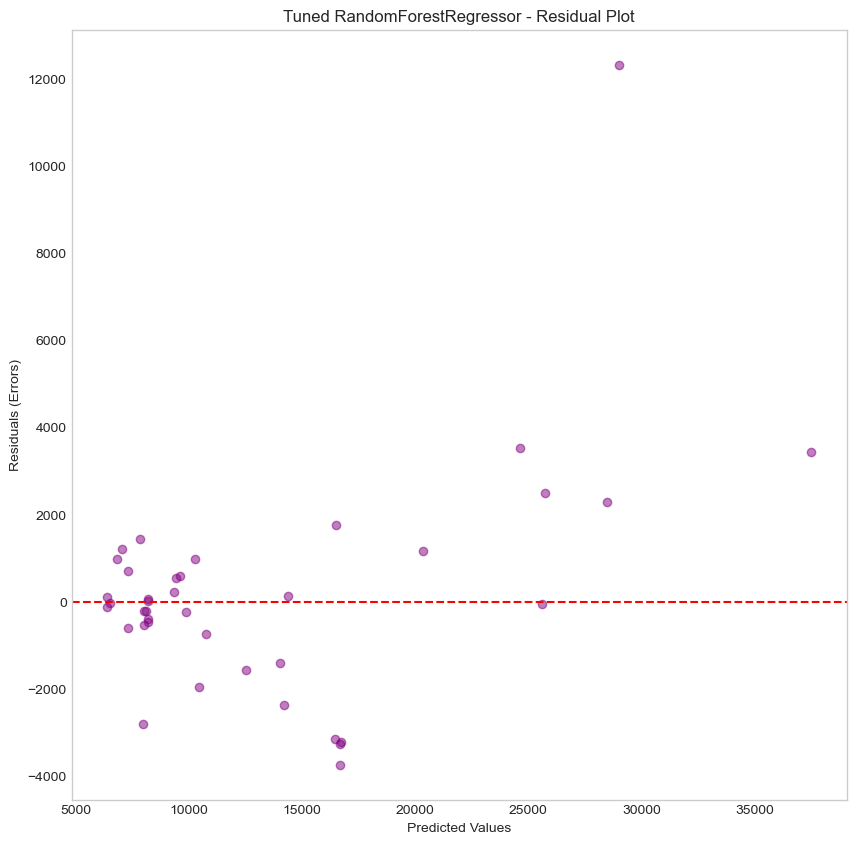

In [80]:
plot_residuals(y_test_original_scale,y_pred_rf_tuned_not_scaled,"Tuned RandomForestRegressor")

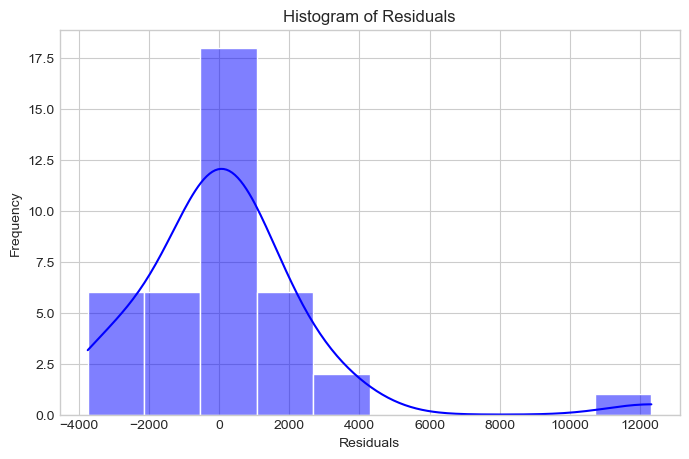

In [81]:

histogram_residuals(y_test_original_scale,y_pred_rf_tuned_not_scaled)

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │     11.6368      │
├──────────────────────────┼──────────────────┤
│ horsepower               │      9.15449     │
├──────────────────────────┼──────────────────┤
│ city-mpg                 │      8.85416     │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │      8.08315     │
├──────────────────────────┼──────────────────┤
│ num-of-cylinders_four    │      7.82997     │
├──────────────────────────┼──────────────────┤
│ curb-weight              │      6.68519     │
├──────────────────────────┼──────────────────┤
│ num_cylinders            │      6.07726     │
├──────────────────────────┼──────────────────┤
│ highway-mpg              │      6.0699      │
├──────────────────────────┼──────────────────┤
│ wheel-base               │      5.08397     │
├──────────────────────────┼────────────

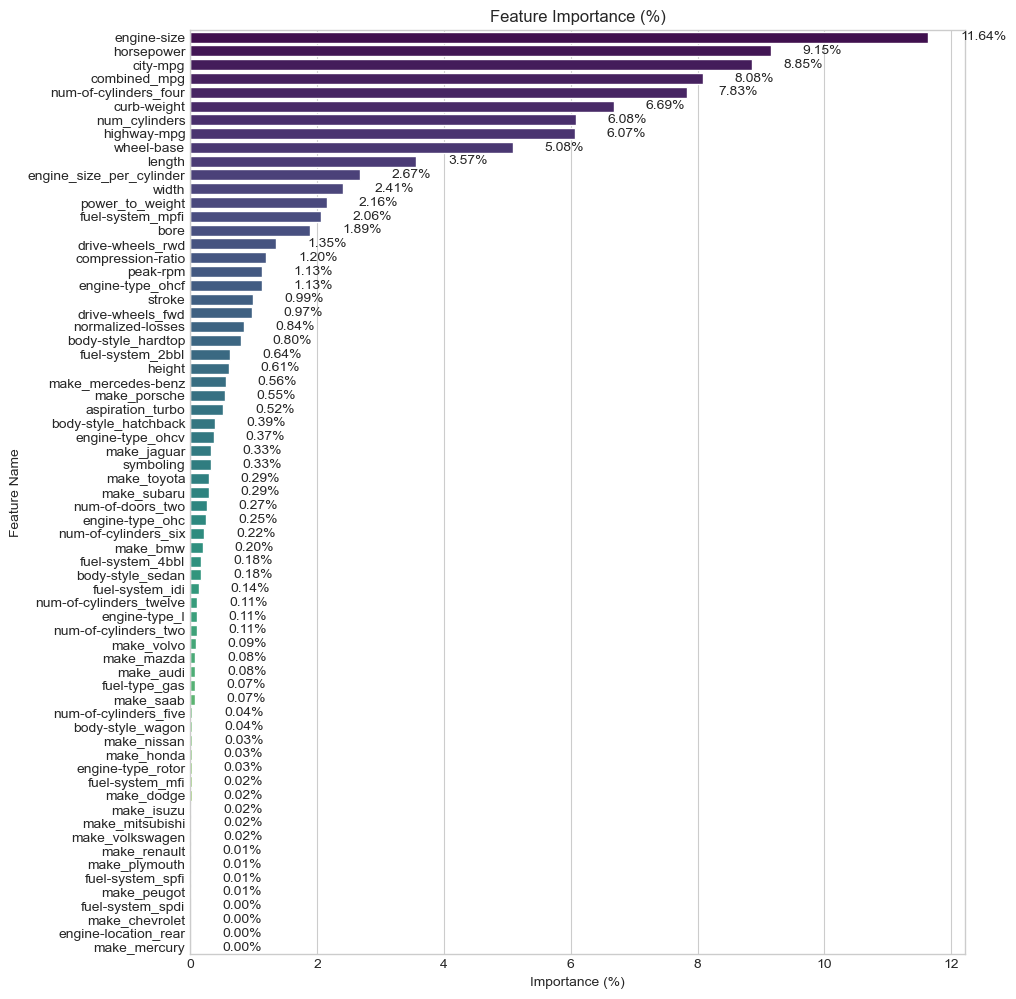

In [82]:
important_feature_rf=plot_feature_importance(best_rf_model,X_train.columns)

- Cross validation for tuned random forest


In [97]:
from sklearn.model_selection import cross_val_score

cv_mse = -cross_val_score(best_rf_model, X_train, y_train, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)

print("Cross-Validation MSE Scores:", cv_mse)
print("MSE standard deviation ",np.std(cv_mse))
print("Mean MSE:", np.mean(cv_mse))
print("Mean RMSE:", np.sqrt(np.mean(cv_mse)))


Cross-Validation MSE Scores: [0.06225874 0.0997847  0.04455089 0.03054124 0.12974158 0.08594429
 0.04381038 0.10196157 0.03188747 0.26813018]
MSE standard deviation  0.06741358901952416
Mean MSE: 0.08986110619621676
Mean RMSE: 0.2997684209455972


In [83]:
import pandas as pd


y_test_array = y_test.to_numpy().flatten() if hasattr(y_test, "to_numpy") else y_test.flatten()
y_pred_array = y_pred_rf_tuned.to_numpy().flatten() if hasattr(y_pred_rf_tuned, "to_numpy") else y_pred_rf_tuned.flatten()


df_comparison = pd.DataFrame({
    'Actual': y_test_original_scale,
    'Predicted': y_pred_rf_tuned_not_scaled
})

print(df_comparison)



     Actual     Predicted
0   30760.0  28474.120000
1    9549.0   9321.389333
2   11850.0  14212.730000
3   28248.0  25752.780000
4    7799.0   6820.236641
5    7788.0   8196.151111
6    9258.0   7831.047024
7   10198.0   9614.228000
8    7775.0   7995.320000
9   13295.0  16454.501818
10   8238.0   8177.780000
11  18280.0  16518.145152
12   9988.0  10740.610667
13  40960.0  37520.460000
14   6488.0   6518.859167
15   5151.0   7970.000000
16  12629.0  14041.304000
17   8189.0   8169.446667
18   9960.0   9420.468000
19   8495.0  10449.814667
20  13499.0  16720.100000
21   8249.0   7042.223308
22   6479.0   6385.066667
23   6692.0   7310.366667
24  41315.0  28997.900000
25   9639.0   9868.121905
26  13415.0  16682.330000
27   7999.0   7298.856245
28  12940.0  16680.130000
29  25552.0  25613.830000
30   6229.0   6357.150000
31   7898.0   8107.480000
32  21485.0  20322.900000
33   7689.0   8166.348000
34  28176.0  24644.570000
35  11259.0  10281.388000
36  10945.0  12523.106667
37  14489.0 

### Conclusion: Choosing the Best Model

#### **Notes**

- The **default RandomForest model** has **lower training MSE & higher R²**, but it **overfits** (performs worse in cross-validation).
- The **tuned RandomForest model** has **higher training error** but **better cross-validation results** (lower mean MSE, RMSE, and standard deviation).
- **Lower MSE standard deviation** in the tuned model means it is **more stable** across different dataset splits.
- **Compared to Decision Trees (both untuned and tuned), Random Forest achieved better accuracy and stability** in all cases.

**Final Choice**:  
The **Tuned RandomForestRegressor** is the best model as it balances performance and stability, making it **more reliable for real-world use**.


***
# **Support Vector Machines (SVM)**
Support Vector Machines (SVM) is a powerful supervised learning algorithm widely used for classification and regression tasks. In this project, we apply SVM to the **1985 Auto Imports Dataset** to analyze car price prediction.

### **Why SVM?**
SVM is particularly useful in handling high-dimensional data and works well with both linear and non-linear relationships. Given that our dataset contains a mix of categorical and numerical attributes, SVM can help find the optimal decision boundary between different car characteristics.

### **Objective**
For this dataset, SVM will be used to predict the **price** of a car based on its specifications, such as engine size, horsepower, and fuel type.

## Step 1: Create the SVM Model

First we import the necessary libraries

In [30]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

Initialize and train an SVM model with default parameters.

In [31]:
from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train, y_train)

SVR()

In [32]:
y_svm_pred = svr.predict(X_test)

### Analysis of the Results

In [33]:
def plot_residuals_vs_predicted(y_true, y_pred):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')  # Horizontal line at 0
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs. Predicted Plot")
    plt.grid(True)
    plt.show()

In [34]:
y_svm_pred_not_scaled = scaler_y.inverse_transform(y_svm_pred.reshape(-1, 1)).flatten()

#### Regression Report:

In [36]:
regression_report(y_svm_pred, y_test)

       Regression performance report
   Mean squared error:  0.224 
   Mean absolute error: 0.299 
   Root mean squared error: 0.473 
   R2 score: 0.841


#### Actual vs Predicted Plot

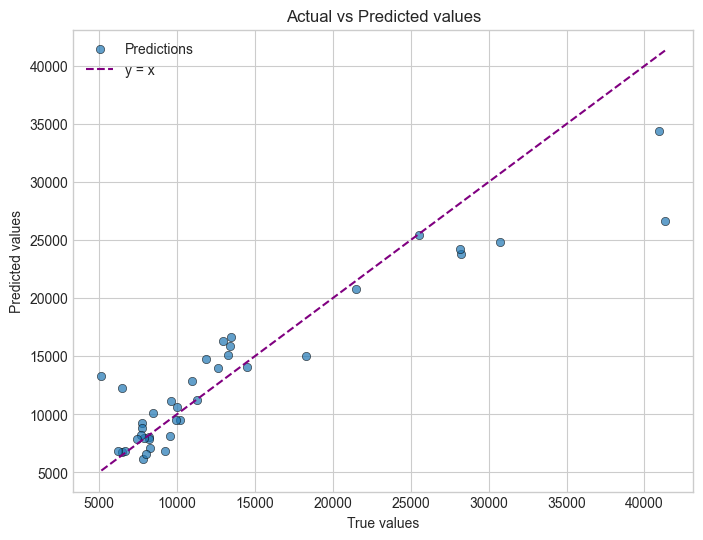

In [37]:
plot_actual_predicted(y_test_original_scale,y_svm_pred_not_scaled)

**Analysis:** Many points are close to the $y = x$ line, which indicates that the model has high accuracy. However, some points deviate significantly from the line especially for higher values which means that the model might understimate this cases.

#### Histogram of Residuals

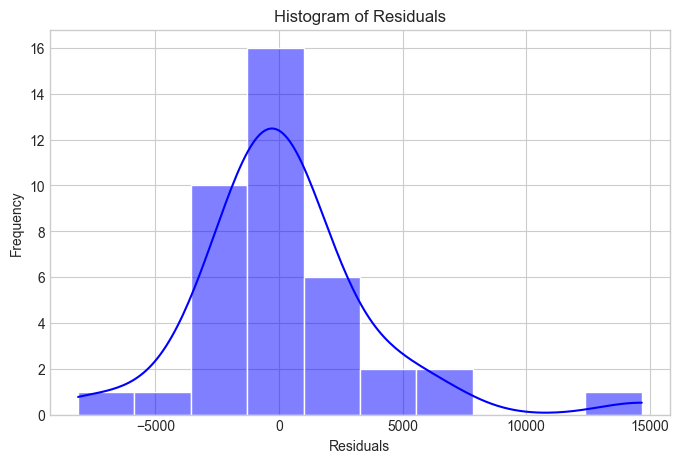

In [38]:
histogram_residuals(y_test_original_scale,y_svm_pred_not_scaled)

**Analysis:** The residuals are mostly centered around 0 which means the overall predictions are accurate. However, a slight positive skew suggests that the model tends to underpredict certain values. 

#### Residuals vs Predicted Plot

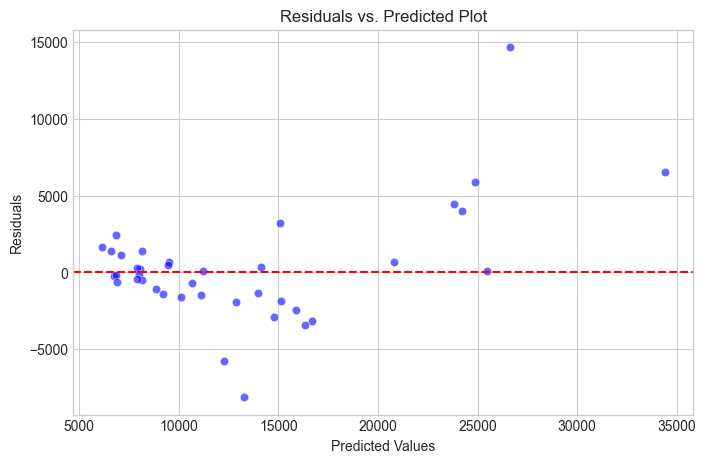

In [39]:
plot_residuals_vs_predicted(y_test_original_scale,y_svm_pred_not_scaled)

**Analysis:** The residuals are not fully randomly scattered, and the spread of residuals increases as predicted values grow, suggesting heteroscedasticity.

#### QQ Plot

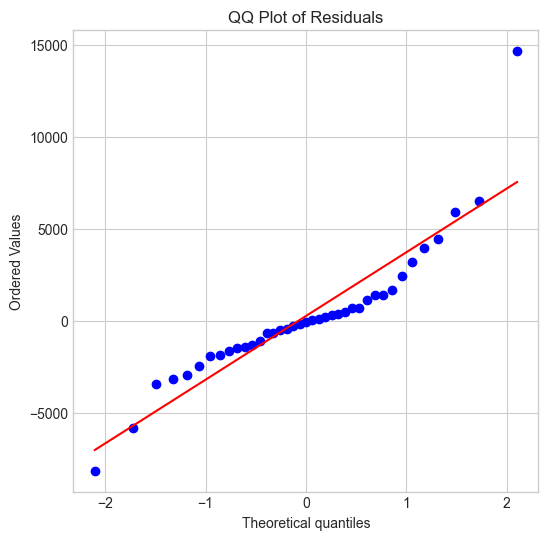

In [40]:
residuals = y_test_original_scale.to_numpy().flatten() - y_svm_pred_not_scaled.flatten()

plot_qq(residuals)

**Analysis:**  The residuals are not perfectly normally distributed.

### **Hyperparameter Tuning for Better SVR Performance**
To achieve better prediction results, we will tune the hyperparameters of the Support Vector Regressor (SVR) using two methods:

1. **Bayesian Optimization (BayesSearchCV)** – A smarter search that efficiently explores the hyperparameter space to find the best settings faster.

2. **Grid Search** – A systematic approach that tests all possible hyperparameter combinations within a predefined grid.



#### **1)- Bayesian Optimization (BayesSearchCV)**

In [180]:
from skopt import BayesSearchCV

search_space = {
    'C': (0.001, 1000),  
    'epsilon': (0.001, 1.0),
    'gamma': (0.001, 1.0),
    'kernel': ['linear', 'rbf', 'poly']
}

# Bayesian Search CV
bayes_search = BayesSearchCV(
    svr,
    search_space,
    n_iter=50,  
    cv=10,       
    n_jobs=-1,
    random_state=42
)

# Run search
bayes_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", bayes_search.best_params_)

c:\Users\zinou\.conda\envs\DM_ENV\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Parameters: OrderedDict([('C', 100.77778299264786), ('epsilon', 0.11337667232924196), ('gamma', 0.49734731393957377), ('kernel', 'linear')])


For Bayesian Optimisation we got:
- **C** = 100.77778299264786
- **epsilon** = 0.11337667232924196
- **gamma** = 0.49734731393957377
- **kernel** = 'linear'

We train a new svr model using the parameters obtained from bayes search:

In [41]:
svr_bayes_search = SVR(C= 100.77778299264786, epsilon= 0.11337667232924196, gamma= 0.49734731393957377, kernel= 'linear')
svr_bayes_search.fit(X_train, y_train)
y_svm_pred_bayes_search = svr_bayes_search.predict(X_test)

#### **2)- Grid Search**

In [ ]:
from sklearn.model_selection import GridSearchCV

# parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'epsilon': [0.001, 0.01, 0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
    'kernel': ['rbf', 'poly', 'linear']
}

grid_search = GridSearchCV(svr, param_grid, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Best parameters: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Best score: -0.07198461273292138


c:\Users\zinou\.conda\envs\DM_ENV\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


For Grid Search we got:
- **C** = 100
- **epsilon** = 0.1
- **gamma** = 0.01
- **kernel** = 'rbf'

We train a new svr model using the parameters obtained from grid search:

In [42]:
svr_grid_search = SVR(C= 100, epsilon= 0.1, gamma= 0.01, kernel= 'rbf')
svr_grid_search.fit(X_train, y_train)
y_svm_pred_grid_search = svr_grid_search.predict(X_test)


##### **3)- Comparison**

In [43]:
def regression_comparison(true, **predictions):
    results = []
    
    for model_name, predicted in predictions.items():
        mse = mean_squared_error(true, predicted)
        mae = mean_absolute_error(true, predicted)
        rmse = np.sqrt(mse)
        r2 = r2_score(true, predicted)
        
        results.append([model_name, round(mse, 3), round(mae, 3), round(rmse, 3), round(r2, 3)])

    df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "RMSE", "R2 Score"])
    print(df)

In [44]:
regression_comparison(
    y_test, 
    BayesSearch= y_svm_pred_bayes_search, 
    GridSearch= y_svm_pred_grid_search
)

         Model    MSE    MAE   RMSE  R2 Score
0  BayesSearch  0.178  0.262  0.421     0.874
1   GridSearch  0.111  0.215  0.333     0.921


##### **Comparaison Analysis**
**Grid Search** performed better by achieving a **lower** $MSE$ (0.111) and $MAE$ (0.215), meaning its predictions are closer to the actual values. In addition to a **higher** $R^2$ (0.921) which indicates that it explains more variance.


So, GridSearch tuned SVR provides more accurate predictions.

##### **Actual vs Predicted Plot after GridSearch Tuning**

In [45]:
y_svm_pred_grid_search_not_scaled = scaler_y.inverse_transform(y_svm_pred_grid_search.reshape(-1, 1)).flatten()

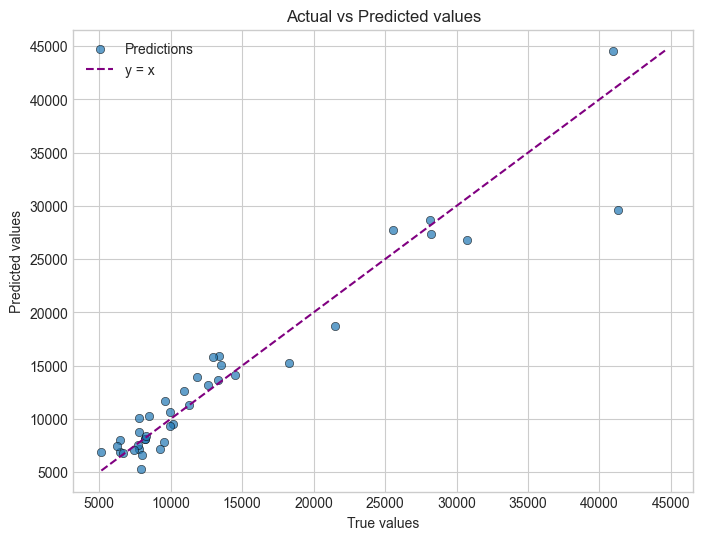

In [46]:
plot_actual_predicted(y_test_original_scale,y_svm_pred_grid_search_not_scaled)

**Analysis:** The plot shows smaller deviations from the line for higher predicted values, but there is still an instance of underestimation.

##### **Histogram of Residuals after GridSearch Tuning**

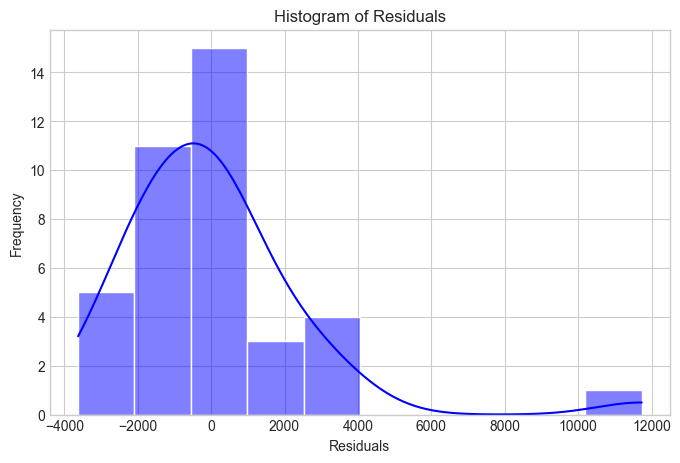

In [47]:
histogram_residuals(y_test_original_scale,y_svm_pred_grid_search_not_scaled)

**Analysis:** The residuals are more right-skewed than before.

##### **Residuals vs Predicted Plot**

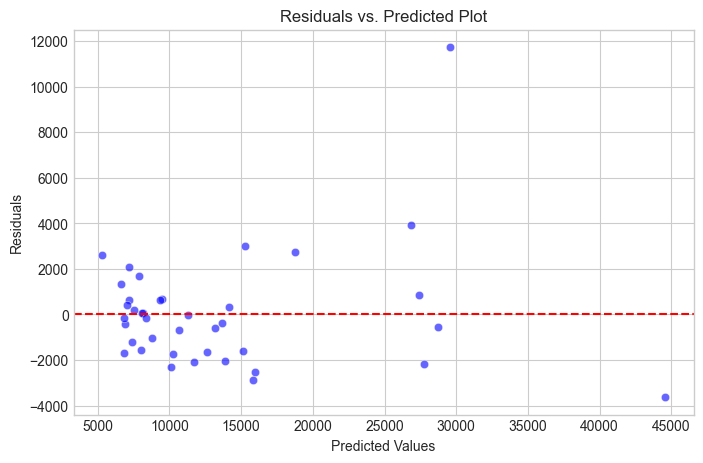

In [48]:
plot_residuals_vs_predicted(y_test_original_scale,y_svm_pred_grid_search_not_scaled)

**Analysis:**  No strong pattern shown, suggesting no systematic errors, but there is still some heteroscedasticity, especially for higher predicted values.

##### **QQ Plot**

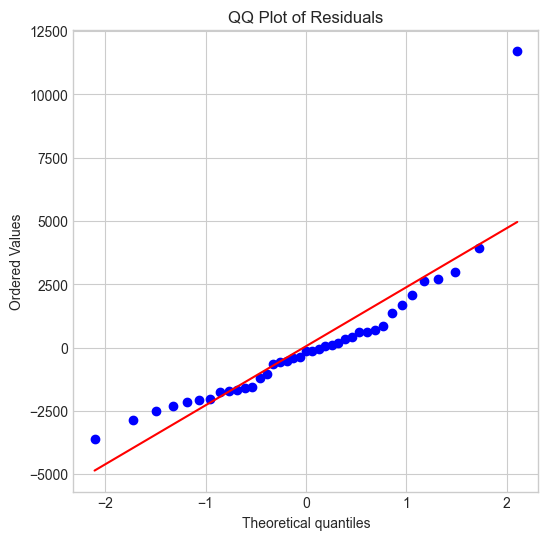

In [49]:
residuals = y_test_original_scale.to_numpy().flatten() - y_svm_pred_grid_search_not_scaled.flatten()
plot_qq(residuals)

**Analysis:** The residuals are approximately normally distributed, but there's still one extreme outlier at the top right of the QQ plot.

In [50]:
import pandas as pd


y_test_array = y_test_original_scale.to_numpy().flatten() if hasattr(y_test_original_scale, "to_numpy") else y_test_original_scale.flatten()
y_pred_array = y_svm_pred_grid_search_not_scaled.to_numpy().flatten() if hasattr(y_svm_pred_grid_search_not_scaled, "to_numpy") else y_svm_pred_grid_search_not_scaled.flatten()


df_comparison = pd.DataFrame({
    'Actual': y_test_array,
    'Predicted': y_pred_array
})

print(df_comparison)


     Actual     Predicted
0   30760.0  26813.833312
1    9549.0   7863.385903
2   11850.0  13895.043872
3   28248.0  27402.650114
4    7799.0   7173.173555
5    7788.0  10111.681186
6    9258.0   7178.699080
7   10198.0   9512.772621
8    7775.0   8818.278501
9   13295.0  13669.254610
10   8238.0   8152.861106
11  18280.0  15284.752621
12   9988.0  10648.342746
13  40960.0  44583.908118
14   6488.0   6890.859019
15   5151.0   6855.575985
16  12629.0  13206.787668
17   8189.0   8120.989357
18   9960.0   9333.593751
19   8495.0  10232.947472
20  13499.0  15098.979107
21   8249.0   8400.051693
22   6479.0   8049.800766
23   6692.0   6844.417142
24  41315.0  29583.075477
25   9639.0  11722.752890
26  13415.0  15935.738699
27   7999.0   6653.890409
28  12940.0  15799.408764
29  25552.0  27720.941620
30   6229.0   7421.911095
31   7898.0   5279.814913
32  21485.0  18762.428856
33   7689.0   7508.507104
34  28176.0  28722.756553
35  11259.0  11298.613741
36  10945.0  12607.904198
37  14489.0 

# Overall Model Analysis
After hyperparameter tuning, the model's performance improved, as indicated by better R² (0.921), MSE (0.111), and MAE (0.215) values. However, the residual histogram shows increased right skewness, suggesting that while overall predictions are more accurate, the model still tends to underestimate higher values. Additionally, the residuals are only approximately normally distributed, not fully, which may impact the model’s reliability.

Overall, the model performs well, but the right skew in residuals and the lack of perfect normality indicate potential areas for improvement. This suggests that SVM might not be the best choice for this dataset and task.

# Comparative Analysis

This section summarizes the regression performance of the different models evaluated for automobile price prediction. The table below compiles the key results, strengths, weaknesses, and suitability for this specific task, based on both raw metrics and detailed cross-validation outcomes.

| Model Category        | Model                 | Best $R^2$ | Strengths                                                     | Weaknesses                                  | Suitability       |
|----------------------|----------------------|------------|---------------------------------------------------------------|----------------------------------------------|-------------------|
| **Traditional ML**   | KNN Regressor        | 0.851      | Effective for local interpolation, stable cross-validation     | Sensitive to outliers, distance-based limitations | Good              |
|                      | Linear Regression    | 0.431      | Simple, interpretable                                         | Fails with multi-collinearity, underfits complex data | Poor              |
|                      | Ridge Regression     | 0.820      | Handles multi-collinearity, regularizes well                  | Still limited for highly non-linear data      | Moderate to Good  |
|                      | Naive Bayes          | 0.866      | Fast, good after tuning                                       | Assumes feature independence, sensitive to distribution | Moderate          |
|                      | Decision Tree        | 0.929      | Captures non-linear splits, interpretable                     | Can overfit, high variance                    | Very Good         |
|                      | Random Forest        | 0.958      | Best accuracy, robust, generalizes well                       | Black-box, higher computation                 | Excellent         |
|                      | SVM (Tuned)          | 0.921      | Flexible, robust to overfitting, strong after tuning          | Computationally intensive, kernel selection   | Very Good         |
| **Neural Networks**  | ANN (Best Deep Net)  | 0.894      | Captures complex, non-linear relations, flexible architectures | Requires tuning, longer training              | Excellent         |
|                      | ANN (Fine-Tuned)     | 0.895      | Best RMSE and $R^2$ after fine-tuning                         | High computation time, risk of overfitting    | Excellent         |

---

**Key Observations:**
- **Random Forest Regressor** outperforms all other models with an $R^2$ of 0.958 and the lowest error metrics, making it the best choice for this dataset.
- **Fine-tuned Deep Neural Networks** achieve strong performance ($R^2$ up to 0.895), with the lowest RMSE, but require longer training and careful regularization.
- **KNN** and **Naive Bayes** perform well after tuning, but KNN is sensitive to outliers and Naive Bayes' assumptions may not always hold.
- **Linear Regression** is not suitable in its raw form due to multi-collinearity and non-linearity, but **Ridge Regression** and feature transformation can improve results.
- **Decision Trees** and **SVM** (after tuning) also offer very competitive results, with Decision Trees being more interpretable and SVMs robust to overfitting.

---

**Recommendation:**  
For automobile price prediction, ensemble methods (Random Forest) and fine-tuned deep neural networks provide the best balance of accuracy and robustness. Simpler models like KNN or Ridge Regression may be chosen for faster deployment or greater interpretability, but with a trade-off in performance.